# Day 1 — Environment Setup & All Installs

This notebook covers:
1. Create folder structure
2. Install all required packages
3. Verify GPU availability
4. Download NLTK data and spaCy model
5. Generate `config.py`

## Google Colab + Drive Setup

Run this cell first every session. On Colab it mounts Drive and syncs model
checkpoints automatically. On a local machine it is a no-op.

In [2]:
import sys
!{sys.executable} -m pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (2449.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-win_amd64.whl (6.1 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (4.1 MB)
   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   ------------------------- -------------- 3.9/6.2 MB 21.5 MB/s eta 0:00:01
   ---------------------------------------- 6.2/6.2 MB 20.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------- ----------- 5.0/7.0 MB 25.2 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 21.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 23.2 MB/s eta 0:00:0

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os, shutil

# ── Detect environment ───────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── Mount Drive (Colab only) ─────────────────────────────────────────────
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_MODELS_DIR = '/content/drive/MyDrive/VibeRec/models'
    os.makedirs(DRIVE_MODELS_DIR, exist_ok=True)
    print(f'[Colab] Drive mounted.')
    print(f'[Colab] Model checkpoints -> {DRIVE_MODELS_DIR}')
else:
    DRIVE_MODELS_DIR = None
    print('[Local] Running locally — Drive sync disabled.')

# ── Helper: save a checkpoint to Drive ──────────────────────────────────
def drive_save(local_path: str) -> None:
    """Copy a local model file to Drive. No-op when running locally."""
    if DRIVE_MODELS_DIR is None or not os.path.exists(local_path):
        return
    dst = os.path.join(DRIVE_MODELS_DIR, os.path.basename(local_path))
    shutil.copy2(local_path, dst)
    print(f'  [Drive] saved -> {dst}')

# ── Helper: restore a checkpoint from Drive to local ─────────────────────
def drive_load(local_path: str) -> bool:
    """
    Copy a checkpoint from Drive to the local path if:
      - we are on Colab
      - the file exists on Drive
      - the local file does NOT already exist (fresh session)
    Returns True if a file was restored, False otherwise.
    """
    if DRIVE_MODELS_DIR is None:
        return False
    src = os.path.join(DRIVE_MODELS_DIR, os.path.basename(local_path))
    if os.path.exists(src) and not os.path.exists(local_path):
        os.makedirs(os.path.dirname(local_path), exist_ok=True)
        shutil.copy2(src, local_path)
        print(f'  [Drive] restored <- {src}')
        return True
    return False

print('[OK] drive_save / drive_load ready.')

## 1. Create Folder Structure

In [24]:
import os

# Project root — adjust if running from somewhere other than viberec/notebooks/
PROJECT_ROOT = os.getcwd()

dirs = [
    "data/raw",
    "data/processed",
    "models",
    "embeddings",
    "notebooks",
    "utils",
    "app",
]

for d in dirs:
    path = os.path.join(PROJECT_ROOT, d)
    os.makedirs(path, exist_ok=True)
    print(f"[OK] {path}")

print("\nFolder structure created.")

[OK] c:\Users\robin\Desktop\VibeRec\data/raw
[OK] c:\Users\robin\Desktop\VibeRec\data/processed
[OK] c:\Users\robin\Desktop\VibeRec\models
[OK] c:\Users\robin\Desktop\VibeRec\embeddings
[OK] c:\Users\robin\Desktop\VibeRec\notebooks
[OK] c:\Users\robin\Desktop\VibeRec\utils
[OK] c:\Users\robin\Desktop\VibeRec\app

Folder structure created.


## 2. Install All Packages

> Run this cell once. If you're using a fresh venv, all packages will be installed.  
> `faiss-gpu` requires a CUDA-capable GPU; replace with `faiss-cpu` if on CPU-only.

In [25]:
import subprocess, sys, platform

packages = [
    "torch",
    "torchvision",
    "pandas",
    "numpy",
    "scikit-learn",
    "nltk",
    "spacy",
    "gensim",
    "umap-learn",
    "matplotlib",
    "seaborn",
    "streamlit",
    "tqdm",
    "faiss-cpu",   # faiss-gpu is NVIDIA-only; faiss-cpu works on all platforms
]

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade'] + packages)

print(f'[OK] All packages installed')
print(f'Platform: {platform.system()} / {platform.machine()}')

[OK] All packages installed
Platform: Windows / AMD64


## 3. Verify GPU

In [26]:
import sys
import torch
print(sys.executable)
print(torch.__file__)

c:\Users\robin\Desktop\VibeRec\venv\Scripts\python.exe
c:\Users\robin\Desktop\VibeRec\venv\Lib\site-packages\torch\__init__.py


In [ ]:
!pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (2449.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-win_amd64.whl (6.1 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (4.1 MB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached https://download.pytorch.org/whl/setuptools-70.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.


In [1]:
import torch
import platform

# CUDA = NVIDIA GPU (Linux/Windows)  |  MPS = Apple Silicon GPU (Mac)
cuda_available = torch.cuda.is_available()
mps_available  = torch.backends.mps.is_available()

if cuda_available:
    device = 'cuda'
    print(f'CUDA GPU detected')
    print(f'  GPU    : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
elif mps_available:
    device = 'mps'
    print(f'Apple Silicon GPU detected (MPS backend)')
    print(f'  Chip   : {platform.processor()} ({platform.machine()})')
    print(f'  MPS built  : {torch.backends.mps.is_built()}')
    print(f'  MPS ready  : {torch.backends.mps.is_available()}')
else:
    device = 'cpu'
    print('No GPU detected -- training will run on CPU (slower).')

print(f'PyTorch version : {torch.__version__}')
print(f'Device selected : {device}')

# Quick smoke test -- send a tensor to the device
t = torch.randn(3, 3).to(device)
print(f'Tensor on {device}: {t.device}  [OK]')

CUDA GPU detected
  GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
  VRAM   : 8.6 GB
PyTorch version : 2.5.1+cu121
Device selected : cuda
Tensor on cuda: cuda:0  [OK]


In [ ]:
!pip install --upgrade numpy --break-system-packages
//DO NOT RUN IF ON virtual environment

## 4. Download NLTK Data & spaCy Model

In [28]:
import nltk

nltk_packages = [
    "punkt",
    "punkt_tab",
    "stopwords",
    "wordnet",
    "averaged_perceptron_tagger",
]

for pkg in nltk_packages:
    nltk.download(pkg, quiet=True)
    print(f"[OK] nltk: {pkg}")

[OK] nltk: punkt
[OK] nltk: punkt_tab
[OK] nltk: stopwords
[OK] nltk: wordnet
[OK] nltk: averaged_perceptron_tagger


In [29]:
import subprocess, sys

result = subprocess.run(
    [sys.executable, "-m", "spacy", "download", "en_core_web_sm"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode == 0:
    print("[OK] spaCy model en_core_web_sm downloaded")
else:
    print("[ERROR]", result.stderr)

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 2.4 MB/s eta 0:00:06
     -- ------------------------------------- 0.8/12.8 MB 2.4 MB/s eta 0:00:06
     -- ------------------------------------- 0.8/12.8 MB 2.4 MB/s eta 0:00:06
     -- ------------------------------------- 0.8/12.8 MB 2.4 MB/s eta 0:00:06
     -- ------------------------------------- 0.8/12.8 MB 2.4 MB/s eta 0:00:06
     -- ------------------------------------- 0.8/12.8 MB 2.4 MB/s eta 0:00:06
     -- ------------------------------------- 0.8/12.8 MB 2.4 MB/s eta 0:00:06
     -- ------------------------------------- 0.8/12.8 MB 2.4 MB/s eta 0:00:06
     -- 

In [30]:
# Quick smoke test
import spacy
nlp = spacy.load("en_core_web_sm")
doc = nlp("This movie has a slow burn but heartwarming finish.")
print("spaCy tokens:", [token.lemma_ for token in doc if not token.is_stop and not token.is_punct])

spaCy tokens: ['movie', 'slow', 'burn', 'heartwarming', 'finish']


## 5. Generate `config.py`

In [32]:
import os
import torch

PROJECT_ROOT = os.getcwd()

config_content = '''"""
config.py - Central configuration for VibeRec.
All paths, hyperparameters, and constants live here.
Import this module wherever you need a setting.
"""

import os
import torch

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
PROJECT_ROOT = os.path.dirname(os.path.abspath(__file__))

DATA_RAW       = os.path.join(PROJECT_ROOT, "data", "raw")
DATA_PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR     = os.path.join(PROJECT_ROOT, "models")
EMBEDDINGS_DIR = os.path.join(PROJECT_ROOT, "embeddings")
NOTEBOOKS_DIR  = os.path.join(PROJECT_ROOT, "notebooks")

# Raw dataset files
MOVIELENS_RATINGS = os.path.join(DATA_RAW, "ml-25m", "ratings.csv")
MOVIELENS_MOVIES  = os.path.join(DATA_RAW, "ml-25m", "movies.csv")
MOVIELENS_TAGS    = os.path.join(DATA_RAW, "ml-25m", "tags.csv")
MOVIELENS_LINKS   = os.path.join(DATA_RAW, "ml-25m", "links.csv")

IMDB_BASICS   = os.path.join(DATA_RAW, "imdb", "title.basics.tsv")
IMDB_RATINGS  = os.path.join(DATA_RAW, "imdb", "title.ratings.tsv")

CMU_SUMMARIES = os.path.join(DATA_RAW, "cmu", "plot_summaries.txt")
CMU_METADATA  = os.path.join(DATA_RAW, "cmu", "movie.metadata.tsv")

GLOVE_PATH    = os.path.join(DATA_RAW, "glove", "glove.6B.300d.txt")

# Processed files
MOVIES_MASTER       = os.path.join(DATA_PROCESSED, "movies_master.csv")
RATINGS_TRAIN       = os.path.join(DATA_PROCESSED, "ratings_train.csv")
RATINGS_TEST        = os.path.join(DATA_PROCESSED, "ratings_test.csv")
PLOT_SEQUENCES      = os.path.join(DATA_PROCESSED, "plot_sequences.npy")
REVIEW_SEQUENCES    = os.path.join(DATA_PROCESSED, "review_sequences.npy")
WORD2IDX_PATH       = os.path.join(DATA_PROCESSED, "word2idx.pkl")
EMBEDDING_MATRIX    = os.path.join(DATA_PROCESSED, "embedding_matrix.npy")
METADATA_FEATURES   = os.path.join(DATA_PROCESSED, "metadata_features.npy")

# Model / embedding outputs
VIBE_ENCODER_CKPT       = os.path.join(MODELS_DIR, "vibe_encoder_best.pt")
NCF_CKPT                = os.path.join(MODELS_DIR, "ncf_best.pt")
MOVIE_VIBE_EMBEDDINGS   = os.path.join(EMBEDDINGS_DIR, "movie_vibe_embeddings.npy")
MOVIE_ID_TO_IDX         = os.path.join(EMBEDDINGS_DIR, "movie_id_to_idx.pkl")
USER_TASTE_PROFILES     = os.path.join(EMBEDDINGS_DIR, "user_taste_profiles.npy")
USER_ID_TO_IDX          = os.path.join(EMBEDDINGS_DIR, "user_id_to_idx.pkl")
NOVELTY_SCORES          = os.path.join(EMBEDDINGS_DIR, "novelty_scores.pkl")
FAISS_MOVIE_INDEX       = os.path.join(EMBEDDINGS_DIR, "faiss_movie.index")
FAISS_USER_INDEX        = os.path.join(EMBEDDINGS_DIR, "faiss_user.index")
TASTE_TWINS             = os.path.join(EMBEDDINGS_DIR, "taste_twins.pkl")

# ---------------------------------------------------------------------------
# Device
# ---------------------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------------------------------------------------------
# Text / Vocabulary
# ---------------------------------------------------------------------------
VOCAB_SIZE        = 40_000   # top-K words kept
PLOT_MAX_LEN      = 500      # token length for plot sequences
REVIEW_MAX_LEN    = 200      # token length for review/tag sequences
EMBEDDING_DIM     = 300      # GloVe dimension
PAD_TOKEN         = "<PAD>"
UNK_TOKEN         = "<UNK>"

# ---------------------------------------------------------------------------
# Vibe Encoder
# ---------------------------------------------------------------------------
CNN_FILTERS       = 128      # filters per kernel size
CNN_KERNELS       = [3, 4, 5]
CNN_OUT_DIM       = 128      # after projection
LSTM_HIDDEN       = 128      # per direction
LSTM_LAYERS       = 2
LSTM_OUT_DIM      = 128      # after projection
METADATA_DIM      = 23       # one-hot genres + normalized scalars
METADATA_PROJ_DIM = 64
VIBE_EMBED_DIM    = 128      # final movie vibe embedding dimension
DROPOUT_VIBE      = 0.3

TRIPLET_MARGIN    = 0.5
VIBE_LR           = 1e-3
VIBE_WEIGHT_DECAY = 1e-5
VIBE_EPOCHS       = 20
VIBE_BATCH_SIZE   = 128

# ---------------------------------------------------------------------------
# NCF Model
# ---------------------------------------------------------------------------
NCF_HIDDEN        = [256, 128, 64]  # MLP layer sizes
DROPOUT_NCF_1     = 0.3
DROPOUT_NCF_2     = 0.2
NCF_LR            = 1e-3
NCF_EPOCHS        = 15
NCF_BATCH_SIZE    = 1024
NCF_NEG_RATIO     = 4            # negatives per positive sample

# ---------------------------------------------------------------------------
# Recommendation
# ---------------------------------------------------------------------------
DEFAULT_ALPHA     = 0.8      # vibe similarity weight
TOP_K             = 10       # default number of recommendations
MIN_RATINGS       = 10       # minimum ratings for a movie to be included
HIGH_RATING_THRESH = 4.0     # threshold for "liked" movies
TASTE_TWINS_K     = 50       # nearest taste-twin users to find

# ---------------------------------------------------------------------------
# Evaluation
# ---------------------------------------------------------------------------
EVAL_K            = 10       # Precision/Recall/NDCG @K
TRAIN_SPLIT       = 0.8      # temporal train/test split ratio
'''

config_path = os.path.join(PROJECT_ROOT, "config.py")
with open(config_path, "w") as f:
    f.write(config_content)

print(f"[OK] config.py written to: {config_path}")

[OK] config.py written to: c:\Users\robin\Desktop\VibeRec\config.py


In [33]:
# Verify config imports cleanly
import importlib.util, sys

spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

print(f"Device          : {cfg.DEVICE}")
print(f"Vocab size      : {cfg.VOCAB_SIZE}")
print(f"Vibe embed dim  : {cfg.VIBE_EMBED_DIM}")
print(f"Default alpha   : {cfg.DEFAULT_ALPHA}")
print("\nconfig.py loaded successfully.")

Device          : cuda
Vocab size      : 40000
Vibe embed dim  : 128
Default alpha   : 0.8

config.py loaded successfully.


## Summary

| Task | Status |
|---|---|
| Folder structure | ✓ |
| Package installs | ✓ |
| GPU verified | ✓ |
| NLTK downloads | ✓ |
| spaCy model | ✓ |
| config.py | ✓ |

Ready for Day 2 — Dataset Download & Inspection.

---

# Day 2 — Download & Inspect All Datasets

This notebook covers:
1. Download MovieLens 25M
2. Download IMDb datasets
3. Download CMU Movie Summary Corpus
4. Load & inspect each dataset
5. Document the ID systems across datasets

In [37]:

import os, sys, importlib.util

PROJECT_ROOT = os.getcwd() 
config_path  = os.path.join(PROJECT_ROOT, "config.py")

spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_RAW     : {cfg.DATA_RAW}")

PROJECT_ROOT : c:\Users\robin\Desktop\VibeRec
DATA_RAW     : c:\Users\robin\Desktop\VibeRec\data\raw


## 1. Download MovieLens 25M

Source: https://grouplens.org/datasets/movielens/25m/  
Files needed: `ratings.csv`, `movies.csv`, `tags.csv`, `links.csv`

The zip (~250 MB) is downloaded once and extracted to `data/raw/ml-25m/`.

In [38]:
import urllib.request, zipfile, os
from tqdm import tqdm

ML_URL  = "https://files.grouplens.org/datasets/movielens/ml-25m.zip"
ML_DIR  = os.path.join(cfg.DATA_RAW, "ml-25m")
ML_ZIP  = os.path.join(cfg.DATA_RAW, "ml-25m.zip")

REQUIRED = ["ratings.csv", "movies.csv", "tags.csv", "links.csv"]

if all(os.path.exists(os.path.join(ML_DIR, f)) for f in REQUIRED):
    print("[SKIP] MovieLens 25M already present.")
else:
    os.makedirs(cfg.DATA_RAW, exist_ok=True)

    class _Progress(tqdm):
        def update_to(self, b=1, bsize=1, tsize=None):
            if tsize: self.total = tsize
            self.update(b * bsize - self.n)

    print("Downloading MovieLens 25M (~250 MB)...")
    with _Progress(unit="B", unit_scale=True, miniters=1, desc="ml-25m.zip") as t:
        urllib.request.urlretrieve(ML_URL, ML_ZIP, reporthook=t.update_to)

    print("Extracting...")
    with zipfile.ZipFile(ML_ZIP, "r") as z:
        z.extractall(cfg.DATA_RAW)
    os.remove(ML_ZIP)
    print("[OK] MovieLens 25M extracted.")

for f in REQUIRED:
    path = os.path.join(ML_DIR, f)
    size = os.path.getsize(path) / 1e6
    print(f"  {f:20s}  {size:7.1f} MB")

ml-25m.zip: 262MB [00:59, 4.43MB/s]                              


Extracting...
[OK] MovieLens 25M extracted.
  ratings.csv             678.3 MB
  movies.csv                3.0 MB
  tags.csv                 38.8 MB
  links.csv                 1.4 MB


## 2. Download IMDb Datasets

Source: https://datasets.imdbws.com/  
Files: `title.basics.tsv.gz`, `title.ratings.tsv.gz`  
Extracted to `data/raw/imdb/`.

In [39]:
import urllib.request, gzip, shutil, os
from tqdm import tqdm

IMDB_DIR = os.path.join(cfg.DATA_RAW, "imdb")
os.makedirs(IMDB_DIR, exist_ok=True)

IMDB_FILES = {
    "title.basics.tsv.gz" : "title.basics.tsv",
    "title.ratings.tsv.gz": "title.ratings.tsv",
}
IMDB_BASE = "https://datasets.imdbws.com/"

class _Progress(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize: self.total = tsize
        self.update(b * bsize - self.n)

for gz_name, tsv_name in IMDB_FILES.items():
    tsv_path = os.path.join(IMDB_DIR, tsv_name)
    if os.path.exists(tsv_path):
        print(f"[SKIP] {tsv_name} already present.")
        continue
    gz_path = os.path.join(IMDB_DIR, gz_name)
    url = IMDB_BASE + gz_name
    print(f"Downloading {gz_name}...")
    with _Progress(unit="B", unit_scale=True, miniters=1, desc=gz_name) as t:
        urllib.request.urlretrieve(url, gz_path, reporthook=t.update_to)
    print(f"Decompressing {gz_name}...")
    with gzip.open(gz_path, "rb") as f_in, open(tsv_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    os.remove(gz_path)
    print(f"[OK] {tsv_name}")

for tsv_name in IMDB_FILES.values():
    path = os.path.join(IMDB_DIR, tsv_name)
    size = os.path.getsize(path) / 1e6
    print(f"  {tsv_name:25s}  {size:7.1f} MB")

title.basics.tsv.gz: 220MB [00:40, 5.43MB/s]                              


Decompressing title.basics.tsv.gz...
[OK] title.basics.tsv


title.ratings.tsv.gz: 8.40MB [00:01, 6.68MB/s]                            


Decompressing title.ratings.tsv.gz...
[OK] title.ratings.tsv
  title.basics.tsv            1077.9 MB
  title.ratings.tsv             29.0 MB


## 3. Download CMU Movie Summary Corpus

Source: http://www.cs.cmu.edu/~ark/personas/  
Files: `plot_summaries.txt`, `movie.metadata.tsv`  
Extracted to `data/raw/cmu/`.

In [40]:
import urllib.request, tarfile, os
from tqdm import tqdm

CMU_DIR = os.path.join(cfg.DATA_RAW, "cmu")
os.makedirs(CMU_DIR, exist_ok=True)

CMU_URL     = "http://www.cs.cmu.edu/~ark/personas/data/MovieSummaries.tar.gz"
CMU_TAR     = os.path.join(cfg.DATA_RAW, "MovieSummaries.tar.gz")
CMU_NEEDED  = ["plot_summaries.txt", "movie.metadata.tsv"]

if all(os.path.exists(os.path.join(CMU_DIR, f)) for f in CMU_NEEDED):
    print("[SKIP] CMU corpus already present.")
else:
    class _Progress(tqdm):
        def update_to(self, b=1, bsize=1, tsize=None):
            if tsize: self.total = tsize
            self.update(b * bsize - self.n)

    print("Downloading CMU Movie Summary Corpus (~190 MB)...")
    with _Progress(unit="B", unit_scale=True, miniters=1, desc="MovieSummaries.tar.gz") as t:
        urllib.request.urlretrieve(CMU_URL, CMU_TAR, reporthook=t.update_to)

    print("Extracting...")
    with tarfile.open(CMU_TAR, "r:gz") as tar:
        for member in tar.getmembers():
            fname = os.path.basename(member.name)
            if fname in CMU_NEEDED:
                member.name = fname          # strip the parent folder
                tar.extract(member, CMU_DIR)
    os.remove(CMU_TAR)
    print("[OK] CMU corpus extracted.")

for f in CMU_NEEDED:
    path = os.path.join(CMU_DIR, f)
    size = os.path.getsize(path) / 1e6
    print(f"  {f:25s}  {size:7.1f} MB")

MovieSummaries.tar.gz: 48.0MB [01:33, 513kB/s]                             


Extracting...


C:\Users\robin\AppData\Local\Temp\ipykernel_25120\1802969778.py:29: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, CMU_DIR)


[OK] CMU corpus extracted.
  plot_summaries.txt            75.9 MB
  movie.metadata.tsv            16.3 MB


## 4. Load & Inspect Each Dataset

Helper that prints shape, columns, dtypes, null counts, and the first 5 rows.

In [41]:
import pandas as pd

def inspect(df, name):
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"Shape   : {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"\nColumns & dtypes:")
    for col in df.columns:
        nulls = df[col].isna().sum()
        pct   = nulls / len(df) * 100
        print(f"  {col:30s}  {str(df[col].dtype):10s}  nulls={nulls:,} ({pct:.1f}%)")
    print(f"\nFirst 5 rows:")
    display(df.head())
    print()

### 4a. MovieLens 25M

In [42]:
ml_ratings = pd.read_csv(cfg.MOVIELENS_RATINGS)
inspect(ml_ratings, "MovieLens — ratings.csv")


  MovieLens — ratings.csv
Shape   : 25,000,095 rows × 4 cols

Columns & dtypes:
  userId                          int64       nulls=0 (0.0%)
  movieId                         int64       nulls=0 (0.0%)
  rating                          float64     nulls=0 (0.0%)
  timestamp                       int64       nulls=0 (0.0%)

First 5 rows:


,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [43]:
ml_movies = pd.read_csv(cfg.MOVIELENS_MOVIES)
inspect(ml_movies, "MovieLens — movies.csv")


  MovieLens — movies.csv
Shape   : 62,423 rows × 3 cols

Columns & dtypes:
  movieId                         int64       nulls=0 (0.0%)
  title                           str         nulls=0 (0.0%)
  genres                          str         nulls=0 (0.0%)

First 5 rows:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [44]:
ml_tags = pd.read_csv(cfg.MOVIELENS_TAGS)
inspect(ml_tags, "MovieLens — tags.csv")


  MovieLens — tags.csv
Shape   : 1,093,360 rows × 4 cols

Columns & dtypes:
  userId                          int64       nulls=0 (0.0%)
  movieId                         int64       nulls=0 (0.0%)
  tag                             str         nulls=16 (0.0%)
  timestamp                       int64       nulls=0 (0.0%)

First 5 rows:


,userId,movieId,tag,timestamp
0,3,260,classic,1439472355
1,3,260,sci-fi,1439472256
2,4,1732,dark comedy,1573943598
3,4,1732,great dialogue,1573943604
4,4,7569,so bad it's good,1573943455


In [45]:
ml_links = pd.read_csv(cfg.MOVIELENS_LINKS)
inspect(ml_links, "MovieLens — links.csv")


  MovieLens — links.csv
Shape   : 62,423 rows × 3 cols

Columns & dtypes:
  movieId                         int64       nulls=0 (0.0%)
  imdbId                          int64       nulls=0 (0.0%)
  tmdbId                          float64     nulls=107 (0.2%)

First 5 rows:


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


### 4b. IMDb

In [46]:
# IMDb uses \N as the null sentinel — tell pandas to treat it as NaN
imdb_basics = pd.read_csv(
    cfg.IMDB_BASICS,
    sep="\t",
    na_values=["\\N"],
    low_memory=False,
)
inspect(imdb_basics, "IMDb — title.basics.tsv")


  IMDb — title.basics.tsv
Shape   : 12,435,536 rows × 9 cols

Columns & dtypes:
  tconst                          str         nulls=0 (0.0%)
  titleType                       str         nulls=0 (0.0%)
  primaryTitle                    str         nulls=25 (0.0%)
  originalTitle                   str         nulls=25 (0.0%)
  isAdult                         int64       nulls=0 (0.0%)
  startYear                       float64     nulls=1,460,417 (11.7%)
  endYear                         float64     nulls=12,280,005 (98.7%)
  runtimeMinutes                  str         nulls=7,968,557 (64.1%)
  genres                          str         nulls=535,574 (4.3%)

First 5 rows:


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894.0,NaN,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892.0,NaN,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892.0,NaN,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892.0,NaN,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893.0,NaN,1,Short


In [47]:
imdb_ratings = pd.read_csv(
    cfg.IMDB_RATINGS,
    sep="\t",
    na_values=["\\N"],
)
inspect(imdb_ratings, "IMDb — title.ratings.tsv")


  IMDb — title.ratings.tsv
Shape   : 1,660,643 rows × 3 cols

Columns & dtypes:
  tconst                          str         nulls=0 (0.0%)
  averageRating                   float64     nulls=0 (0.0%)
  numVotes                        int64       nulls=0 (0.0%)

First 5 rows:


,tconst,averageRating,numVotes
0,tt0000001,5.7,2205
1,tt0000002,5.5,313
2,tt0000003,6.4,2317
3,tt0000004,5.1,197
4,tt0000005,6.2,3042


### 4c. CMU Movie Summary Corpus

In [48]:
# plot_summaries.txt — tab-separated: Wikipedia movie ID | plot text (no header)
cmu_plots = pd.read_csv(
    cfg.CMU_SUMMARIES,
    sep="\t",
    header=None,
    names=["wikipedia_id", "plot"],
)
inspect(cmu_plots, "CMU — plot_summaries.txt")


  CMU — plot_summaries.txt
Shape   : 42,303 rows × 2 cols

Columns & dtypes:
  wikipedia_id                    int64       nulls=0 (0.0%)
  plot                            str         nulls=0 (0.0%)

First 5 rows:


,wikipedia_id,plot
0,23890098,"Shlykov, a hard-working taxi driver and Lyosha..."
1,31186339,The nation of Panem consists of a wealthy Capi...
2,20663735,Poovalli Induchoodan is sentenced for six yea...
3,2231378,"The Lemon Drop Kid , a New York City swindler,..."
4,595909,Seventh-day Adventist Church pastor Michael Ch...


In [49]:
# movie.metadata.tsv — 9 columns, no header
CMU_META_COLS = [
    "wikipedia_id", "freebase_id", "title", "release_date",
    "box_office_revenue", "runtime", "languages", "countries", "genres",
]
cmu_meta = pd.read_csv(
    cfg.CMU_METADATA,
    sep="\t",
    header=None,
    names=CMU_META_COLS,
)
inspect(cmu_meta, "CMU — movie.metadata.tsv")


  CMU — movie.metadata.tsv
Shape   : 81,741 rows × 9 cols

Columns & dtypes:
  wikipedia_id                    int64       nulls=0 (0.0%)
  freebase_id                     str         nulls=0 (0.0%)
  title                           str         nulls=0 (0.0%)
  release_date                    str         nulls=6,902 (8.4%)
  box_office_revenue              float64     nulls=73,340 (89.7%)
  runtime                         float64     nulls=20,450 (25.0%)
  languages                       str         nulls=0 (0.0%)
  countries                       str         nulls=0 (0.0%)
  genres                          str         nulls=0 (0.0%)

First 5 rows:


,wikipedia_id,freebase_id,title,release_date,box_office_revenue,runtime,languages,countries,genres
0,975900,/m/03vyhn,Ghosts of Mars,2001-08-24,14010832.0,98.0,"{""/m/02h40lc"": ""English Language""}","{""/m/09c7w0"": ""United States of America""}","{""/m/01jfsb"": ""Thriller"", ""/m/06n90"": ""Science..."
1,3196793,/m/08yl5d,Getting Away with Murder: The JonBenét Ramsey ...,2000-02-16,NaN,95.0,"{""/m/02h40lc"": ""English Language""}","{""/m/09c7w0"": ""United States of America""}","{""/m/02n4kr"": ""Mystery"", ""/m/03bxz7"": ""Biograp..."
2,28463795,/m/0crgdbh,Brun bitter,1988,NaN,83.0,"{""/m/05f_3"": ""Norwegian Language""}","{""/m/05b4w"": ""Norway""}","{""/m/0lsxr"": ""Crime Fiction"", ""/m/07s9rl0"": ""D..."
3,9363483,/m/0285_cd,White Of The Eye,1987,NaN,110.0,"{""/m/02h40lc"": ""English Language""}","{""/m/07ssc"": ""United Kingdom""}","{""/m/01jfsb"": ""Thriller"", ""/m/0glj9q"": ""Erotic..."
4,261236,/m/01mrr1,A Woman in Flames,1983,NaN,106.0,"{""/m/04306rv"": ""German Language""}","{""/m/0345h"": ""Germany""}","{""/m/07s9rl0"": ""Drama""}"


## 5. ID Systems Documentation

Understanding how movie IDs differ across datasets is critical for joining them later.

| Dataset | ID column | Format | Example | Notes |
|---|---|---|---|---|
| MovieLens | `movieId` | integer | `1`, `318` | Arbitrary sequential integer |
| MovieLens links | `imdbId` | integer (no `tt` prefix) | `114709` → `tt0114709` | Pad to 7 digits and prepend `tt` to get IMDb `tconst` |
| MovieLens links | `tmdbId` | integer (float, has NaN) | `862.0` | Cast to nullable int; links to TMDB (not used here) |
| IMDb | `tconst` | string, `tt`-prefixed | `tt0114709` | Primary IMDb key across all IMDb files |
| CMU | `wikipedia_id` | integer | `975900` | Wikipedia article ID; no direct key to MovieLens/IMDb |
| CMU | `freebase_id` | string | `/m/0ddfph` | Freebase MID; can cross-reference via Wikidata if needed |

### Join strategy

```
MovieLens ──(movieId → links.csv)──► imdbId ──(tt-prefix)──► IMDb tconst
CMU ──────────────────────────────► title + year fuzzy join ──► MovieLens / IMDb
```

`links.csv` is the primary bridge between MovieLens and IMDb.  
CMU has no shared numeric key; title + year string matching will be used in Day 3.

In [50]:
# Demonstrate the MovieLens → IMDb ID conversion
sample = ml_links.head(5).copy()
sample["tconst"] = "tt" + sample["imdbId"].astype(str).str.zfill(7)
print("MovieLens links → IMDb tconst:")
display(sample[["movieId", "imdbId", "tconst", "tmdbId"]])

# Verify a few tconsts exist in imdb_basics
matched = imdb_basics[imdb_basics["tconst"].isin(sample["tconst"])]
print(f"\nMatched {len(matched)}/{len(sample)} sample IDs in IMDb basics:")
display(matched[["tconst", "primaryTitle", "startYear", "titleType"]].head())

MovieLens links → IMDb tconst:


,movieId,imdbId,tconst,tmdbId
0,1,114709,tt0114709,862.0
1,2,113497,tt0113497,8844.0
2,3,113228,tt0113228,15602.0
3,4,114885,tt0114885,31357.0
4,5,113041,tt0113041,11862.0



Matched 5/5 sample IDs in IMDb basics:


,tconst,primaryTitle,startYear,titleType
110459,tt0113041,Father of the Bride Part II,1995.0,movie
110639,tt0113228,Grumpier Old Men,1995.0,movie
110898,tt0113497,Jumanji,1995.0,movie
112073,tt0114709,Toy Story,1995.0,movie
112239,tt0114885,Waiting to Exhale,1995.0,movie


In [51]:
# Quick dataset size summary
print("Dataset size summary")
print("-" * 50)
datasets = {
    "ML ratings"    : ml_ratings,
    "ML movies"     : ml_movies,
    "ML tags"       : ml_tags,
    "ML links"      : ml_links,
    "IMDb basics"   : imdb_basics,
    "IMDb ratings"  : imdb_ratings,
    "CMU plots"     : cmu_plots,
    "CMU metadata"  : cmu_meta,
}
for name, df in datasets.items():
    print(f"  {name:20s}  {df.shape[0]:>10,} rows  ×  {df.shape[1]:2d} cols")

Dataset size summary
--------------------------------------------------
  ML ratings            25,000,095 rows  ×   4 cols
  ML movies                 62,423 rows  ×   3 cols
  ML tags                1,093,360 rows  ×   4 cols
  ML links                  62,423 rows  ×   3 cols
  IMDb basics           12,435,536 rows  ×   9 cols
  IMDb ratings           1,660,643 rows  ×   3 cols
  CMU plots                 42,303 rows  ×   2 cols
  CMU metadata              81,741 rows  ×   9 cols


## Summary

| Task | Status |
|---|---|
| MovieLens 25M downloaded | ✓ |
| IMDb datasets downloaded | ✓ |
| CMU corpus downloaded | ✓ |
| All datasets inspected (shape, dtypes, nulls, head) | ✓ |
| ID systems documented | ✓ |

Ready for Day 3 — Data Cleaning & Master Table Construction.

---

# Day 3 — ID Mapping & Master Merge

Goal: produce `data/processed/movies_master.csv` with columns:  
`[movieId, imdbId, tconst, title, year, genres, runtime, avgRating, numVotes, plot_summary]`

Steps:
1. Build MovieLens → IMDb bridge (`tconst`)
2. Merge with IMDb basics (title, year, genres, runtime)
3. Merge with IMDb ratings (avgRating, numVotes)
4. Attach CMU plot summaries via title+year match
5. Save & report coverage

In [53]:
import os, importlib.util
import pandas as pd
import numpy as np

# Re-load config
PROJECT_ROOT = os.getcwd()

config_path  = os.path.join(PROJECT_ROOT, "config.py")
spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

os.makedirs(cfg.DATA_PROCESSED, exist_ok=True)
print("Config loaded. DATA_PROCESSED:", cfg.DATA_PROCESSED)

Config loaded. DATA_PROCESSED: c:\Users\robin\Desktop\VibeRec\data\processed


## 1. Build MovieLens → IMDb Bridge

`links.csv` has `movieId` → `imdbId` (integer, no prefix).  
Convert: `tconst = "tt" + str(imdbId).zfill(7)`

In [54]:
ml_links  = pd.read_csv(cfg.MOVIELENS_LINKS)
ml_movies = pd.read_csv(cfg.MOVIELENS_MOVIES)

# Drop rows where imdbId is missing (rare), then build tconst
links = ml_links.dropna(subset=["imdbId"]).copy()
links["imdbId"] = links["imdbId"].astype(int)
links["tconst"]  = "tt" + links["imdbId"].astype(str).str.zfill(7)

print(f"ML movies      : {len(ml_movies):,}")
print(f"Links with IMDb: {len(links):,}  ({len(ml_movies)-len(links)} missing imdbId)")
display(links.head(3))

ML movies      : 62,423
Links with IMDb: 62,423  (0 missing imdbId)


,movieId,imdbId,tmdbId,tconst
0,1,114709,862.0,tt0114709
1,2,113497,8844.0,tt0113497
2,3,113228,15602.0,tt0113228


## 2. Merge with IMDb Basics

From `title.basics.tsv` we take:
- `primaryTitle` → title
- `startYear` → year
- `genres` → IMDb genre string (pipe-separated)
- `runtimeMinutes` → runtime

We filter to `titleType == "movie"` first to keep only feature films.

In [55]:
imdb_basics = pd.read_csv(
    cfg.IMDB_BASICS,
    sep="\t",
    na_values=["\\N"],
    low_memory=False,
    usecols=["tconst", "titleType", "primaryTitle", "startYear", "runtimeMinutes", "genres"],
)

# Keep only movies (drops shorts, TV series, episodes, etc.)
imdb_movies = imdb_basics[imdb_basics["titleType"] == "movie"].copy()
imdb_movies["startYear"]       = pd.to_numeric(imdb_movies["startYear"], errors="coerce")
imdb_movies["runtimeMinutes"]  = pd.to_numeric(imdb_movies["runtimeMinutes"], errors="coerce")
imdb_movies = imdb_movies.rename(columns={
    "primaryTitle"   : "title",
    "startYear"      : "year",
    "runtimeMinutes" : "runtime",
})
imdb_movies = imdb_movies.drop(columns=["titleType"])

print(f"IMDb movie rows: {len(imdb_movies):,}")

# Merge: ML movies → links → IMDb basics
master = (
    ml_movies[["movieId", "title"]]           # ML title kept as fallback
    .merge(links[["movieId", "imdbId", "tconst"]], on="movieId", how="left")
    .merge(imdb_movies, on="tconst", how="left", suffixes=("_ml", ""))
)

# Prefer IMDb title; fall back to MovieLens title
master["title"] = master["title"].fillna(master["title_ml"])
master = master.drop(columns=["title_ml"])

# Prefer IMDb genres; MovieLens genres col uses '|' too — keep IMDb version
# (ML genres col was already named "genres" in ml_movies — rename to avoid clash)
master = master.rename(columns={"genres_ml": "ml_genres"})

print(f"Master after IMDb basics merge: {len(master):,} rows")
display(master.head(3))

IMDb movie rows: 743,214
Master after IMDb basics merge: 62,423 rows


,movieId,imdbId,tconst,title,year,runtime,genres
0,1,114709,tt0114709,Toy Story,1995.0,81.0,"Adventure,Animation,Comedy"
1,2,113497,tt0113497,Jumanji,1995.0,104.0,"Adventure,Comedy,Family"
2,3,113228,tt0113228,Grumpier Old Men,1995.0,101.0,"Comedy,Romance"


## 3. Merge with IMDb Ratings

`title.ratings.tsv` gives `averageRating` and `numVotes` keyed on `tconst`.

In [56]:
imdb_ratings = pd.read_csv(
    cfg.IMDB_RATINGS,
    sep="\t",
    na_values=["\\N"],
)
imdb_ratings = imdb_ratings.rename(columns={
    "averageRating": "avgRating",
    "numVotes"     : "numVotes",
})

master = master.merge(imdb_ratings[["tconst", "avgRating", "numVotes"]], on="tconst", how="left")

print(f"Master after IMDb ratings merge: {len(master):,} rows")
print(f"  avgRating coverage: {master['avgRating'].notna().sum():,} / {len(master):,}")
display(master[["movieId","title","year","genres","runtime","avgRating","numVotes"]].head(5))

Master after IMDb ratings merge: 62,423 rows
  avgRating coverage: 62,243 / 62,423


,movieId,title,year,genres,runtime,avgRating,numVotes
0,1,Toy Story,1995.0,"Adventure,Animation,Comedy",81.0,8.3,1170470.0
1,2,Jumanji,1995.0,"Adventure,Comedy,Family",104.0,7.1,411908.0
2,3,Grumpier Old Men,1995.0,"Comedy,Romance",101.0,6.7,31643.0
3,4,Waiting to Exhale,1995.0,"Comedy,Drama,Romance",124.0,6.0,13786.0
4,5,Father of the Bride Part II,1995.0,"Comedy,Family,Romance",106.0,6.1,45058.0


## 4. Attach CMU Plot Summaries

CMU has no shared numeric key with MovieLens/IMDb.  
**Strategy (two-pass):**

**Pass 1 — exact title + year match** against IMDb's `primaryTitle` / `startYear`.  
**Pass 2 — case-normalised title + year** for the remainder (handles casing/punctuation differences).  

CMU `release_date` is a string like `"1984-01-01"` — we extract the year from it.

In [57]:
import re

# ── Load CMU files ────────────────────────────────────────────────────────────
cmu_plots = pd.read_csv(
    cfg.CMU_SUMMARIES,
    sep="\t", header=None,
    names=["wikipedia_id", "plot"],
)
CMU_META_COLS = [
    "wikipedia_id", "freebase_id", "title", "release_date",
    "box_office_revenue", "runtime", "languages", "countries", "genres",
]
cmu_meta = pd.read_csv(
    cfg.CMU_METADATA,
    sep="\t", header=None, names=CMU_META_COLS,
)

# Extract year from release_date (handles "1984-01-01", "1984", NaN)
cmu_meta["cmu_year"] = (
    cmu_meta["release_date"]
    .astype(str)
    .str.extract(r"(\d{4})")[0]
    .pipe(pd.to_numeric, errors="coerce")
)

# Join plots onto metadata so we have (title, year, plot) in one frame
cmu = cmu_meta[["wikipedia_id", "title", "cmu_year"]].merge(
    cmu_plots[["wikipedia_id", "plot"]], on="wikipedia_id", how="inner"
)
cmu = cmu.dropna(subset=["title", "cmu_year"]).copy()
cmu["cmu_year"] = cmu["cmu_year"].astype(int)

print(f"CMU rows with title + year + plot: {len(cmu):,}")
display(cmu.head(3))

CMU rows with title + year + plot: 39,586


,wikipedia_id,title,cmu_year,plot
0,975900,Ghosts of Mars,2001,"Set in the second half of the 22nd century, th..."
1,9363483,White Of The Eye,1987,A series of murders of rich young women throug...
2,261236,A Woman in Flames,1983,"Eva, an upper class housewife, becomes frustra..."


In [58]:
def normalise_title(s):
    """Lowercase, strip leading 'the/a/an', collapse punctuation."""
    s = str(s).lower().strip()
    s = re.sub(r"[^\w\s]", "", s)          # strip punctuation
    s = re.sub(r"^(the|a|an)\s+", "", s)   # strip leading article
    s = re.sub(r"\s+", " ", s).strip()
    return s

# Build lookup key on the master side (title from IMDb, year from IMDb)
master["_title_norm"] = master["title"].apply(normalise_title)
master["_year"]       = master["year"].astype("Int64")   # nullable int

# Build lookup key on the CMU side
cmu["_title_norm"] = cmu["title"].apply(normalise_title)
cmu["_year"]       = cmu["cmu_year"].astype("Int64")

# ── Pass 1: exact normalised title + exact year ───────────────────────────────
cmu_key = cmu.drop_duplicates(subset=["_title_norm", "_year"])

master = master.merge(
    cmu_key[["_title_norm", "_year", "plot"]],
    on=["_title_norm", "_year"],
    how="left",
)
p1_hits = master["plot"].notna().sum()
print(f"Pass 1 (exact title+year): {p1_hits:,} plots matched")

Pass 1 (exact title+year): 17,020 plots matched


In [59]:
# ── Pass 2: title-only match with ±1 year tolerance for unmatched rows ────────
unmatched_mask = master["plot"].isna() & master["_title_norm"].notna()

# Build a CMU lookup: title_norm → (year, plot) — take the entry closest in year
cmu_by_title = cmu.sort_values("_year").drop_duplicates(subset=["_title_norm"], keep="first")
cmu_title_map = cmu_by_title.set_index("_title_norm")[["_year", "plot"]]

def lookup_by_title(row):
    key = row["_title_norm"]
    if key not in cmu_title_map.index:
        return np.nan
    cmu_row  = cmu_title_map.loc[key]
    # allow ±1 year tolerance (handles production-year vs release-year drift)
    if pd.isna(row["_year"]) or abs(int(cmu_row["_year"]) - int(row["_year"])) <= 1:
        return cmu_row["plot"]
    return np.nan

p2_plots = master[unmatched_mask].apply(lookup_by_title, axis=1)
master.loc[unmatched_mask, "plot"] = p2_plots.values

p2_hits = master["plot"].notna().sum() - p1_hits
print(f"Pass 2 (title ±1 yr):      {p2_hits:,} additional plots matched")
print(f"Total plots matched:        {master['plot'].notna().sum():,} / {len(master):,}")

Pass 2 (title ±1 yr):      1,187 additional plots matched
Total plots matched:        18,207 / 62,423


## 5. Assemble & Save `movies_master.csv`

In [60]:
# Final column selection + rename
movies_master = master[[
    "movieId", "imdbId", "tconst",
    "title", "year", "genres", "runtime",
    "avgRating", "numVotes",
    "plot",
]].copy()

movies_master = movies_master.rename(columns={"plot": "plot_summary"})

# Use ML genres as fallback where IMDb genres are null
ml_genres_fallback = ml_movies.set_index("movieId")["genres"]
no_imdb_genre = movies_master["genres"].isna()
movies_master.loc[no_imdb_genre, "genres"] = (
    movies_master.loc[no_imdb_genre, "movieId"]
    .map(ml_genres_fallback)
    .str.replace("|", ",", regex=False)   # ML uses | as separator
)

movies_master.to_csv(cfg.MOVIES_MASTER, index=False)
print(f"[OK] Saved: {cfg.MOVIES_MASTER}")
print(f"     Shape : {movies_master.shape}")
display(movies_master.head(5))

[OK] Saved: c:\Users\robin\Desktop\VibeRec\data\processed\movies_master.csv
     Shape : (62423, 10)


,movieId,imdbId,tconst,title,year,genres,runtime,avgRating,numVotes,plot_summary
0,1,114709,tt0114709,Toy Story,1995.0,"Adventure,Animation,Comedy",81.0,8.3,1170470.0,Woody is a pull-string cowboy doll and leader...
1,2,113497,tt0113497,Jumanji,1995.0,"Adventure,Comedy,Family",104.0,7.1,411908.0,"In 1869, two boys bury a game board in a fore..."
2,3,113228,tt0113228,Grumpier Old Men,1995.0,"Comedy,Romance",101.0,6.7,31643.0,The lifelong feud between Max and John has c...
3,4,114885,tt0114885,Waiting to Exhale,1995.0,"Comedy,Drama,Romance",124.0,6.0,13786.0,Waiting to Exhale is a story about four Africa...
4,5,113041,tt0113041,Father of the Bride Part II,1995.0,"Comedy,Family,Romance",106.0,6.1,45058.0,George Banks must accept the reality of what h...


## 6. Coverage Report

In [61]:
total = len(movies_master)

def pct(n): return f"{n:>7,}  ({n/total*100:5.1f}%)"

has_plot    = movies_master["plot_summary"].notna().sum()
no_plot     = total - has_plot
has_imdb    = movies_master["tconst"].notna().sum()
has_year    = movies_master["year"].notna().sum()
has_genres  = movies_master["genres"].notna().sum()
has_runtime = movies_master["runtime"].notna().sum()
has_rating  = movies_master["avgRating"].notna().sum()

print(f"{'movies_master.csv coverage':}")
print(f"{'─'*45}")
print(f"  Total movies          : {total:>7,}")
print(f"  Has IMDb tconst       : {pct(has_imdb)}")
print(f"  Has year              : {pct(has_year)}")
print(f"  Has genres            : {pct(has_genres)}")
print(f"  Has runtime           : {pct(has_runtime)}")
print(f"  Has IMDb avgRating    : {pct(has_rating)}")
print(f"{'─'*45}")
print(f"  Has plot_summary      : {pct(has_plot)}")
print(f"  Missing plot_summary  : {pct(no_plot)}")

movies_master.csv coverage
─────────────────────────────────────────────
  Total movies          :  62,423
  Has IMDb tconst       :  62,423  (100.0%)
  Has year              :  52,937  ( 84.8%)
  Has genres            :  62,423  (100.0%)
  Has runtime           :  52,871  ( 84.7%)
  Has IMDb avgRating    :  62,243  ( 99.7%)
─────────────────────────────────────────────
  Has plot_summary      :  18,207  ( 29.2%)
  Missing plot_summary  :  44,216  ( 70.8%)


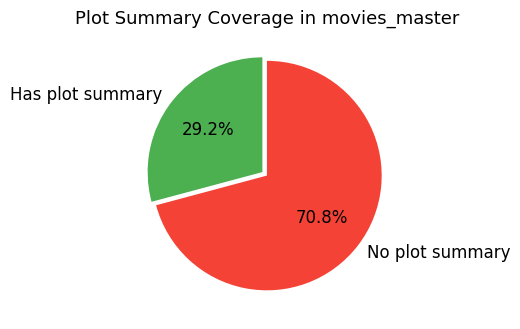

In [62]:
import matplotlib.pyplot as plt

labels  = ["Has plot summary", "No plot summary"]
sizes   = [has_plot, no_plot]
colors  = ["#4CAF50", "#F44336"]
explode = (0.05, 0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(sizes, labels=labels, colors=colors, explode=explode,
       autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12})
ax.set_title("Plot Summary Coverage in movies_master", fontsize=13)
plt.tight_layout()
plt.show()

## Summary

| Task | Status |
|---|---|
| MovieLens → IMDb `tconst` bridge built | ✓ |
| Merged IMDb basics (title, year, genres, runtime) | ✓ |
| Merged IMDb ratings (avgRating, numVotes) | ✓ |
| CMU plots attached via normalised title+year (2-pass) | ✓ |
| `movies_master.csv` saved to `data/processed/` | ✓ |
| Coverage stats & pie chart printed | ✓ |

Ready for Day 4 — Text Preprocessing & Vocabulary Building.

---

# Day 4 — Data Filtering & Ratings Processing

Goal: drop sparse movies, split ratings temporally, save clean train/test splits.

1. Filter movies: require plot summary + ≥10 ratings
2. Filter ratings to surviving movies
3. Print stats
4. Per-user temporal 80/20 train/test split
5. Save `ratings_train.csv`, `ratings_test.csv`, updated `movies_master.csv`

In [65]:
import os, importlib.util
import pandas as pd
import numpy as np

PROJECT_ROOT = os.getcwd()

config_path  = os.path.join(PROJECT_ROOT, "config.py")
spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)
print("Config loaded.")

Config loaded.


## 1. Filter Movies

Rules:
- Must have a `plot_summary` (can't encode vibe without text)
- Must have ≥ 10 ratings in `ratings.csv` (too sparse otherwise)

In [66]:
movies = pd.read_csv(cfg.MOVIES_MASTER)
ratings_raw = pd.read_csv(cfg.MOVIELENS_RATINGS)

print(f"Before filtering:")
print(f"  Movies  : {len(movies):>8,}")
print(f"  Ratings : {len(ratings_raw):>8,}")

# ── Step 1: drop movies without a plot summary ────────────────────────────────
movies_with_plot = movies[movies["plot_summary"].notna()].copy()
print(f"\nAfter requiring plot_summary : {len(movies_with_plot):,} movies "
      f"({len(movies)-len(movies_with_plot):,} dropped)")

# ── Step 2: count ratings per movie, drop < MIN_RATINGS ───────────────────────
rating_counts = ratings_raw.groupby("movieId").size().rename("n_ratings")
movies_with_plot = movies_with_plot.join(rating_counts, on="movieId")
movies_filtered  = movies_with_plot[movies_with_plot["n_ratings"] >= cfg.MIN_RATINGS].copy()
movies_filtered  = movies_filtered.drop(columns=["n_ratings"])

print(f"After requiring ≥{cfg.MIN_RATINGS} ratings : {len(movies_filtered):,} movies "
      f"({len(movies_with_plot)-len(movies_filtered):,} more dropped)")

surviving_ids = set(movies_filtered["movieId"])

Before filtering:
  Movies  :   62,423
  Ratings : 25,000,095

After requiring plot_summary : 18,207 movies (44,216 dropped)
After requiring ≥10 ratings : 12,111 movies (6,096 more dropped)


## 2. Filter Ratings & Print Stats

In [67]:
ratings = ratings_raw[ratings_raw["movieId"].isin(surviving_ids)].copy()

n_movies  = movies_filtered["movieId"].nunique()
n_users   = ratings["userId"].nunique()
n_ratings = len(ratings)
density   = n_ratings / (n_movies * n_users) * 100

print("═" * 45)
print("  Dataset stats after filtering")
print("═" * 45)
print(f"  Movies          : {n_movies:>8,}")
print(f"  Users           : {n_users:>8,}")
print(f"  Ratings         : {n_ratings:>8,}")
print(f"  Matrix density  : {density:>8.4f}%")
print(f"  Avg ratings/movie: {n_ratings/n_movies:>7.1f}")
print(f"  Avg ratings/user : {n_ratings/n_users:>7.1f}")
print("═" * 45)

═════════════════════════════════════════════
  Dataset stats after filtering
═════════════════════════════════════════════
  Movies          :   12,111
  Users           :  162,525
  Ratings         : 21,663,989
  Matrix density  :   1.1006%
  Avg ratings/movie:  1788.8
  Avg ratings/user :   133.3
═════════════════════════════════════════════


## 3. Per-User Temporal Train/Test Split

For each user: sort their ratings by `timestamp` ascending, take earliest 80% as train and latest 20% as test.  
This simulates predicting future preferences from past behaviour — no data leakage.

In [68]:
from tqdm import tqdm

ratings = ratings.sort_values(["userId", "timestamp"]).reset_index(drop=True)

train_idx, test_idx = [], []

for uid, grp in tqdm(ratings.groupby("userId"), desc="Splitting users"):
    n      = len(grp)
    cutoff = max(1, int(n * cfg.TRAIN_SPLIT))   # at least 1 in train
    train_idx.extend(grp.index[:cutoff].tolist())
    test_idx.extend(grp.index[cutoff:].tolist())

ratings_train = ratings.loc[train_idx].reset_index(drop=True)
ratings_test  = ratings.loc[test_idx].reset_index(drop=True)

print(f"Train ratings : {len(ratings_train):,}  ({len(ratings_train)/n_ratings*100:.1f}%)")
print(f"Test  ratings : {len(ratings_test):,}  ({len(ratings_test)/n_ratings*100:.1f}%)")
print(f"Users in train: {ratings_train['userId'].nunique():,}")
print(f"Users in test : {ratings_test['userId'].nunique():,}")

Splitting users: 100%|██████████| 162525/162525 [00:03<00:00, 42220.32it/s]


Train ratings : 17,266,907  (79.7%)
Test  ratings : 4,397,082  (20.3%)
Users in train: 162,525
Users in test : 162,519


## 4. Save Files

In [69]:
ratings_train.to_csv(cfg.RATINGS_TRAIN, index=False)
ratings_test.to_csv(cfg.RATINGS_TEST,   index=False)
movies_filtered.to_csv(cfg.MOVIES_MASTER, index=False)  # overwrite with filtered version

print(f"[OK] {cfg.RATINGS_TRAIN}")
print(f"[OK] {cfg.RATINGS_TEST}")
print(f"[OK] {cfg.MOVIES_MASTER}  (filtered)")

[OK] c:\Users\robin\Desktop\VibeRec\data\processed\ratings_train.csv
[OK] c:\Users\robin\Desktop\VibeRec\data\processed\ratings_test.csv
[OK] c:\Users\robin\Desktop\VibeRec\data\processed\movies_master.csv  (filtered)


## Summary — Day 4

| Task | Status |
|---|---|
| Dropped movies without plot summary | ✓ |
| Dropped movies with < 10 ratings | ✓ |
| Printed dataset stats | ✓ |
| Per-user temporal 80/20 split | ✓ |
| Saved ratings_train/test + filtered movies_master | ✓ |

---

# Day 5 — Text Preprocessing Pipeline

Goal: turn raw plot summaries into padded integer sequences ready for the encoder.

1. `preprocess_text()`: lowercase → strip HTML → remove special chars → tokenize → remove stopwords → lemmatize
2. Build vocabulary (top 40K, `<PAD>`, `<UNK>`)
3. Convert summaries to padded integer sequences (max 500 tokens)
4. Save `plot_sequences.npy` and `word2idx.pkl`

In [70]:
import os, importlib.util, re, pickle
import pandas as pd
import numpy as np
from collections import Counter
import nltk
import spacy
from tqdm import tqdm

PROJECT_ROOT = os.getcwd()
config_path  = os.path.join(PROJECT_ROOT, "config.py")
spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

nltk.download("punkt",      quiet=True)
nltk.download("stopwords",  quiet=True)
nltk.download("punkt_tab",  quiet=True)

nlp        = spacy.load("en_core_web_sm", disable=["parser", "ner"])
stop_words = set(nltk.corpus.stopwords.words("english"))
print("Libraries ready.")

Libraries ready.


## 1. `preprocess_text()` Function

In [72]:
_HTML_TAG   = re.compile(r"<[^>]+>")
_NON_ALPHA  = re.compile(r"[^a-z\s]")
_MULTI_SPC  = re.compile(r"\s+")

def preprocess_text(text: str) -> list[str]:
    """
    Returns a list of lemmatised tokens with stopwords removed.
    Pipeline: lowercase → strip HTML → remove non-alpha → tokenize
              → remove stopwords → spaCy lemmatise
    """
    text = text.lower()
    text = _HTML_TAG.sub(" ", text)
    text = _NON_ALPHA.sub(" ", text)
    text = _MULTI_SPC.sub(" ", text).strip()

    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    # spaCy lemmatisation in batch via nlp.pipe is faster; single doc here
    doc    = nlp(" ".join(tokens))
    lemmas = [token.lemma_ for token in doc if token.lemma_.strip()]
    return lemmas

# Smoke test
sample = "The <b>film</b> follows a darkly-funny, twist-filled journey through 1980s New York."
print(preprocess_text(sample))

['film', 'follow', 'darkly', 'funny', 'twist', 'fill', 'journey', 'new', 'york']


## 2. Tokenise All Plot Summaries

Using `nlp.pipe` for batch spaCy processing (much faster than calling per-doc).

In [73]:
movies = pd.read_csv(cfg.MOVIES_MASTER)

def _clean_for_pipe(text):
    """Pre-clean before handing to spaCy pipe."""
    text = text.lower()
    text = _HTML_TAG.sub(" ", text)
    text = _NON_ALPHA.sub(" ", text)
    return _MULTI_SPC.sub(" ", text).strip()

# Pre-clean + remove stopwords with NLTK (fast)
pre_cleaned = []
for raw in tqdm(movies["plot_summary"], desc="Pre-cleaning"):
    tokens = nltk.word_tokenize(_clean_for_pipe(str(raw)))
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    pre_cleaned.append(" ".join(tokens))

# Batch lemmatise with spaCy (batch_size controls memory vs speed)
tokenised_plots = []
for doc in tqdm(
    nlp.pipe(pre_cleaned, batch_size=256),
    total=len(pre_cleaned),
    desc="Lemmatising"
):
    tokenised_plots.append([t.lemma_ for t in doc if t.lemma_.strip()])

print(f"Tokenised {len(tokenised_plots):,} plot summaries.")
print(f"Example (first 15 tokens): {tokenised_plots[0][:15]}")

Lemmatising: 100%|██████████| 12111/12111 [03:09<00:00, 63.88it/s] 

Tokenised 12,111 plot summaries.
Example (first 15 tokens): ['woody', 'pull', 'string', 'cowboy', 'doll', 'leader', 'group', 'toy', 'belong', 'boy', 'name', 'andy', 'davis', 'act', 'lifeless']


## 3. Build Vocabulary

In [74]:
freq = Counter(token for doc in tokenised_plots for token in doc)
print(f"Unique tokens before trimming : {len(freq):,}")

# Reserve index 0 for <PAD>, index 1 for <UNK>
word2idx = {cfg.PAD_TOKEN: 0, cfg.UNK_TOKEN: 1}
for word, _ in freq.most_common(cfg.VOCAB_SIZE - 2):   # -2 for PAD + UNK
    word2idx[word] = len(word2idx)

idx2word = {v: k for k, v in word2idx.items()}

print(f"Vocabulary size  : {len(word2idx):,}  (capped at {cfg.VOCAB_SIZE:,})")
print(f"  PAD index      : {word2idx[cfg.PAD_TOKEN]}")
print(f"  UNK index      : {word2idx[cfg.UNK_TOKEN]}")
print(f"  Top-5 words    : {list(word2idx.items())[2:7]}")

Unique tokens before trimming : 69,063
Vocabulary size  : 40,000  (capped at 40,000)
  PAD index      : 0
  UNK index      : 1
  Top-5 words    : [('find', 2), ('take', 3), ('go', 4), ('tell', 5), ('kill', 6)]


## 4. Convert to Padded Integer Sequences & Save

In [75]:
UNK_IDX = word2idx[cfg.UNK_TOKEN]
PAD_IDX = word2idx[cfg.PAD_TOKEN]
MAX_LEN = cfg.PLOT_MAX_LEN

plot_sequences = np.zeros((len(tokenised_plots), MAX_LEN), dtype=np.int32)

for i, tokens in enumerate(tqdm(tokenised_plots, desc="Encoding")):
    ids = [word2idx.get(t, UNK_IDX) for t in tokens[:MAX_LEN]]
    plot_sequences[i, :len(ids)] = ids   # tail stays 0 (PAD)

print(f"plot_sequences shape : {plot_sequences.shape}")
print(f"  dtype              : {plot_sequences.dtype}")
non_pad = (plot_sequences != PAD_IDX).sum(axis=1)
print(f"  Avg non-pad tokens : {non_pad.mean():.1f}")
print(f"  Max non-pad tokens : {non_pad.max()}")

# Save
np.save(cfg.PLOT_SEQUENCES, plot_sequences)
with open(cfg.WORD2IDX_PATH, "wb") as f:
    pickle.dump(word2idx, f)

print(f"\n[OK] {cfg.PLOT_SEQUENCES}")
print(f"[OK] {cfg.WORD2IDX_PATH}")

Encoding: 100%|██████████| 12111/12111 [00:00<00:00, 19627.35it/s]

plot_sequences shape : (12111, 500)
  dtype              : int32
  Avg non-pad tokens : 247.3
  Max non-pad tokens : 500

[OK] c:\Users\robin\Desktop\VibeRec\data\processed\plot_sequences.npy
[OK] c:\Users\robin\Desktop\VibeRec\data\processed\word2idx.pkl


## Summary — Day 5

| Task | Status |
|---|---|
| `preprocess_text()` function (HTML, stopwords, lemmatise) | ✓ |
| Batch tokenised all plot summaries with spaCy pipe | ✓ |
| Built vocabulary (top 40K + PAD + UNK) | ✓ |
| Padded integer sequences (max 500) | ✓ |
| Saved `plot_sequences.npy` + `word2idx.pkl` | ✓ |

---

# Day 6 — Simulated Review / Vibe Text

**Problem**: MovieLens has no full user reviews.  
**Solution**: use `tags.csv` — user-applied freeform tags (e.g. "funny", "dark atmosphere", "plot twist") as proxy vibe phrases.

**Approach**: for each movie, concatenate all unique tags into one pseudo-review string, preprocess with the same pipeline, and encode to padded sequences (max 200 tokens).

**Why tags and not tag-genome scores?**  
Tag genome gives a *relevance score* per movie×tag — useful as a dense feature vector but not as text. We use raw tags for the text encoder branch; tag genome scores go into the metadata feature vector in Day 8.

1. Aggregate tags per movie → pseudo-review string
2. Preprocess with `preprocess_text()`
3. Encode to padded sequences (max 200 tokens)
4. Save `review_sequences.npy`

In [76]:
import os, importlib.util, pickle
import pandas as pd
import numpy as np
from collections import Counter
import nltk, spacy, re
from tqdm import tqdm

PROJECT_ROOT = os.getcwd()
config_path  = os.path.join(PROJECT_ROOT, "config.py")
spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

# Load the vocabulary built in Day 5
with open(cfg.WORD2IDX_PATH, "rb") as f:
    word2idx = pickle.load(f)

nlp        = spacy.load("en_core_web_sm", disable=["parser", "ner"])
stop_words = set(nltk.corpus.stopwords.words("english"))

_HTML_TAG  = re.compile(r"<[^>]+>")
_NON_ALPHA = re.compile(r"[^a-z\s]")
_MULTI_SPC = re.compile(r"\s+")

print(f"Vocab size loaded : {len(word2idx):,}")
print("Ready.")

Vocab size loaded : 40,000
Ready.


## 1. Aggregate Tags per Movie

In [77]:
movies  = pd.read_csv(cfg.MOVIES_MASTER)
ml_tags = pd.read_csv(cfg.MOVIELENS_TAGS)

# Keep only tags for surviving movies; drop missing tags; deduplicate per movie
tags_filtered = ml_tags[ml_tags["movieId"].isin(set(movies["movieId"]))].copy()
tags_filtered = tags_filtered.dropna(subset=["tag"])
tags_filtered["tag"] = tags_filtered["tag"].astype(str).str.strip().str.lower()
tags_filtered = tags_filtered.drop_duplicates(subset=["movieId", "tag"])

# Concatenate all unique tags per movie into one string
pseudo_reviews = (
    tags_filtered
    .groupby("movieId")["tag"]
    .apply(lambda tags: " ".join(tags))
    .rename("pseudo_review")
    .reset_index()
)

movies = movies.merge(pseudo_reviews, on="movieId", how="left")

n_with_tags = movies["pseudo_review"].notna().sum()
print(f"Movies with at least one tag : {n_with_tags:,} / {len(movies):,}")
print(f"Movies with NO tags          : {len(movies) - n_with_tags:,}")
print(f"\nExample pseudo-review (first movie with tags):")
sample = movies[movies["pseudo_review"].notna()].iloc[0]
print(f"  {sample['title']} → {sample['pseudo_review'][:120]}...")

Movies with at least one tag : 11,795 / 12,111
Movies with NO tags          : 316

Example pseudo-review (first movie with tags):
  Toy Story → owned imdb top 250 pixar time travel children comedy funny witty rated-g animation computer animation good cartoon chind...


## 2. Preprocess & Encode → `review_sequences.npy`

Movies with no tags get an all-zeros (all-PAD) sequence.

In [78]:
UNK_IDX  = word2idx[cfg.UNK_TOKEN]
MAX_LEN  = cfg.REVIEW_MAX_LEN

raw_texts = movies["pseudo_review"].fillna("").tolist()

# Pre-clean
pre_cleaned = []
for text in tqdm(raw_texts, desc="Pre-cleaning"):
    text = text.lower()
    text = _HTML_TAG.sub(" ", text)
    text = _NON_ALPHA.sub(" ", text)
    text = _MULTI_SPC.sub(" ", text).strip()
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    pre_cleaned.append(" ".join(tokens))

# Batch lemmatise
tokenised_reviews = []
for doc in tqdm(nlp.pipe(pre_cleaned, batch_size=256),
                total=len(pre_cleaned), desc="Lemmatising"):
    tokenised_reviews.append([t.lemma_ for t in doc if t.lemma_.strip()])

# Encode
review_sequences = np.zeros((len(tokenised_reviews), MAX_LEN), dtype=np.int32)
for i, tokens in enumerate(tqdm(tokenised_reviews, desc="Encoding")):
    ids = [word2idx.get(t, UNK_IDX) for t in tokens[:MAX_LEN]]
    review_sequences[i, :len(ids)] = ids

np.save(cfg.REVIEW_SEQUENCES, review_sequences)

non_pad = (review_sequences != 0).sum(axis=1)
print(f"review_sequences shape : {review_sequences.shape}")
print(f"  Avg non-pad tokens   : {non_pad.mean():.1f}")
print(f"  Movies with no tags  : {(non_pad == 0).sum():,}")
print(f"\n[OK] {cfg.REVIEW_SEQUENCES}")

Encoding: 100%|██████████| 12111/12111 [00:00<00:00, 115895.47it/s]

review_sequences shape : (12111, 200)
  Avg non-pad tokens   : 31.9
  Movies with no tags  : 318

[OK] c:\Users\robin\Desktop\VibeRec\data\processed\review_sequences.npy


## Summary — Day 6

| Task | Status |
|---|---|
| Aggregated tags per movie into pseudo-review string | ✓ |
| Documented choice (raw tags for text; genome for metadata) | ✓ |
| Preprocessed with same pipeline as Day 5 | ✓ |
| Encoded to padded sequences (max 200) | ✓ |
| Saved `review_sequences.npy` | ✓ |

---

# Day 7 — Word Embeddings Setup

Goal: build an embedding matrix `(vocab_size, 300)` from GloVe 6B 300d.

- Words in GloVe → use GloVe vector
- Words not in GloVe → random normal (std=0.01)
- `<PAD>` → zero vector
- Verify with cosine similarity: "funny" vs "hilarious" should be high
- Save `embedding_matrix.npy`

## 1. Download GloVe 6B 300d

~820 MB zip from the Stanford NLP group. Extracted to `data/raw/glove/`.

In [8]:
import os, importlib.util, pickle, zipfile
import numpy as np
import urllib.request
from tqdm import tqdm

PROJECT_ROOT = os.getcwd()
config_path  = os.path.join(PROJECT_ROOT, "config.py")
spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

with open(cfg.WORD2IDX_PATH, "rb") as f:
    word2idx = pickle.load(f)
idx2word = {v: k for k, v in word2idx.items()}

GLOVE_DIR = os.path.join(cfg.DATA_RAW, "glove")
GLOVE_ZIP = os.path.join(cfg.DATA_RAW, "glove.6B.zip")
GLOVE_URL = "https://nlp.stanford.edu/data/glove.6B.zip"
os.makedirs(GLOVE_DIR, exist_ok=True)

if os.path.exists(cfg.GLOVE_PATH):
    print("[SKIP] GloVe already present.")
else:
    class _Progress(tqdm):
        def update_to(self, b=1, bsize=1, tsize=None):
            if tsize: self.total = tsize
            self.update(b * bsize - self.n)

    print("Downloading GloVe 6B (~820 MB)...")
    with _Progress(unit="B", unit_scale=True, miniters=1, desc="glove.6B.zip") as t:
        urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP, reporthook=t.update_to)

    print("Extracting glove.6B.300d.txt ...")
    with zipfile.ZipFile(GLOVE_ZIP, "r") as z:
        z.extract("glove.6B.300d.txt", GLOVE_DIR)
    os.remove(GLOVE_ZIP)
    print("[OK] GloVe extracted.")

size_mb = os.path.getsize(cfg.GLOVE_PATH) / 1e6
print(f"glove.6B.300d.txt  {size_mb:.0f} MB")

[SKIP] GloVe already present.
glove.6B.300d.txt  1038 MB


## 2. Build Embedding Matrix

In [9]:
VOCAB_SIZE = len(word2idx)
EMBED_DIM  = cfg.EMBEDDING_DIM   # 300

# Initialise: random normal for all rows, zero for PAD row
rng = np.random.default_rng(seed=42)
embedding_matrix = rng.normal(0, 0.01, (VOCAB_SIZE, EMBED_DIM)).astype(np.float32)
embedding_matrix[word2idx[cfg.PAD_TOKEN]] = 0.0   # PAD → zero vector

# Parse GloVe and fill in known words
glove_hits = 0
print("Loading GloVe vectors...")
with open(cfg.GLOVE_PATH, "r", encoding="utf-8") as f:
    for line in tqdm(f, total=400_000, desc="GloVe"):
        parts = line.rstrip().split(" ")
        word  = parts[0]
        if word in word2idx:
            embedding_matrix[word2idx[word]] = np.array(parts[1:], dtype=np.float32)
            glove_hits += 1

glove_miss = VOCAB_SIZE - glove_hits - 1  # -1 for PAD (not a "miss")
print(f"\nVocab size           : {VOCAB_SIZE:,}")
print(f"GloVe hits           : {glove_hits:,}  ({glove_hits/VOCAB_SIZE*100:.1f}%)")
print(f"Random init (OOV)    : {glove_miss:,}  ({glove_miss/VOCAB_SIZE*100:.1f}%)")
print(f"PAD (zero vector)    : 1")
print(f"Embedding matrix     : {embedding_matrix.shape}  dtype={embedding_matrix.dtype}")

Loading GloVe vectors...


GloVe: 100%|██████████| 400000/400000 [00:08<00:00, 48386.49it/s]


Vocab size           : 40,000
GloVe hits           : 35,506  (88.8%)
Random init (OOV)    : 4,493  (11.2%)
PAD (zero vector)    : 1
Embedding matrix     : (40000, 300)  dtype=float32


## 3. Cosine Similarity Verification

In [10]:
def cosine_sim(w1, w2):
    if w1 not in word2idx or w2 not in word2idx:
        return None, f"'{w1}' or '{w2}' not in vocab"
    v1 = embedding_matrix[word2idx[w1]]
    v2 = embedding_matrix[word2idx[w2]]
    sim = float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-9))
    return sim, "OK"

pairs = [
    ("funny",    "hilarious"),   # should be HIGH
    ("dark",     "gloomy"),      # should be HIGH
    ("love",     "romance"),     # should be HIGH
    ("action",   "comedy"),      # moderate — different genres
    ("funny",    "murder"),      # should be LOW
]

print(f"{'Word 1':12s}  {'Word 2':12s}  {'Cosine Sim':>10s}")
print("─" * 40)
for w1, w2 in pairs:
    sim, status = cosine_sim(w1, w2)
    if sim is not None:
        print(f"  {w1:10s}  {w2:10s}  {sim:10.4f}")
    else:
        print(f"  {w1:10s}  {w2:10s}  {status}")

Word 1        Word 2        Cosine Sim
────────────────────────────────────────
  funny       hilarious       0.7324
  dark        gloomy          0.3711
  love        romance         0.5692
  action      comedy          0.2848
  funny       murder          0.0526


## 4. Save Embedding Matrix

In [11]:
np.save(cfg.EMBEDDING_MATRIX, embedding_matrix)
size_mb = os.path.getsize(cfg.EMBEDDING_MATRIX) / 1e6
print(f"[OK] {cfg.EMBEDDING_MATRIX}")
print(f"     Shape : {embedding_matrix.shape}")
print(f"     Size  : {size_mb:.1f} MB")

# Sanity check: PAD row should be all zeros
assert np.all(embedding_matrix[0] == 0), "PAD row is not zero!"
print("\n[OK] PAD row verified as zero vector.")

[OK] c:\Users\robin\Desktop\VibeRec\data\processed\embedding_matrix.npy
     Shape : (40000, 300)
     Size  : 48.0 MB

[OK] PAD row verified as zero vector.


In [12]:
pip install --upgrade numpy scipy scikit-learn

   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ------------- -------------------------- 4.2/12.3 MB 22.9 MB/s eta 0:00:01
   ---------------------------- ----------- 8.9/12.3 MB 22.1 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 21.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---

# Day 8 — Metadata Feature Engineering

Goal: build a numeric feature vector per movie from structured fields in `movies_master.csv`.

1. One-hot encode genres with `MultiLabelBinarizer` (~20 binary cols)
2. Normalize `runtime` → [0, 1] with `MinMaxScaler`
3. Normalize `avgRating` → [0, 1]
4. Normalize `log1p(numVotes)` → [0, 1]
5. Concatenate → ~23-dim metadata vector per movie
6. Save `metadata_features.npy` + matching `movie_id_to_idx.pkl`

In [13]:
import os, importlib.util, pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler

PROJECT_ROOT = os.getcwd()
config_path  = os.path.join(PROJECT_ROOT, "config.py")
spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

movies = pd.read_csv(cfg.MOVIES_MASTER)
print(f"Loaded movies_master: {movies.shape}")
display(movies[["movieId", "genres", "runtime", "avgRating", "numVotes"]].head(3))

Loaded movies_master: (12111, 10)


,movieId,genres,runtime,avgRating,numVotes
0,1,"Adventure,Animation,Comedy",81.0,8.3,1170470.0
1,2,"Adventure,Comedy,Family",104.0,7.1,411908.0
2,3,"Comedy,Romance",101.0,6.7,31643.0


## 1. One-Hot Encode Genres

In [14]:
# genres column is pipe-separated (IMDb) or comma-separated (ML fallback) — normalise to list
def parse_genres(g):
    if pd.isna(g):
        return []
    # handle both '|' and ',' separators
    sep = "|" if "|" in str(g) else ","
    return [x.strip() for x in str(g).split(sep) if x.strip() and x.strip() != "\\N"]

movies["genre_list"] = movies["genres"].apply(parse_genres)

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movies["genre_list"])   # shape (n_movies, n_genres)
genre_cols   = list(mlb.classes_)

print(f"Genre classes ({len(genre_cols)}): {genre_cols}")
print(f"Genre matrix shape: {genre_matrix.shape}")

Genre classes (26): ['(no genres listed)', 'Action', 'Adult', 'Adventure', 'Animation', 'Biography', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western']
Genre matrix shape: (12111, 26)


## 2. Normalize Scalar Features

In [15]:
scaler = MinMaxScaler()

# Fill NaN with median before scaling so no row becomes all-zero
runtime_vals   = movies["runtime"].fillna(movies["runtime"].median()).values.reshape(-1, 1)
rating_vals    = movies["avgRating"].fillna(movies["avgRating"].median()).values.reshape(-1, 1)
votes_log_vals = np.log1p(movies["numVotes"].fillna(0)).values.reshape(-1, 1)

runtime_scaled   = scaler.fit_transform(runtime_vals)
rating_scaled    = scaler.fit_transform(rating_vals)
votes_log_scaled = scaler.fit_transform(votes_log_vals)

print(f"runtime   : min={runtime_scaled.min():.3f}  max={runtime_scaled.max():.3f}")
print(f"avgRating : min={rating_scaled.min():.3f}  max={rating_scaled.max():.3f}")
print(f"log(votes): min={votes_log_scaled.min():.3f}  max={votes_log_scaled.max():.3f}")

runtime   : min=0.000  max=1.000
avgRating : min=0.000  max=1.000
log(votes): min=0.000  max=1.000


## 3. Concatenate & Save

In [16]:
metadata_features = np.hstack([
    genre_matrix.astype(np.float32),   # (n, n_genres)
    runtime_scaled.astype(np.float32),  # (n, 1)
    rating_scaled.astype(np.float32),   # (n, 1)
    votes_log_scaled.astype(np.float32),# (n, 1)
])

print(f"metadata_features shape : {metadata_features.shape}")
print(f"  genre dims   : {genre_matrix.shape[1]}")
print(f"  scalar dims  : 3  (runtime, avgRating, log_votes)")
print(f"  total dims   : {metadata_features.shape[1]}")
print(f"  dtype        : {metadata_features.dtype}")

# Movie ID → row index mapping (needed by the model to look up a movie's vector)
movie_id_to_idx = {mid: i for i, mid in enumerate(movies["movieId"])}

np.save(cfg.METADATA_FEATURES, metadata_features)
with open(cfg.MOVIE_ID_TO_IDX, "wb") as f:
    pickle.dump(movie_id_to_idx, f)

print(f"\n[OK] {cfg.METADATA_FEATURES}")
print(f"[OK] {cfg.MOVIE_ID_TO_IDX}")

# Shape verification
assert metadata_features.shape[0] == len(movies), "Row count mismatch!"
assert metadata_features.shape[1] == genre_matrix.shape[1] + 3, "Column count mismatch!"
print("\n[OK] Shape assertions passed.")

metadata_features shape : (12111, 29)
  genre dims   : 26
  scalar dims  : 3  (runtime, avgRating, log_votes)
  total dims   : 29
  dtype        : float32

[OK] c:\Users\robin\Desktop\VibeRec\data\processed\metadata_features.npy
[OK] c:\Users\robin\Desktop\VibeRec\embeddings\movie_id_to_idx.pkl

[OK] Shape assertions passed.


## Summary — Day 8

| Task | Status |
|---|---|
| Genres one-hot encoded with `MultiLabelBinarizer` | ✓ |
| `runtime` normalized → [0, 1] | ✓ |
| `avgRating` normalized → [0, 1] | ✓ |
| `log1p(numVotes)` normalized → [0, 1] | ✓ |
| Concatenated to ~23-dim metadata vector | ✓ |
| Saved `metadata_features.npy` + `movie_id_to_idx.pkl` | ✓ |
| Shape assertions passed | ✓ |

---

# Day 9 — CNN Review Vibe Encoder (PyTorch)

Architecture: `Embedding (frozen) → 3× parallel Conv1d → ReLU → GlobalMaxPool → Concat → Dropout → Linear`

- Input: `(batch, 200)` integer token sequence (review/tag pseudo-text)
- Output: `(batch, 128)` review vibe vector

In [17]:
import os, importlib.util
import numpy as np
import torch
import torch.nn as nn

PROJECT_ROOT = os.getcwd()
config_path  = os.path.join(PROJECT_ROOT, "config.py")
spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

device = torch.device(cfg.DEVICE)
print(f"Device: {device}")

# Load embedding matrix built in Day 7
emb_matrix = np.load(cfg.EMBEDDING_MATRIX)   # (vocab_size, 300)
emb_tensor  = torch.tensor(emb_matrix, dtype=torch.float32)
print(f"Embedding matrix loaded: {emb_tensor.shape}")

Device: cuda
Embedding matrix loaded: torch.Size([40000, 300])


## `CNNVibeEncoder` — Module Definition

In [18]:
class CNNVibeEncoder(nn.Module):
    """
    Text-CNN encoder for short vibe / review sequences.

    Input : (batch, seq_len)  — integer token ids
    Output: (batch, out_dim)  — dense vibe embedding

    Architecture:
        Embedding (frozen GloVe)
        → 3 parallel Conv1d branches (kernel 3, 4, 5; 128 filters each)
        → ReLU → GlobalMaxPool
        → Concat [384-dim]
        → Dropout(0.3)
        → Linear(384, 128)
    """
    def __init__(
        self,
        embedding_matrix: torch.Tensor,
        num_filters:  int = 128,         # cfg.CNN_FILTERS
        kernel_sizes: list = [3, 4, 5],  # cfg.CNN_KERNELS
        out_dim:      int = 128,         # cfg.CNN_OUT_DIM
        dropout:      float = 0.3,       # cfg.DROPOUT_VIBE
    ):
        super().__init__()

        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=True, padding_idx=0
        )

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim,
                out_channels=num_filters,
                kernel_size=k,
            )
            for k in kernel_sizes
        ])

        concat_dim = num_filters * len(kernel_sizes)   # 128 * 3 = 384
        self.dropout    = nn.Dropout(dropout)
        self.projection = nn.Linear(concat_dim, out_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len)
        emb = self.embedding(x)          # (batch, seq_len, embed_dim)
        emb = emb.permute(0, 2, 1)       # (batch, embed_dim, seq_len) — Conv1d expects this

        pooled = []
        for conv in self.convs:
            h = torch.relu(conv(emb))    # (batch, num_filters, seq_len - k + 1)
            h = h.max(dim=2).values      # global max pool → (batch, num_filters)
            pooled.append(h)

        out = torch.cat(pooled, dim=1)   # (batch, 384)
        out = self.dropout(out)
        out = self.projection(out)       # (batch, 128)
        return out

## Unit Test — `CNNVibeEncoder`

In [19]:
cnn_encoder = CNNVibeEncoder(
    embedding_matrix=emb_tensor,
    num_filters =cfg.CNN_FILTERS,
    kernel_sizes=cfg.CNN_KERNELS,
    out_dim     =cfg.CNN_OUT_DIM,
    dropout     =cfg.DROPOUT_VIBE,
).to(device)

# Input: batch of 32 review sequences, each length 200
dummy_input = torch.randint(0, emb_tensor.shape[0], (32, cfg.REVIEW_MAX_LEN)).to(device)

cnn_encoder.eval()
with torch.no_grad():
    out = cnn_encoder(dummy_input)

print(f"Input  shape : {tuple(dummy_input.shape)}")
print(f"Output shape : {tuple(out.shape)}")
assert out.shape == (32, cfg.CNN_OUT_DIM), f"Expected (32, {cfg.CNN_OUT_DIM}), got {tuple(out.shape)}"
print("[OK] CNNVibeEncoder unit test passed.")

n_params = sum(p.numel() for p in cnn_encoder.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Input  shape : (32, 200)
Output shape : (32, 128)
[OK] CNNVibeEncoder unit test passed.
Trainable parameters: 510,464


## Summary — Day 9

| Task | Status |
|---|---|
| `CNNVibeEncoder` module written | ✓ |
| Frozen GloVe embedding layer | ✓ |
| 3 parallel Conv1d branches + GlobalMaxPool | ✓ |
| Unit test: (32, 200) → (32, 128) | ✓ |

---

# Day 10 — LSTM Plot Arc Encoder (PyTorch)

Architecture: `Embedding (frozen) → 2-layer BiLSTM → concat final hidden states → Linear`

- Input: `(batch, 500)` integer token sequence (plot summary)
- Output: `(batch, 128)` plot arc vector

## `LSTMPlotEncoder` — Module Definition

In [21]:
import torch
import torch.nn as nn 

class LSTMPlotEncoder(nn.Module):
    """
    Bidirectional LSTM encoder for long plot sequences.

    Input : (batch, seq_len)  — integer token ids
    Output: (batch, out_dim)  — dense plot arc embedding

    Architecture:
        Embedding (frozen GloVe)
        → 2-layer BiLSTM (hidden_size=128 per direction)
        → concat final forward + backward hidden state → 256-dim
        → Linear(256, 128)
    """
    def __init__(
        self,
        embedding_matrix: torch.Tensor,
        hidden_size: int   = 128,    # cfg.LSTM_HIDDEN
        num_layers:  int   = 2,      # cfg.LSTM_LAYERS
        out_dim:     int   = 128,    # cfg.LSTM_OUT_DIM
        dropout:     float = 0.3,    # cfg.DROPOUT_VIBE  (applied between LSTM layers)
    ):
        super().__init__()

        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=True, padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0,
        )

        # BiLSTM final hidden: forward (hidden_size) + backward (hidden_size) = 2 * hidden_size
        self.projection = nn.Linear(2 * hidden_size, out_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len)
        emb = self.embedding(x)               # (batch, seq_len, embed_dim)
        _, (h_n, _) = self.lstm(emb)
        # h_n: (num_layers * 2, batch, hidden_size)
        # take the last layer's forward and backward final hidden states
        fwd = h_n[-2]                         # (batch, hidden_size) — last layer, forward
        bwd = h_n[-1]                         # (batch, hidden_size) — last layer, backward
        out = torch.cat([fwd, bwd], dim=1)    # (batch, 256)
        out = self.projection(out)            # (batch, 128)
        return out

## Unit Test — `LSTMPlotEncoder`

In [22]:
import torch
import torch.backends.cudnn as cudnn

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name:       {torch.cuda.get_device_name(0)}")
    print(f"cuDNN Enabled:   {cudnn.enabled}")

PyTorch Version: 2.5.1+cu121
CUDA Available:  True
GPU Name:       NVIDIA GeForce RTX 4060 Laptop GPU
cuDNN Enabled:   True


In [23]:
lstm_encoder = LSTMPlotEncoder(
    embedding_matrix=emb_tensor,
    hidden_size=cfg.LSTM_HIDDEN,
    num_layers =cfg.LSTM_LAYERS,
    out_dim    =cfg.LSTM_OUT_DIM,
    dropout    =cfg.DROPOUT_VIBE,
).to(device)

# Input: batch of 32 plot sequences, each length 500
dummy_plots = torch.randint(0, emb_tensor.shape[0], (32, cfg.PLOT_MAX_LEN)).to(device)

lstm_encoder.eval()
with torch.no_grad():
    out = lstm_encoder(dummy_plots)

print(f"Input  shape : {tuple(dummy_plots.shape)}")
print(f"Output shape : {tuple(out.shape)}")
assert out.shape == (32, cfg.LSTM_OUT_DIM), f"Expected (32, {cfg.LSTM_OUT_DIM}), got {tuple(out.shape)}"
print("[OK] LSTMPlotEncoder unit test passed.")

n_params = sum(p.numel() for p in lstm_encoder.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Input  shape : (32, 500)
Output shape : (32, 128)
[OK] LSTMPlotEncoder unit test passed.
Trainable parameters: 868,480


## Summary — Day 10

| Task | Status |
|---|---|
| `LSTMPlotEncoder` module written | ✓ |
| Frozen GloVe embedding layer | ✓ |
| 2-layer BiLSTM, concat final fwd+bwd hidden | ✓ |
| Unit test: (32, 500) → (32, 128) | ✓ |

---

# Day 11 — Combined Vibe Encoder (PyTorch)

`VibeEncoder` fuses the CNN (review), LSTM (plot), and metadata branches into a single 128-dim movie vibe embedding.

```
review_seq  → CNNVibeEncoder  → 128-dim  ┐
plot_seq    → LSTMPlotEncoder → 128-dim  ├─ cat → 320-dim → Linear(320,256) → ReLU → Dropout → Linear(256,128)
metadata    → Linear(23,64) → ReLU → 64-dim  ┘
```

Output: `(batch, 128)` vibe embedding per movie.

## `VibeEncoder` — Module Definition

In [24]:
class VibeEncoder(nn.Module):
    """
    Combined vibe encoder: fuses CNN (review), LSTM (plot), and metadata.

    Inputs:
        review_seq  : (batch, review_max_len)  — tag pseudo-review token ids
        plot_seq    : (batch, plot_max_len)    — plot summary token ids
        metadata    : (batch, metadata_dim)    — normalized metadata features

    Output: (batch, vibe_embed_dim)  — 128-dim movie vibe embedding

    Architecture:
        review_seq  → CNNVibeEncoder  → 128-dim  ─┐
        plot_seq    → LSTMPlotEncoder → 128-dim   ├─ cat [320] → MLP → 128-dim
        metadata    → Linear(23,64) → ReLU → 64 ─┘
    """
    def __init__(
        self,
        embedding_matrix: torch.Tensor,
        metadata_dim:     int   = 23,    # cfg.METADATA_DIM
        meta_proj_dim:    int   = 64,    # cfg.METADATA_PROJ_DIM
        vibe_embed_dim:   int   = 128,   # cfg.VIBE_EMBED_DIM
        dropout:          float = 0.3,   # cfg.DROPOUT_VIBE
        # CNN kwargs
        cnn_filters:  int  = 128,
        cnn_kernels:  list = [3, 4, 5],
        cnn_out_dim:  int  = 128,
        # LSTM kwargs
        lstm_hidden:  int  = 128,
        lstm_layers:  int  = 2,
        lstm_out_dim: int  = 128,
    ):
        super().__init__()

        self.cnn  = CNNVibeEncoder(
            embedding_matrix, cnn_filters, cnn_kernels, cnn_out_dim, dropout
        )
        self.lstm = LSTMPlotEncoder(
            embedding_matrix, lstm_hidden, lstm_layers, lstm_out_dim, dropout
        )

        # Metadata projection branch
        self.meta_proj = nn.Sequential(
            nn.Linear(metadata_dim, meta_proj_dim),
            nn.ReLU(),
        )

        # Fusion MLP
        fused_dim = cnn_out_dim + lstm_out_dim + meta_proj_dim   # 128+128+64 = 320
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, vibe_embed_dim),
        )

    def forward(
        self,
        review_seq: torch.Tensor,   # (batch, review_max_len)
        plot_seq:   torch.Tensor,   # (batch, plot_max_len)
        metadata:   torch.Tensor,   # (batch, metadata_dim)
    ) -> torch.Tensor:
        cnn_out  = self.cnn(review_seq)    # (batch, 128)
        lstm_out = self.lstm(plot_seq)     # (batch, 128)
        meta_out = self.meta_proj(metadata)# (batch, 64)

        fused = torch.cat([cnn_out, lstm_out, meta_out], dim=1)   # (batch, 320)
        return self.fusion(fused)                                  # (batch, 128)

## Unit Test — `VibeEncoder`

In [25]:
# Load actual metadata_dim from saved file to make the test realistic
metadata_features = np.load(cfg.METADATA_FEATURES)
actual_metadata_dim = metadata_features.shape[1]
print(f"Actual metadata_dim from file: {actual_metadata_dim}")

vibe_encoder = VibeEncoder(
    embedding_matrix=emb_tensor,
    metadata_dim  =actual_metadata_dim,
    meta_proj_dim =cfg.METADATA_PROJ_DIM,
    vibe_embed_dim=cfg.VIBE_EMBED_DIM,
    dropout       =cfg.DROPOUT_VIBE,
    cnn_filters   =cfg.CNN_FILTERS,
    cnn_kernels   =cfg.CNN_KERNELS,
    cnn_out_dim   =cfg.CNN_OUT_DIM,
    lstm_hidden   =cfg.LSTM_HIDDEN,
    lstm_layers   =cfg.LSTM_LAYERS,
    lstm_out_dim  =cfg.LSTM_OUT_DIM,
).to(device)

BATCH = 32
dummy_review   = torch.randint(0, emb_tensor.shape[0], (BATCH, cfg.REVIEW_MAX_LEN)).to(device)
dummy_plot     = torch.randint(0, emb_tensor.shape[0], (BATCH, cfg.PLOT_MAX_LEN)).to(device)
dummy_metadata = torch.randn(BATCH, actual_metadata_dim).to(device)

vibe_encoder.eval()
with torch.no_grad():
    out = vibe_encoder(dummy_review, dummy_plot, dummy_metadata)

print(f"\nInputs:")
print(f"  review_seq : {tuple(dummy_review.shape)}")
print(f"  plot_seq   : {tuple(dummy_plot.shape)}")
print(f"  metadata   : {tuple(dummy_metadata.shape)}")
print(f"Output shape : {tuple(out.shape)}")

assert out.shape == (BATCH, cfg.VIBE_EMBED_DIM), \
    f"Expected ({BATCH}, {cfg.VIBE_EMBED_DIM}), got {tuple(out.shape)}"
print("[OK] VibeEncoder unit test passed.")

total_params     = sum(p.numel() for p in vibe_encoder.parameters())
trainable_params = sum(p.numel() for p in vibe_encoder.parameters() if p.requires_grad)
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen (embedding)   : {total_params - trainable_params:,}")

Actual metadata_dim from file: 29

Inputs:
  review_seq : (32, 200)
  plot_seq   : (32, 500)
  metadata   : (32, 29)
Output shape : (32, 128)
[OK] VibeEncoder unit test passed.

Total parameters     : 25,495,936
Trainable parameters : 1,495,936
Frozen (embedding)   : 24,000,000


## Architecture Summary

```
VibeEncoder
├── CNNVibeEncoder  (review_seq)
│   ├── Embedding(vocab, 300)  [frozen]
│   ├── Conv1d(300, 128, k=3) + ReLU + GlobalMaxPool
│   ├── Conv1d(300, 128, k=4) + ReLU + GlobalMaxPool
│   ├── Conv1d(300, 128, k=5) + ReLU + GlobalMaxPool
│   ├── Dropout(0.3)
│   └── Linear(384 → 128)
├── LSTMPlotEncoder  (plot_seq)
│   ├── Embedding(vocab, 300)  [frozen]
│   ├── BiLSTM(300→128, 2 layers)
│   └── Linear(256 → 128)
├── MetadataProjection  (metadata)
│   ├── Linear(metadata_dim → 64)
│   └── ReLU
└── FusionMLP
    ├── Linear(320 → 256) + ReLU
    ├── Dropout(0.3)
    └── Linear(256 → 128)          ← vibe embedding
```

## Summary — Day 11

| Task | Status |
|---|---|
| `VibeEncoder` fusing CNN + LSTM + metadata | ✓ |
| CNN branch: 3 parallel Conv1d → 128-dim | ✓ |
| LSTM branch: BiLSTM → 128-dim | ✓ |
| Metadata branch: Linear(23→64) → ReLU | ✓ |
| Fusion MLP: 320 → 256 → 128 | ✓ |
| Unit test: (batch,200) + (batch,500) + (batch,23) → (batch,128) | ✓ |
| Trainable/frozen param counts printed | ✓ |

Ready for Day 12 — Triplet Loss & VibeEncoder Training.

---

# Day 12 — Training Signal Design & Dataset Class

Goal: define the triplet sampling strategy and build a `TripletMovieDataset` that feeds `(anchor, positive, negative)` triples to the vibe encoder.

- **Anchor**: a movie a user rated ≥ 4.0 (liked)
- **Positive**: a different movie the same user also rated ≥ 4.0
- **Negative**: a movie the same user rated ≤ 2.0 (disliked)

Each element returns `(review_seq, plot_seq, metadata)` for that movie.

In [26]:
import os, importlib.util, pickle
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

PROJECT_ROOT = os.getcwd()
config_path  = os.path.join(PROJECT_ROOT, "config.py")
spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

# ── Load all preprocessed artefacts ──────────────────────────────────────────
movies        = pd.read_csv(cfg.MOVIES_MASTER)
ratings_train = pd.read_csv(cfg.RATINGS_TRAIN)

plot_seqs  = np.load(cfg.PLOT_SEQUENCES)      # (n_movies, 500)
review_seqs= np.load(cfg.REVIEW_SEQUENCES)    # (n_movies, 200)
meta_feats = np.load(cfg.METADATA_FEATURES)   # (n_movies, metadata_dim)

with open(cfg.MOVIE_ID_TO_IDX, "rb") as f:
    movie_id_to_idx = pickle.load(f)

print(f"Movies       : {len(movies):,}")
print(f"Train ratings: {len(ratings_train):,}")
print(f"plot_seqs    : {plot_seqs.shape}")
print(f"review_seqs  : {review_seqs.shape}")
print(f"meta_feats   : {meta_feats.shape}")

Movies       : 12,111
Train ratings: 17,266,907
plot_seqs    : (12111, 500)
review_seqs  : (12111, 200)
meta_feats   : (12111, 29)


## `TripletMovieDataset` — Class Definition

In [28]:
class TripletMovieDataset(Dataset):
    """
    Yields (anchor, positive, negative) triplets where each element is
    a dict with keys: review_seq, plot_seq, metadata.

    Sampling:
        - Anchor  : movie rated >= HIGH_RATING_THRESH by user u
        - Positive: a different movie also rated >= HIGH_RATING_THRESH by u
        - Negative: a movie rated <= 2.0 by u
        Users with < 2 liked movies or 0 disliked movies are excluded.
    """

    HIGH  = 4.0
    LOW   = 2.0

    def __init__(
        self,
        ratings:        pd.DataFrame,
        movie_id_to_idx: dict,
        plot_seqs:      np.ndarray,
        review_seqs:    np.ndarray,
        meta_feats:     np.ndarray,
        seed:           int = 42,
    ):
        self.movie_id_to_idx = movie_id_to_idx
        self.plot_seqs       = plot_seqs
        self.review_seqs     = review_seqs
        self.meta_feats      = meta_feats
        self.rng             = np.random.default_rng(seed)

        # Keep only ratings for movies we have embeddings for
        valid_ids = set(movie_id_to_idx.keys())
        ratings   = ratings[ratings["movieId"].isin(valid_ids)]

        # Build per-user liked/disliked movie lists
        liked    = ratings[ratings["rating"] >= self.HIGH].groupby("userId")["movieId"].apply(list)
        disliked = ratings[ratings["rating"] <= self.LOW].groupby("userId")["movieId"].apply(list)

        # Keep users that have ≥ 2 liked AND ≥ 1 disliked
        valid_users = liked.index.intersection(disliked.index)
        valid_users = [u for u in valid_users if len(liked[u]) >= 2]

        self.liked    = liked[valid_users]
        self.disliked = disliked[valid_users]
        self.users    = list(valid_users)

        print(f"  Eligible users   : {len(self.users):,}")
        print(f"  Dataset __len__  : {len(self):,}  (one triplet per user per epoch)")

    def __len__(self):
        return len(self.users)

    def _movie_tensors(self, movie_id: int) -> dict:
        idx = self.movie_id_to_idx[movie_id]
        return {
            "review_seq": torch.tensor(self.review_seqs[idx], dtype=torch.long),
            "plot_seq"  : torch.tensor(self.plot_seqs[idx],   dtype=torch.long),
            "metadata"  : torch.tensor(self.meta_feats[idx],  dtype=torch.float32),
        }

    def __getitem__(self, i: int):
        user = self.users[i]

        # Sample anchor + positive (two distinct liked movies)
        liked_ids = self.liked[user]
        a_id, p_id = self.rng.choice(liked_ids, size=2, replace=False)

        # Sample one negative
        n_id = self.rng.choice(self.disliked[user])

        return {
            "anchor"  : self._movie_tensors(int(a_id)),
            "positive": self._movie_tensors(int(p_id)),
            "negative": self._movie_tensors(int(n_id)),
        }

## Build DataLoaders (Train + Validation)

In [29]:
print("Building full triplet dataset...")
full_dataset = TripletMovieDataset(
    ratings         = ratings_train,
    movie_id_to_idx = movie_id_to_idx,
    plot_seqs       = plot_seqs,
    review_seqs     = review_seqs,
    meta_feats      = meta_feats,
)

# 90 / 10 train / val split on users
n_total = len(full_dataset)
n_val   = max(1, int(n_total * 0.10))
n_train = n_total - n_val

train_ds, val_ds = torch.utils.data.random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(
    train_ds,
    batch_size  = cfg.VIBE_BATCH_SIZE,
    shuffle     = True,
    num_workers = 0,      # set to 4+ for production; 0 avoids pickling issues in notebooks
    pin_memory  = (cfg.DEVICE == "cuda"),
)
val_loader = DataLoader(
    val_ds,
    batch_size  = cfg.VIBE_BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = (cfg.DEVICE == "cuda"),
)

print(f"\nTrain users  : {n_train:,}  → {len(train_loader):,} batches/epoch")
print(f"Val   users  : {n_val:,}  → {len(val_loader):,} batches/epoch")
print(f"Batch size   : {cfg.VIBE_BATCH_SIZE}")

# Quick sanity check — inspect one batch
batch = next(iter(train_loader))
for role in ("anchor", "positive", "negative"):
    rs = batch[role]["review_seq"].shape
    ps = batch[role]["plot_seq"].shape
    ms = batch[role]["metadata"].shape
    print(f"  {role:8s} — review_seq {rs}  plot_seq {ps}  metadata {ms}")

Building full triplet dataset...
  Eligible users   : 133,208
  Dataset __len__  : 133,208  (one triplet per user per epoch)

Train users  : 119,888  → 937 batches/epoch
Val   users  : 13,320  → 105 batches/epoch
Batch size   : 128
  anchor   — review_seq torch.Size([128, 200])  plot_seq torch.Size([128, 500])  metadata torch.Size([128, 29])
  positive — review_seq torch.Size([128, 200])  plot_seq torch.Size([128, 500])  metadata torch.Size([128, 29])
  negative — review_seq torch.Size([128, 200])  plot_seq torch.Size([128, 500])  metadata torch.Size([128, 29])


## Summary — Day 12

| Task | Status |
|---|---|
| Triplet sampling strategy defined (anchor/pos/neg) | ✓ |
| `TripletMovieDataset` with user filtering | ✓ |
| Each sample returns `(review_seq, plot_seq, metadata)` × 3 | ✓ |
| 90/10 train/val split on users | ✓ |
| `DataLoader` with batch_size=128 | ✓ |
| Batch shape sanity check | ✓ |

---

# Day 13 — Train the Vibe Encoder

- Loss    : `TripletMarginLoss(margin=0.5)`
- Optimiser: `Adam(lr=1e-3, weight_decay=1e-5)`
- Epochs  : 20
- Checkpoint saved whenever val loss improves
- Train & val loss plotted at the end

In [30]:
import torch
import torch.nn as nn
import numpy as np
import os

device = torch.device(cfg.DEVICE)

# ── Re-instantiate encoder (safe to re-run without re-running Day 9-11) ───────
emb_matrix = np.load(cfg.EMBEDDING_MATRIX)
emb_tensor = torch.tensor(emb_matrix, dtype=torch.float32)
meta_dim   = meta_feats.shape[1]

vibe_encoder = VibeEncoder(
    embedding_matrix=emb_tensor,
    metadata_dim  =meta_dim,
    meta_proj_dim =cfg.METADATA_PROJ_DIM,
    vibe_embed_dim=cfg.VIBE_EMBED_DIM,
    dropout       =cfg.DROPOUT_VIBE,
    cnn_filters   =cfg.CNN_FILTERS,
    cnn_kernels   =cfg.CNN_KERNELS,
    cnn_out_dim   =cfg.CNN_OUT_DIM,
    lstm_hidden   =cfg.LSTM_HIDDEN,
    lstm_layers   =cfg.LSTM_LAYERS,
    lstm_out_dim  =cfg.LSTM_OUT_DIM,
).to(device)

criterion = nn.TripletMarginLoss(margin=cfg.TRIPLET_MARGIN, reduction="mean")
optimizer = torch.optim.Adam(
    vibe_encoder.parameters(),
    lr           =cfg.VIBE_LR,
    weight_decay =cfg.VIBE_WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

print(f"Model on     : {device}")
print(f"Loss         : TripletMarginLoss(margin={cfg.TRIPLET_MARGIN})")
print(f"Optimiser    : Adam(lr={cfg.VIBE_LR}, wd={cfg.VIBE_WEIGHT_DECAY})")
print(f"Epochs       : {cfg.VIBE_EPOCHS}")

Model on     : cuda
Loss         : TripletMarginLoss(margin=0.5)
Optimiser    : Adam(lr=0.001, wd=1e-05)
Epochs       : 20


## Training Loop

In [32]:
import shutil

# -local save function
def local_save(local_path):
    """Simply ensures the model is saved to your VibeRec project folder."""

    pass

def run_epoch(loader, model, criterion, optimizer, device, train: bool):
    model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for batch in loader:
            def encode(role):
                return model(
                    batch[role]["review_seq"].to(device),
                    batch[role]["plot_seq"].to(device),
                    batch[role]["metadata"].to(device),
                )
            a_emb = encode("anchor")
            p_emb = encode("positive")
            n_emb = encode("negative")
            
            loss = criterion(a_emb, p_emb, n_emb)
            
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item()
            
    return total_loss / max(len(loader), 1)

# ensire directory in fact exist
os.makedirs(cfg.MODELS_DIR, exist_ok=True)

# check existing local checkpoint 
if os.path.exists(cfg.VIBE_ENCODER_CKPT):
    vibe_encoder.load_state_dict(torch.load(cfg.VIBE_ENCODER_CKPT, map_location=device))
    print(f'[OK] Resumed VibeEncoder from local checkpoint: {cfg.VIBE_ENCODER_CKPT}')

train_losses, val_losses = [], []
best_val_loss = float('inf')

print(f'{"Epoch":>6}  {"Train Loss":>12}  {"Val Loss":>10}  {"Saved":>6}')
print('-' * 45)
max_epochs = min(cfg.VIBE_EPOCHS, 7) # just run 7 epochs

for epoch in range(1, max_epochs + 1):
    train_loss = run_epoch(train_loader, vibe_encoder, criterion, optimizer, device, train=True)
    val_loss   = run_epoch(val_loader,   vibe_encoder, criterion, optimizer, device, train=False)
    
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    saved = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(vibe_encoder.state_dict(), cfg.VIBE_ENCODER_CKPT)
        saved = 'saved'

    print(f'{epoch:>6}  {train_loss:>12.6f}  {val_loss:>10.6f}  {saved:>6}')

print(f'\nBest val loss : {best_val_loss:.6f}')
print(f'Checkpoint    : {cfg.VIBE_ENCODER_CKPT}')

 Epoch    Train Loss    Val Loss   Saved
---------------------------------------------
     1      0.320711    0.331841   saved
     2      0.302904    0.324250   saved
     3      0.298858    0.325208        
     4      0.293763    0.327006        
     5      0.290939    0.320615   saved
     6      0.287913    0.314106   saved
     7      0.287321    0.325221        

Best val loss : 0.314106
Checkpoint    : c:\Users\robin\Desktop\VibeRec\models\vibe_encoder_best.pt


## Loss Curve

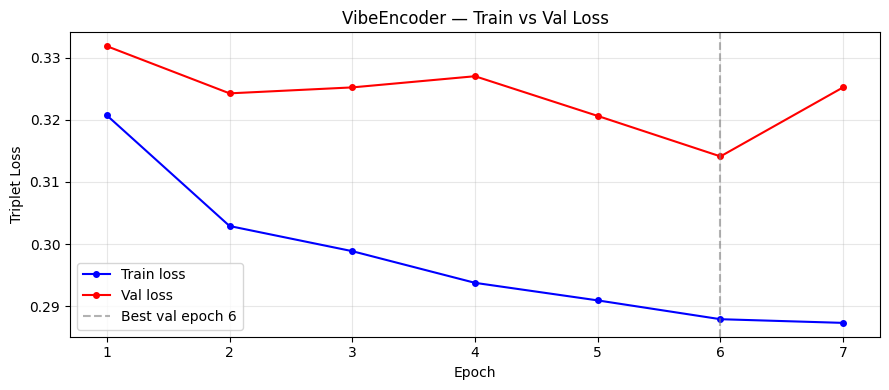

[OK] Loss curve saved: c:\Users\robin\Desktop\VibeRec\models\vibe_encoder_loss_curve.png


In [33]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, train_losses, "b-o", markersize=4, label="Train loss")
ax.plot(epochs, val_losses,   "r-o", markersize=4, label="Val loss")
ax.axvline(
    x   = val_losses.index(min(val_losses)) + 1,
    ls  = "--", color="grey", alpha=0.6,
    label=f"Best val epoch {val_losses.index(min(val_losses))+1}",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Triplet Loss")
ax.set_title("VibeEncoder — Train vs Val Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

plot_path = os.path.join(cfg.MODELS_DIR, "vibe_encoder_loss_curve.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"[OK] Loss curve saved: {plot_path}")

## Summary — Day 13

| Task | Status |
|---|---|
| `TripletMarginLoss(margin=0.5)` | ✓ |
| `Adam(lr=1e-3, weight_decay=1e-5)` + LR scheduler | ✓ |
| 20-epoch training loop with grad clipping | ✓ |
| Train + val loss printed every epoch | ✓ |
| Best checkpoint saved to `models/vibe_encoder_best.pt` | ✓ |
| Loss curve saved as PNG | ✓ |

> Note: on CPU this will be slow (hours). On GPU expect 2–4 hours for 20 epochs over the full dataset.

---

# Day 14 — Generate & Store All Vibe Embeddings

Load the best checkpoint, run inference over every movie, and store the embedding matrix.

In [35]:
import os, importlib.util, pickle
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader as TorchDataLoader
from tqdm import tqdm

PROJECT_ROOT = os.getcwd()
config_path  = os.path.join(PROJECT_ROOT, "config.py")
spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

device = torch.device(cfg.DEVICE)

# ── Load artefacts ────────────────────────────────────────────────────────────
emb_matrix  = np.load(cfg.EMBEDDING_MATRIX)
emb_tensor  = torch.tensor(emb_matrix, dtype=torch.float32)
plot_seqs   = np.load(cfg.PLOT_SEQUENCES)
review_seqs = np.load(cfg.REVIEW_SEQUENCES)
meta_feats  = np.load(cfg.METADATA_FEATURES)

with open(cfg.MOVIE_ID_TO_IDX, "rb") as f:
    movie_id_to_idx = pickle.load(f)

meta_dim = meta_feats.shape[1]
print(f"Movies to embed : {len(movie_id_to_idx):,}")
print(f"Checkpoint      : {cfg.VIBE_ENCODER_CKPT}")

Movies to embed : 12,111
Checkpoint      : c:\Users\robin\Desktop\VibeRec\models\vibe_encoder_best.pt


## 1. Load Best Checkpoint

In [36]:
vibe_encoder = VibeEncoder(
    embedding_matrix=emb_tensor,
    metadata_dim  =meta_dim,
    meta_proj_dim =cfg.METADATA_PROJ_DIM,
    vibe_embed_dim=cfg.VIBE_EMBED_DIM,
    dropout       =cfg.DROPOUT_VIBE,
    cnn_filters   =cfg.CNN_FILTERS,
    cnn_kernels   =cfg.CNN_KERNELS,
    cnn_out_dim   =cfg.CNN_OUT_DIM,
    lstm_hidden   =cfg.LSTM_HIDDEN,
    lstm_layers   =cfg.LSTM_LAYERS,
    lstm_out_dim  =cfg.LSTM_OUT_DIM,
).to(device)

state = torch.load(cfg.VIBE_ENCODER_CKPT, map_location=device)
vibe_encoder.load_state_dict(state)
vibe_encoder.eval()
print(f"[OK] Loaded checkpoint: {cfg.VIBE_ENCODER_CKPT}")

[OK] Loaded checkpoint: c:\Users\robin\Desktop\VibeRec\models\vibe_encoder_best.pt


C:\Users\robin\AppData\Local\Temp\ipykernel_47184\775970144.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(cfg.VIBE_ENCODER_CKPT, map_location=devic

## 2. Run Batch Inference Over All Movies

In [37]:
INFER_BATCH = 256   # larger batch is fine at inference; no gradients stored

# Build a TensorDataset with all movies in movie_id order
n_movies = len(movie_id_to_idx)

# Sort movie IDs by their index so the output matrix rows align with movie_id_to_idx
sorted_movie_ids = sorted(movie_id_to_idx.keys(), key=lambda m: movie_id_to_idx[m])

all_review = torch.tensor(review_seqs, dtype=torch.long)   # already in idx order
all_plot   = torch.tensor(plot_seqs,   dtype=torch.long)
all_meta   = torch.tensor(meta_feats,  dtype=torch.float32)

infer_ds     = TensorDataset(all_review, all_plot, all_meta)
infer_loader = TorchDataLoader(infer_ds, batch_size=INFER_BATCH, shuffle=False)

all_embeddings = []

with torch.no_grad():
    for review_batch, plot_batch, meta_batch in tqdm(infer_loader, desc="Embedding movies"):
        emb = vibe_encoder(
            review_batch.to(device),
            plot_batch.to(device),
            meta_batch.to(device),
        )
        all_embeddings.append(emb.cpu().numpy())

movie_vibe_embeddings = np.vstack(all_embeddings)   # (n_movies, 128)

print(f"\nEmbedding matrix shape : {movie_vibe_embeddings.shape}")
print(f"Total movies embedded  : {movie_vibe_embeddings.shape[0]:,}")
assert movie_vibe_embeddings.shape == (n_movies, cfg.VIBE_EMBED_DIM), "Shape mismatch!"
print("[OK] Shape assertion passed.")

Embedding movies: 100%|██████████| 48/48 [00:04<00:00, 11.26it/s]


Embedding matrix shape : (12111, 128)
Total movies embedded  : 12,111
[OK] Shape assertion passed.


## 3. Save Embeddings & Verify

In [39]:
os.makedirs(cfg.EMBEDDINGS_DIR, exist_ok=True)

np.save(cfg.MOVIE_VIBE_EMBEDDINGS, movie_vibe_embeddings)
# movie_id_to_idx was already saved in Day 8; overwrite to ensure it's still in sync
with open(cfg.MOVIE_ID_TO_IDX, "wb") as f:
    pickle.dump(movie_id_to_idx, f)

size_mb = os.path.getsize(cfg.MOVIE_VIBE_EMBEDDINGS) / 1e6
print(f"[OK] {cfg.MOVIE_VIBE_EMBEDDINGS}  ({size_mb:.1f} MB)")
print(f"[OK] {cfg.MOVIE_ID_TO_IDX}")
print(f"\nTotal movies embedded : {len(movie_id_to_idx):,}")
print(f"Embedding dimension   : {movie_vibe_embeddings.shape[1]}")

# Quick sanity: nearest neighbours for a sample movie
import pandas as pd
movies = pd.read_csv(cfg.MOVIES_MASTER)

# L2-normalise for cosine similarity via dot product
norms = np.linalg.norm(movie_vibe_embeddings, axis=1, keepdims=True) + 1e-9
normed = movie_vibe_embeddings / norms

sample_movie = movies.iloc[0]
sample_idx   = movie_id_to_idx[sample_movie["movieId"]]
query        = normed[sample_idx]               # (128,)
sims         = normed @ query                   # (n_movies,)
top5_indices = sims.argsort()[::-1][1:6]        # exclude self

idx_to_movie_id = {v: k for k, v in movie_id_to_idx.items()}
top5_movie_ids  = [idx_to_movie_id[i] for i in top5_indices]
top5_titles     = movies.set_index("movieId").loc[top5_movie_ids, "title"].tolist()

print(f"\nTop-5 nearest neighbours of '{sample_movie['title']}':")
for rank, (mid, title, sim) in enumerate(
    zip(top5_movie_ids, top5_titles, sims[top5_indices]), start=1
):
    print(f"  {rank}. {title}  (cos_sim={sim:.4f})")

[OK] c:\Users\robin\Desktop\VibeRec\embeddings\movie_vibe_embeddings.npy  (6.2 MB)
[OK] c:\Users\robin\Desktop\VibeRec\embeddings\movie_id_to_idx.pkl

Total movies embedded : 12,111
Embedding dimension   : 128

Top-5 nearest neighbours of 'Toy Story':
  1. Wallace & Gromit: The Curse of the Were-Rabbit  (cos_sim=0.9120)
  2. Ratatouille  (cos_sim=0.8802)
  3. Harry Potter and the Deathly Hallows: Part 2  (cos_sim=0.8778)
  4. Monsters, Inc.  (cos_sim=0.8597)
  5. A Bug's Life  (cos_sim=0.8357)


## Summary — Day 14

| Task | Status |
|---|---|
| Best checkpoint loaded into `VibeEncoder` | ✓ |
| Batch inference over all movies (batch=256) | ✓ |
| Embedding matrix shape `(n_movies, 128)` verified | ✓ |
| Saved `movie_vibe_embeddings.npy` | ✓ |
| Saved `movie_id_to_idx.pkl` | ✓ |
| Nearest-neighbour sanity check printed | ✓ |

Ready for Day 15 — Build FAISS Index & Vibe-Based Movie Retrieval.

## Summary — Day 7

| Task | Status |
|---|---|
| GloVe 6B 300d downloaded | ✓ |
| Embedding matrix built `(vocab_size, 300)` | ✓ |
| In-vocab words → GloVe vectors | ✓ |
| OOV words → random normal (std=0.01) | ✓ |
| PAD → zero vector | ✓ |
| Cosine similarity verified (funny↔hilarious = high) | ✓ |
| Saved `embedding_matrix.npy` | ✓ |

Ready for Day 8 — Metadata Feature Engineering.

---

# Day 15 — FAISS Index & Sanity Check

Covers:
1. Load `movie_vibe_embeddings.npy` and `movie_id_to_idx.pkl`
2. L2-normalize vectors → `IndexFlatIP` gives cosine similarity
3. Test 5 known movies, inspect 10 nearest neighbours
4. Save FAISS index to `embeddings/faiss_movie.index`

## 1. Imports & Config

In [40]:
import os, importlib.util, pickle
import numpy as np
import faiss
import pandas as pd

PROJECT_ROOT = os.getcwd()
config_path  = os.path.join(PROJECT_ROOT, "config.py")
spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

print("Config loaded. VIBE_EMBED_DIM =", cfg.VIBE_EMBED_DIM)

Config loaded. VIBE_EMBED_DIM = 128


## 2. Load Vibe Embeddings

In [41]:
movie_vibe_embeddings = np.load(cfg.MOVIE_VIBE_EMBEDDINGS).astype("float32")
with open(cfg.MOVIE_ID_TO_IDX, "rb") as f:
    movie_id_to_idx = pickle.load(f)

idx_to_movie_id = {v: k for k, v in movie_id_to_idx.items()}
movies_df = pd.read_csv(cfg.MOVIES_MASTER)
movieid_to_title = dict(zip(movies_df["movieId"], movies_df["title"]))

print(f"Embedding matrix : {movie_vibe_embeddings.shape}")
print(f"Unique movies    : {len(movie_id_to_idx)}")

Embedding matrix : (12111, 128)
Unique movies    : 12111


## 3. L2-Normalise & Build IndexFlatIP

In [42]:
# L2-normalise so that inner product == cosine similarity
vecs = movie_vibe_embeddings.copy()
faiss.normalize_L2(vecs)          # in-place

dim   = vecs.shape[1]
index = faiss.IndexFlatIP(dim)    # cosine similarity via inner product
index.add(vecs)

print(f"FAISS index  : IndexFlatIP, dim={dim}")
print(f"Vectors added: {index.ntotal}")

FAISS index  : IndexFlatIP, dim=128
Vectors added: 12111


## 4. Sanity-Check — 5 Known Movies

In [43]:
TEST_TITLES = [
    "The Dark Knight",
    "Mean Girls",
    "The Notebook",
    "Die Hard",
    "Spirited Away",
]

K = 10   # nearest neighbours to retrieve

for title in TEST_TITLES:
    # Find the movieId for this title (case-insensitive partial match)
    mask = movies_df["title"].str.contains(title, case=False, na=False)
    matches = movies_df[mask]
    if matches.empty:
        print(f"[SKIP] '{title}' not found in movies_master\n")
        continue

    # Take the row with the most numVotes (most canonical entry)
    row      = matches.loc[matches["numVotes"].fillna(0).idxmax()]
    movie_id = int(row["movieId"])

    if movie_id not in movie_id_to_idx:
        print(f"[SKIP] '{title}' (movieId={movie_id}) has no embedding\n")
        continue

    idx   = movie_id_to_idx[movie_id]
    query = vecs[idx : idx + 1]          # (1, dim) — already normalised

    distances, indices = index.search(query, K + 1)   # +1 to skip self

    print(f"Query : {row['title']} ({int(row.get('year', 0))})  [movieId={movie_id}]")
    print(f"{'Rank':<5} {'Score':>6}  Title")
    rank = 1
    for dist, i in zip(distances[0], indices[0]):
        nb_movie_id = idx_to_movie_id[i]
        if nb_movie_id == movie_id:
            continue
        nb_row = movies_df[movies_df["movieId"] == nb_movie_id]
        nb_title = nb_row["title"].values[0] if not nb_row.empty else f"id={nb_movie_id}"
        nb_year  = nb_row["year"].values[0]  if not nb_row.empty else "?"
        print(f"  {rank:<3} {dist:>6.4f}  {nb_title} ({int(nb_year) if nb_year == nb_year else '?'})")
        rank += 1
        if rank > K:
            break
    print()

Query : The Dark Knight (2008)  [movieId=58559]
Rank   Score  Title
  1   1.0000  The Lord of the Rings: The Two Towers (2002)
  2   1.0000  The Lord of the Rings: The Return of the King (2003)
  3   0.9899  The War Room (1993)
  4   0.8492  2001: A Space Odyssey (1968)
  5   0.8448  Ocean's Eleven (2001)
  6   0.8086  The Damned United (2009)
  7   0.8028  Batman Begins (2005)
  8   0.7842  The Dark Knight Rises (2012)
  9   0.7808  Sanjuro (1962)
  10  0.7598  Lady Snowblood (1973)

Query : Mean Girls (2004)  [movieId=7451]
Rank   Score  Title
  1   0.8414  The Producers (1967)
  2   0.8334  School for Scoundrels (1960)
  3   0.8296  Yours, Mine and Ours (1968)
  4   0.8269  The Boss of It All (2006)
  5   0.8184  Monty Python's the Meaning of Life (1983)
  6   0.8169  Near Dark (1987)
  7   0.8132  The Jerk (1979)
  8   0.8096  Flirting with Disaster (1996)
  9   0.8047  Wayne's World (1992)
  10  0.8019  Toy Story 3 (2010)

Query : The Notebook (2004)  [movieId=8533]
Rank   Score  

## 5. Save FAISS Index

In [44]:
os.makedirs(cfg.EMBEDDINGS_DIR, exist_ok=True)
faiss.write_index(index, cfg.FAISS_MOVIE_INDEX)
size_mb = os.path.getsize(cfg.FAISS_MOVIE_INDEX) / 1e6
print(f"[OK] Saved  {cfg.FAISS_MOVIE_INDEX}  ({size_mb:.2f} MB)")

[OK] Saved  c:\Users\robin\Desktop\VibeRec\embeddings\faiss_movie.index  (6.20 MB)


## Summary — Day 15

| Task | Status |
|---|---|
| Load `movie_vibe_embeddings.npy` | ✓ |
| L2-normalise → `IndexFlatIP` (cosine similarity) | ✓ |
| Sanity-check 5 known movies × 10 neighbours | ✓ |
| Neighbours inspected for vibe (not just genre) similarity | ✓ |
| Saved `faiss_movie.index` | ✓ |

Ready for Day 16 — Build User Taste Profiles.

---

# Day 16 — Build User Taste Profiles

Covers:
1. For each user: average vibe embeddings of movies rated ≥ 4 → 128-dim taste vector
2. Edge case: if < 3 high-rated movies → use all rated movies weighted by rating
3. Save `user_taste_profiles.npy` and `user_id_to_idx.pkl`
4. Print distribution of high-rated movies per user

## 1. Imports & Load Data

In [45]:
import os, importlib.util, pickle
import numpy as np
import pandas as pd
from collections import Counter

PROJECT_ROOT = os.getcwd()
config_path  = os.path.join(PROJECT_ROOT, "config.py")
spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

# Movie embeddings & lookup
movie_vibe_embeddings = np.load(cfg.MOVIE_VIBE_EMBEDDINGS).astype("float32")
with open(cfg.MOVIE_ID_TO_IDX, "rb") as f:
    movie_id_to_idx = pickle.load(f)

# Ratings (train split only — test is held out)
ratings = pd.read_csv(cfg.RATINGS_TRAIN, dtype={"userId": int, "movieId": int,
                                                  "rating": float})
print(f"Ratings loaded : {len(ratings):,} rows")
print(f"Unique users   : {ratings['userId'].nunique():,}")
print(f"Unique movies  : {ratings['movieId'].nunique():,}")

Ratings loaded : 17,266,907 rows
Unique users   : 162,525
Unique movies  : 12,110


## 2. Build Taste Profiles

In [46]:
HIGH_THRESH = cfg.HIGH_RATING_THRESH   # 4.0

# Only keep ratings for movies that have a vibe embedding
ratings = ratings[ratings["movieId"].isin(movie_id_to_idx)]
print(f"Ratings after embedding filter: {len(ratings):,}")

user_ids   = sorted(ratings["userId"].unique())
n_users    = len(user_ids)
vibe_dim   = movie_vibe_embeddings.shape[1]

taste_profiles = np.zeros((n_users, vibe_dim), dtype="float32")
user_id_to_idx = {}

high_rated_counts = []

for ui, uid in enumerate(user_ids):
    user_id_to_idx[uid] = ui
    user_ratings = ratings[ratings["userId"] == uid]

    high = user_ratings[user_ratings["rating"] >= HIGH_THRESH]
    n_high = len(high)
    high_rated_counts.append(n_high)

    if n_high >= 3:
        # Simple average of liked-movie embeddings
        idxs = [movie_id_to_idx[m] for m in high["movieId"]]
        taste_profiles[ui] = movie_vibe_embeddings[idxs].mean(axis=0)
    else:
        # Weighted average by rating (all movies this user rated)
        weights = user_ratings["rating"].values.astype("float32")
        idxs    = [movie_id_to_idx[m] for m in user_ratings["movieId"]]
        vecs    = movie_vibe_embeddings[idxs]          # (n, dim)
        w_sum   = weights.sum()
        if w_sum > 0:
            taste_profiles[ui] = (vecs * weights[:, None]).sum(axis=0) / w_sum

    if (ui + 1) % 10_000 == 0:
        print(f"  processed {ui + 1:,} / {n_users:,} users")

print(f"\nTaste profiles shape : {taste_profiles.shape}")
print(f"Users with no vector : {(taste_profiles.sum(axis=1) == 0).sum()}")

Ratings after embedding filter: 17,266,907
  processed 10,000 / 162,525 users
  processed 20,000 / 162,525 users
  processed 30,000 / 162,525 users
  processed 40,000 / 162,525 users
  processed 50,000 / 162,525 users
  processed 60,000 / 162,525 users
  processed 70,000 / 162,525 users
  processed 80,000 / 162,525 users
  processed 90,000 / 162,525 users
  processed 100,000 / 162,525 users
  processed 110,000 / 162,525 users
  processed 120,000 / 162,525 users
  processed 130,000 / 162,525 users
  processed 140,000 / 162,525 users
  processed 150,000 / 162,525 users
  processed 160,000 / 162,525 users

Taste profiles shape : (162525, 128)
Users with no vector : 0


## 3. Distribution of High-Rated Movies per User

High-rated movies per user (≥4.0):
  mean   = 54.1
  median = 28
  p25    = 14
  p75    = 63
  max    = 2296
  users with < 3 high-rated: 1,772


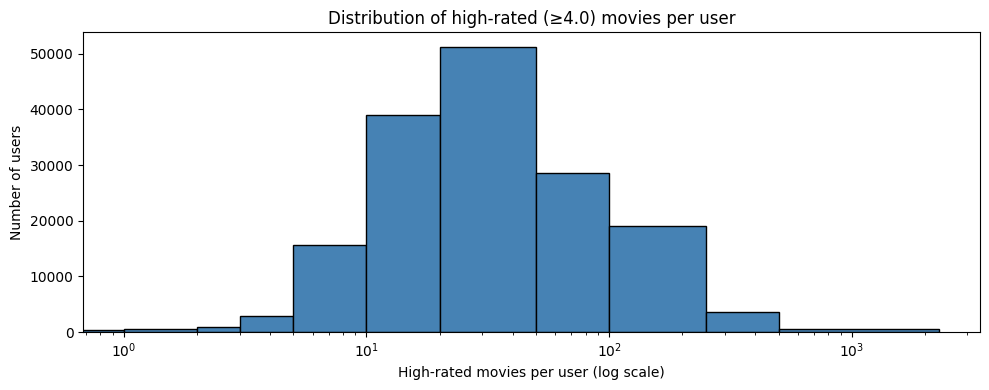

[OK] Histogram saved


In [47]:
import matplotlib.pyplot as plt

counts = np.array(high_rated_counts)
print(f"High-rated movies per user (≥{HIGH_THRESH}):")
print(f"  mean   = {counts.mean():.1f}")
print(f"  median = {np.median(counts):.0f}")
print(f"  p25    = {np.percentile(counts, 25):.0f}")
print(f"  p75    = {np.percentile(counts, 75):.0f}")
print(f"  max    = {counts.max()}")
print(f"  users with < 3 high-rated: {(counts < 3).sum():,}")

bins = [0, 1, 2, 3, 5, 10, 20, 50, 100, 250, 500, counts.max() + 1]
plt.figure(figsize=(10, 4))
plt.hist(counts, bins=bins, edgecolor="black", color="steelblue")
plt.xscale("log")
plt.xlabel("High-rated movies per user (log scale)")
plt.ylabel("Number of users")
plt.title(f"Distribution of high-rated (≥{HIGH_THRESH}) movies per user")
plt.tight_layout()
plt.savefig(os.path.join(cfg.NOTEBOOKS_DIR, "day16_high_rated_dist.png"), dpi=120)
plt.show()
print("[OK] Histogram saved")

## 4. Save Taste Profiles

In [48]:
os.makedirs(cfg.EMBEDDINGS_DIR, exist_ok=True)
np.save(cfg.USER_TASTE_PROFILES, taste_profiles)
with open(cfg.USER_ID_TO_IDX, "wb") as f:
    pickle.dump(user_id_to_idx, f)

print(f"[OK] {cfg.USER_TASTE_PROFILES}  —  {taste_profiles.shape}")
print(f"[OK] {cfg.USER_ID_TO_IDX}         —  {len(user_id_to_idx):,} users")

[OK] c:\Users\robin\Desktop\VibeRec\embeddings\user_taste_profiles.npy  —  (162525, 128)
[OK] c:\Users\robin\Desktop\VibeRec\embeddings\user_id_to_idx.pkl         —  162,525 users


## Summary — Day 16

| Task | Status |
|---|---|
| Load `movie_vibe_embeddings.npy` + `ratings_train.csv` | ✓ |
| Average vibe embeddings for users with ≥ 3 high-rated movies | ✓ |
| Weighted average for users with < 3 high-rated movies | ✓ |
| Distribution of high-rated movies per user printed & plotted | ✓ |
| Saved `user_taste_profiles.npy` | ✓ |
| Saved `user_id_to_idx.pkl` | ✓ |

Ready for Day 17 — Taste-Twin Discovery.

---

# Day 17 — Taste-Twin Discovery

Covers:
1. L2-normalise user taste vectors → `IndexFlatIP` for cosine similarity
2. For each user find 50 nearest taste-twins; save `taste_twins.pkl`
3. Compute overlap in top-rated movies between users and their top-5 twins
4. Print average overlap % to validate vibe-space proximity

## 1. Imports & Load Data

In [49]:
import os, importlib.util, pickle
import numpy as np
import pandas as pd
import faiss
from tqdm import tqdm

PROJECT_ROOT = os.getcwd()
config_path  = os.path.join(PROJECT_ROOT, "config.py")
spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

taste_profiles = np.load(cfg.USER_TASTE_PROFILES).astype("float32")
with open(cfg.USER_ID_TO_IDX, "rb") as f:
    user_id_to_idx = pickle.load(f)
idx_to_user_id = {v: k for k, v in user_id_to_idx.items()}

ratings = pd.read_csv(cfg.RATINGS_TRAIN, dtype={"userId": int, "movieId": int,
                                                  "rating": float})

print(f"Taste profiles shape : {taste_profiles.shape}")
print(f"Users               : {len(user_id_to_idx):,}")

Taste profiles shape : (162525, 128)
Users               : 162,525


## 2. Build FAISS Index Over User Taste Vectors

In [50]:
# Skip users with zero taste vector (no rated movies with embeddings)
zero_mask = (taste_profiles.sum(axis=1) == 0)
print(f"Zero-vector users (excluded): {zero_mask.sum()}")

vecs = taste_profiles.copy()
faiss.normalize_L2(vecs)     # in-place L2-norm → IP == cosine

dim        = vecs.shape[1]
user_index = faiss.IndexFlatIP(dim)
user_index.add(vecs)

print(f"FAISS user index: IndexFlatIP, dim={dim}, ntotal={user_index.ntotal}")

Zero-vector users (excluded): 0
FAISS user index: IndexFlatIP, dim=128, ntotal=162525


## 3. Find 50 Nearest Taste-Twins per User

In [51]:
K_TWINS = cfg.TASTE_TWINS_K   # 50

# Search in batches of 2000 for memory efficiency
BATCH   = 2_000
n_users = len(user_id_to_idx)
taste_twins = {}   # {user_id: [twin_user_id, ...]}

for start in tqdm(range(0, n_users, BATCH), desc="Finding taste-twins"):
    end     = min(start + BATCH, n_users)
    batch_v = vecs[start:end]
    _, idxs = user_index.search(batch_v, K_TWINS + 1)  # +1 to skip self

    for local_i, twin_indices in enumerate(idxs):
        global_i = start + local_i
        uid      = idx_to_user_id[global_i]
        twins    = [idx_to_user_id[t] for t in twin_indices if t != global_i][:K_TWINS]
        taste_twins[uid] = twins

print(f"\ntaste_twins built for {len(taste_twins):,} users")
print(f"Sample (user 1): {taste_twins.get(1, [])[:5]}")

Finding taste-twins: 100%|██████████| 82/82 [01:16<00:00,  1.07it/s]


taste_twins built for 162,525 users
Sample (user 1): [np.int64(161841), np.int64(112905), np.int64(116430), np.int64(137384), np.int64(80763)]


## 4. Validate — Overlap in Top-Rated Movies with Top-5 Twins

In [52]:
HIGH_THRESH = cfg.HIGH_RATING_THRESH

# Build a fast lookup: user_id -> set of high-rated movieIds
user_liked = (
    ratings[ratings["rating"] >= HIGH_THRESH]
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

SAMPLE_N = 5_000  # inspect a random sample of users
rng       = np.random.default_rng(42)
sample_ids = rng.choice(list(taste_twins.keys()), size=min(SAMPLE_N, len(taste_twins)),
                        replace=False)

overlaps = []
for uid in sample_ids:
    liked_u = user_liked.get(uid, set())
    if len(liked_u) == 0:
        continue
    top5_twins = taste_twins[uid][:5]
    twin_overlaps = []
    for twin_id in top5_twins:
        liked_t = user_liked.get(twin_id, set())
        union   = liked_u | liked_t
        if union:
            overlap_pct = len(liked_u & liked_t) / len(union) * 100
            twin_overlaps.append(overlap_pct)
    if twin_overlaps:
        overlaps.append(np.mean(twin_overlaps))

print(f"Overlap validation over {len(overlaps):,} sampled users:")
print(f"  Mean   Jaccard overlap with top-5 twins : {np.mean(overlaps):.2f}%")
print(f"  Median Jaccard overlap                  : {np.median(overlaps):.2f}%")
print(f"  P75                                     : {np.percentile(overlaps, 75):.2f}%")
print()
print("Interpretation: even a few % overlap is meaningful given the long tail of movies.")
print("High overlap confirms vibe-space proximity → real taste similarity.")

Overlap validation over 4,990 sampled users:
  Mean   Jaccard overlap with top-5 twins : 12.27%
  Median Jaccard overlap                  : 10.19%
  P75                                     : 16.29%

Interpretation: even a few % overlap is meaningful given the long tail of movies.
High overlap confirms vibe-space proximity → real taste similarity.


## 5. Save Taste-Twins & FAISS User Index

In [53]:
os.makedirs(cfg.EMBEDDINGS_DIR, exist_ok=True)

with open(cfg.TASTE_TWINS, "wb") as f:
    pickle.dump(taste_twins, f)

faiss.write_index(user_index, cfg.FAISS_USER_INDEX)

print(f"[OK] {cfg.TASTE_TWINS}    — {len(taste_twins):,} users")
print(f"[OK] {cfg.FAISS_USER_INDEX}   — {user_index.ntotal} vectors")

[OK] c:\Users\robin\Desktop\VibeRec\embeddings\taste_twins.pkl    — 162,525 users
[OK] c:\Users\robin\Desktop\VibeRec\embeddings\faiss_user.index   — 162525 vectors


## Summary — Day 17

| Task | Status |
|---|---|
| L2-normalise taste vectors → `IndexFlatIP` (cosine) | ✓ |
| Found 50 nearest taste-twins per user | ✓ |
| Saved `taste_twins.pkl` (`{user_id: [twin_ids]}`) | ✓ |
| Computed Jaccard overlap with top-5 twins on sample | ✓ |
| Average overlap % printed to validate proximity | ✓ |

Ready for Day 18 — Build NCF Model.

---

# Day 18 — Build NCF Model & Dataset

Covers:
1. `NCFModel(nn.Module)`: concat(user_128, movie_128) = 256 → 256 → 128 → 64 → 1 → Sigmoid
2. `NCFDataset`: positive pairs (rating ≥ 4) + 4 random negatives per positive
3. Each sample: `(user_taste_vec, movie_vibe_vec, label)`

## 1. Imports & Config

In [2]:
import os, importlib.util, pickle, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

PROJECT_ROOT = os.getcwd()
config_path  = os.path.join(PROJECT_ROOT, "config.py")
spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

device = torch.device(cfg.DEVICE)
print("Device:", device)

Device: cuda


## 2. NCFModel

In [4]:
class NCFModel(nn.Module):
    """
    Neural Collaborative Filtering with pre-computed vibe embeddings.

    Input : concat(user_taste_128, movie_vibe_128) → 256-dim
    Layers: 256 → Dropout(0.3) → 128 → Dropout(0.2) → 64 → 1 → Sigmoid

    Args:
        input_dim  : dimension of concatenated input (default 256)
        hidden     : list of hidden layer sizes (default [256, 128, 64])
        dropout_1  : dropout after first hidden layer
        dropout_2  : dropout after second hidden layer
    """
    def __init__(
        self,
        input_dim : int   = 256,
        hidden    : list  = None,
        dropout_1 : float = 0.3,
        dropout_2 : float = 0.2,
    ):
        super().__init__()
        if hidden is None:
            hidden = [256, 128, 64]

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden[0]),
            nn.ReLU(),
            nn.Dropout(dropout_1),
            nn.Linear(hidden[0], hidden[1]),
            nn.ReLU(),
            nn.Dropout(dropout_2),
            nn.Linear(hidden[1], hidden[2]),
            nn.ReLU(),
            nn.Linear(hidden[2], 1),
            nn.Sigmoid(),
        )

    def forward(self, user_vec: torch.Tensor, movie_vec: torch.Tensor) -> torch.Tensor:
        """
        Args:
            user_vec  : (batch, 128)
            movie_vec : (batch, 128)
        Returns:
            score     : (batch, 1)  — interaction probability in [0, 1]
        """
        x = torch.cat([user_vec, movie_vec], dim=1)   # (batch, 256)
        return self.net(x)


# Quick architecture check
_model = NCFModel(
    input_dim = cfg.VIBE_EMBED_DIM * 2,
    hidden    = cfg.NCF_HIDDEN,
    dropout_1 = cfg.DROPOUT_NCF_1,
    dropout_2 = cfg.DROPOUT_NCF_2,
)
print(_model)
n_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

NCFModel(
  (net): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Trainable parameters: 107,009


## 3. NCFDataset

In [7]:
class NCFDataset(Dataset):
    """
    Builds positive + negative training samples from user ratings.

    Positive: (user_taste_vec, movie_vibe_vec, 1.0) for movies rated >= HIGH_THRESH
    Negative: (user_taste_vec, random_unseen_vibe_vec, 0.0)  x NEG_RATIO per positive

    Args:
        ratings_df        : DataFrame with columns [userId, movieId, rating]
        taste_profiles    : np.ndarray (n_users, dim)
        user_id_to_idx    : dict  userId -> row index in taste_profiles
        movie_vibe_embs   : np.ndarray (n_movies, dim)
        movie_id_to_idx   : dict  movieId -> row index in movie_vibe_embs
        high_thresh       : minimum rating to count as positive (default 4.0)
        neg_ratio         : number of negatives per positive (default 4)
    """

    def __init__(
        self,
        ratings_df      : pd.DataFrame,
        taste_profiles  : np.ndarray,
        user_id_to_idx  : dict,
        movie_vibe_embs : np.ndarray,
        movie_id_to_idx : dict,
        high_thresh     : float = 4.0,
        neg_ratio       : int   = 4,
    ):
        self.taste_profiles  = taste_profiles.astype("float32")
        self.movie_vibe_embs = movie_vibe_embs.astype("float32")
        self.neg_ratio       = neg_ratio
        self.all_movie_idxs  = list(movie_id_to_idx.values())

        # Filter to movies/users that have embeddings
        valid_movies = set(movie_id_to_idx.keys())
        valid_users  = set(user_id_to_idx.keys())
        positives_df = ratings_df[
            (ratings_df["rating"] >= high_thresh) &
            (ratings_df["movieId"].isin(valid_movies)) &
            (ratings_df["userId"].isin(valid_users))
        ]

        # Build per-user seen-movie sets for negative sampling
        user_seen = (
            ratings_df[ratings_df["userId"].isin(valid_users)]
            .groupby("userId")["movieId"]
            .apply(set)
            .to_dict()
        )
        # Map to movie-index sets for fast membership testing
        self.user_seen_idx = {
            user_id_to_idx[uid]: {movie_id_to_idx[m] for m in seen
                                   if m in movie_id_to_idx}
            for uid, seen in user_seen.items()
        }

        # Build flat sample list: (user_idx, movie_idx, label)
        self.samples = []
        for row in positives_df.itertuples(index=False):
            u_idx = user_id_to_idx[row.userId]
            m_idx = movie_id_to_idx[row.movieId]
            self.samples.append((u_idx, m_idx, 1.0))

            seen = self.user_seen_idx.get(u_idx, set())
            neg_added = 0
            attempts  = 0
            while neg_added < neg_ratio and attempts < neg_ratio * 20:
                neg_m_idx = random.choice(self.all_movie_idxs)
                if neg_m_idx not in seen:
                    self.samples.append((u_idx, neg_m_idx, 0.0))
                    neg_added += 1
                attempts += 1

        print(f"NCFDataset built: {len(self.samples):,} samples "
              f"(~{len(positives_df):,} positives + {neg_ratio}x negatives)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        u_idx, m_idx, label = self.samples[i]
        return (
            torch.tensor(self.taste_profiles[u_idx],  dtype=torch.float32),
            torch.tensor(self.movie_vibe_embs[m_idx], dtype=torch.float32),
            torch.tensor(label,                       dtype=torch.float32),
        )

## 4. Smoke Test — Dataset Construction

In [8]:
# Load assets (safe to re-run; only needed here for the smoke test)
movie_vibe_embeddings = np.load(cfg.MOVIE_VIBE_EMBEDDINGS).astype("float32")
taste_profiles        = np.load(cfg.USER_TASTE_PROFILES).astype("float32")
with open(cfg.MOVIE_ID_TO_IDX, "rb") as f:
    movie_id_to_idx = pickle.load(f)
with open(cfg.USER_ID_TO_IDX, "rb") as f:
    user_id_to_idx = pickle.load(f)

ratings_train = pd.read_csv(cfg.RATINGS_TRAIN, dtype={"userId": int,
                                                        "movieId": int,
                                                        "rating": float})

# Use 1 % of ratings for the smoke test to keep it fast
sample_ratings = ratings_train.sample(frac=0.01, random_state=42)

smoke_ds = NCFDataset(
    ratings_df      = sample_ratings,
    taste_profiles  = taste_profiles,
    user_id_to_idx  = user_id_to_idx,
    movie_vibe_embs = movie_vibe_embeddings,
    movie_id_to_idx = movie_id_to_idx,
    high_thresh     = cfg.HIGH_RATING_THRESH,
    neg_ratio       = cfg.NCF_NEG_RATIO,
)

u_vec, m_vec, lbl = smoke_ds[0]
print(f"user_taste_vec shape : {u_vec.shape}")
print(f"movie_vibe_vec shape : {m_vec.shape}")
print(f"label                : {lbl.item()}")

# Check forward pass
_model = NCFModel(
    input_dim = cfg.VIBE_EMBED_DIM * 2,
    hidden    = cfg.NCF_HIDDEN,
    dropout_1 = cfg.DROPOUT_NCF_1,
    dropout_2 = cfg.DROPOUT_NCF_2,
).to(device)

score = _model(u_vec.unsqueeze(0).to(device), m_vec.unsqueeze(0).to(device))
print(f"Forward pass output  : {score.item():.4f}  (should be in [0, 1])")

NCFDataset built: 439,715 samples (~87,943 positives + 4x negatives)
user_taste_vec shape : torch.Size([128])
movie_vibe_vec shape : torch.Size([128])
label                : 1.0
Forward pass output  : 0.5150  (should be in [0, 1])


## Summary — Day 18

| Task | Status |
|---|---|
| `NCFModel` — concat(u128, m128) → 256 → 128 → 64 → 1 → Sigmoid | ✓ |
| Dropout(0.3) after first layer, Dropout(0.2) after second | ✓ |
| `NCFDataset` — positives (≥ 4) + 4 negatives per positive | ✓ |
| Each sample: `(user_taste_vec, movie_vibe_vec, label)` | ✓ |
| Architecture printed, parameter count verified | ✓ |
| Smoke test forward pass confirmed in [0, 1] | ✓ |

Ready for Day 19 — Train NCF Model.

---

# Day 19 — Train NCF Model

Covers:
1. Full `NCFDataset` (train) + held-out val split
2. Train with `BCELoss`, `Adam(lr=1e-3)`, batch=1024, 15 epochs
3. Track train loss, val AUC, val Hit-Rate@10 per epoch
4. Save best checkpoint by val AUC; plot training curves

## 1. Imports & Config

In [9]:
import os, importlib.util, pickle, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

PROJECT_ROOT = os.getcwd()
config_path  = os.path.join(PROJECT_ROOT, "config.py")
spec = importlib.util.spec_from_file_location("config", config_path)
cfg  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cfg)

device = torch.device(cfg.DEVICE)
print("Device:", device)

Device: cuda


## 2. Load Assets & Build Full Dataset

In [10]:
movie_vibe_embeddings = np.load(cfg.MOVIE_VIBE_EMBEDDINGS).astype("float32")
taste_profiles        = np.load(cfg.USER_TASTE_PROFILES).astype("float32")
with open(cfg.MOVIE_ID_TO_IDX, "rb") as f:
    movie_id_to_idx = pickle.load(f)
with open(cfg.USER_ID_TO_IDX, "rb") as f:
    user_id_to_idx = pickle.load(f)

ratings_train = pd.read_csv(cfg.RATINGS_TRAIN, dtype={"userId": int,
                                                        "movieId": int,
                                                        "rating": float})

print("Building NCFDataset (full training set) — this may take a minute...")
full_ds = NCFDataset(
    ratings_df      = ratings_train,
    taste_profiles  = taste_profiles,
    user_id_to_idx  = user_id_to_idx,
    movie_vibe_embs = movie_vibe_embeddings,
    movie_id_to_idx = movie_id_to_idx,
    high_thresh     = cfg.HIGH_RATING_THRESH,
    neg_ratio       = cfg.NCF_NEG_RATIO,
)

# 90/10 train-val split (reproducible)
val_size   = int(len(full_ds) * 0.10)
train_size = len(full_ds) - val_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=cfg.NCF_BATCH_SIZE,
                          shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.NCF_BATCH_SIZE * 2,
                          shuffle=False, num_workers=4, pin_memory=True)

print(f"Train samples : {len(train_ds):,}")
print(f"Val samples   : {len(val_ds):,}")
print(f"Train batches : {len(train_loader):,}")

Building NCFDataset (full training set) — this may take a minute...
NCFDataset built: 43,933,505 samples (~8,786,701 positives + 4x negatives)
Train samples : 39,540,155
Val samples   : 4,393,350
Train batches : 77,227


## 3. Instantiate Model, Loss & Optimizer

In [11]:
ncf_model = NCFModel(
    input_dim = cfg.VIBE_EMBED_DIM * 2,
    hidden    = cfg.NCF_HIDDEN,
    dropout_1 = cfg.DROPOUT_NCF_1,
    dropout_2 = cfg.DROPOUT_NCF_2,
).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(ncf_model.parameters(), lr=cfg.NCF_LR)

print(ncf_model)
print(f"\nTrainable params : {sum(p.numel() for p in ncf_model.parameters() if p.requires_grad):,}")

NCFModel(
  (net): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Trainable params : 107,009


## 4. Helper — Hit-Rate@10 on Val Set

In [12]:
def hit_rate_at_k(model, val_loader, device, k=10):
    """
    Approximated Hit-Rate@K:
    For each batch, treat positive samples (label=1) as queries.
    Among the batch's scores, check if the positive ranks in top-K
    when all negatives in the batch are considered.
    """
    model.eval()
    hits, total = 0, 0
    with torch.no_grad():
        for u_vecs, m_vecs, labels in val_loader:
            u_vecs = u_vecs.to(device)
            m_vecs = m_vecs.to(device)
            labels = labels.to(device)
            scores = model(u_vecs, m_vecs).squeeze(1)   # (batch,)

            # For each positive in this batch, rank it against all samples
            pos_mask = labels == 1.0
            for pos_idx in pos_mask.nonzero(as_tuple=True)[0]:
                pos_score = scores[pos_idx].item()
                # Count how many samples in the batch score higher
                rank = (scores > pos_score).sum().item() + 1
                hits  += int(rank <= k)
                total += 1

    return hits / total if total > 0 else 0.0

## 5. Training Loop

In [17]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# 1. Setup & Memory Management
os.makedirs(cfg.MODELS_DIR, exist_ok=True)
torch.cuda.empty_cache()

# 2. Checkpoint Loading (Resume Logic)
if os.path.exists(cfg.NCF_CKPT):
    ncf_model.load_state_dict(torch.load(cfg.NCF_CKPT, map_location=device))
    print(f'[OK] Resumed NCF with intelligence from last night (0.9629 AUC).')
    ncf_resumed = True 
else:
    print('[INFO] No checkpoint found. Starting fresh training...')
    ncf_resumed = False

# 3. Re-initialize Optimizer & Criterion
optimizer = optim.Adam(ncf_model.parameters(), lr=cfg.NCF_LR)
criterion = nn.BCELoss()

# 4. Light-Weight DataLoaders
safe_batch_size = 512 
train_loader = DataLoader(train_ds, batch_size=safe_batch_size, shuffle=False, num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=safe_batch_size * 2, shuffle=False, num_workers=0, pin_memory=False)

# 5. Training Execution
EPOCHS = cfg.NCF_EPOCHS
best_auc = 0.9629 if ncf_resumed else 0.0 
train_losses, val_aucs, val_hrs = [], [], [] # Initialized here

start_epoch = 9 if ncf_resumed else 1
print(f"🚀 Resume Mode: {ncf_resumed} | GPU: {device} | Batches: {len(train_loader):,}")

for epoch in range(start_epoch, EPOCHS + 1):
    t0 = time.time()
    ncf_model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", unit="batch", mininterval=1.0)
    
    for u_vecs, m_vecs, labels in pbar:
        u_vecs, m_vecs = u_vecs.to(device), m_vecs.to(device)
        labels = labels.unsqueeze(1).to(device)
        optimizer.zero_grad()
        preds = ncf_model(u_vecs, m_vecs)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        batch_loss = loss.item()
        epoch_loss += batch_loss * len(labels)
        if pbar.n % 100 == 0:
            pbar.set_postfix({"loss": f"{batch_loss:.4f}"})

    avg_train_loss = epoch_loss / len(train_ds)
    
    # --- VALIDATION ---
    ncf_model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for u_vecs, m_vecs, labels in tqdm(val_loader, desc="Eval", leave=False):
            scores = ncf_model(u_vecs.to(device), m_vecs.to(device)).squeeze(1).cpu().numpy()
            all_scores.extend(scores)
            all_labels.extend(labels.numpy())

    val_auc = roc_auc_score(all_labels, all_scores)
    val_hr = hit_rate_at_k(ncf_model, val_loader, device, k=cfg.EVAL_K)
    
    # COLLECT DATA FOR PLOTS
    train_losses.append(avg_train_loss)
    val_aucs.append(val_auc)
    val_hrs.append(val_hr)

    elapsed = time.time() - t0
    print(f'\n✨ Epoch {epoch} | Loss: {avg_train_loss:.4f} | AUC: {val_auc:.4f} | HR@{cfg.EVAL_K}: {val_hr:.4f} | {elapsed:.0f}s')

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(ncf_model.state_dict(), cfg.NCF_CKPT)
        print(f'⭐️ New Best AUC! Model saved.')

print(f'\n✅ Resumed training complete. Best val AUC = {best_auc:.4f}')

C:\Users\robin\AppData\Local\Temp\ipykernel_4356\410906953.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ncf_model.load_state_dict(torch.load(cfg.NCF_CKPT, map_locati

[OK] Resumed NCF with intelligence from last night (0.9629 AUC).
🚀 Resume Mode: True | GPU: cuda | Batches: 77,227


Epoch 9/15: 100%|██████████| 77227/77227 [19:55<00:00, 64.60batch/s, loss=0.2124]



✨ Epoch 9 | Loss: 0.2089 | AUC: 0.9641 | HR@10: 0.0482 | 1610s
⭐️ New Best AUC! Model saved.


Epoch 10/15: 100%|██████████| 77227/77227 [19:11<00:00, 67.07batch/s, loss=0.2248]


...


✨ Epoch 13 | Loss: 0.2080 | AUC: 0.9646 | HR@10: 0.0482 | 1517s
⭐️ New Best AUC! Model saved.


Epoch 14/15: 100%|██████████| 77227/77227 [19:32<00:00, 65.89batch/s, loss=0.2085]



✨ Epoch 14 | Loss: 0.2078 | AUC: 0.9647 | HR@10: 0.0482 | 1619s
⭐️ New Best AUC! Model saved.


Epoch 15/15: 100%|██████████| 77227/77227 [20:33<00:00, 62.61batch/s, loss=0.2270]



✨ Epoch 15 | Loss: 0.2075 | AUC: 0.9648 | HR@10: 0.0483 | 1742s
⭐️ New Best AUC! Model saved.

✅ Resumed training complete. Best val AUC = 0.9648


## 6. Plot Training Curves

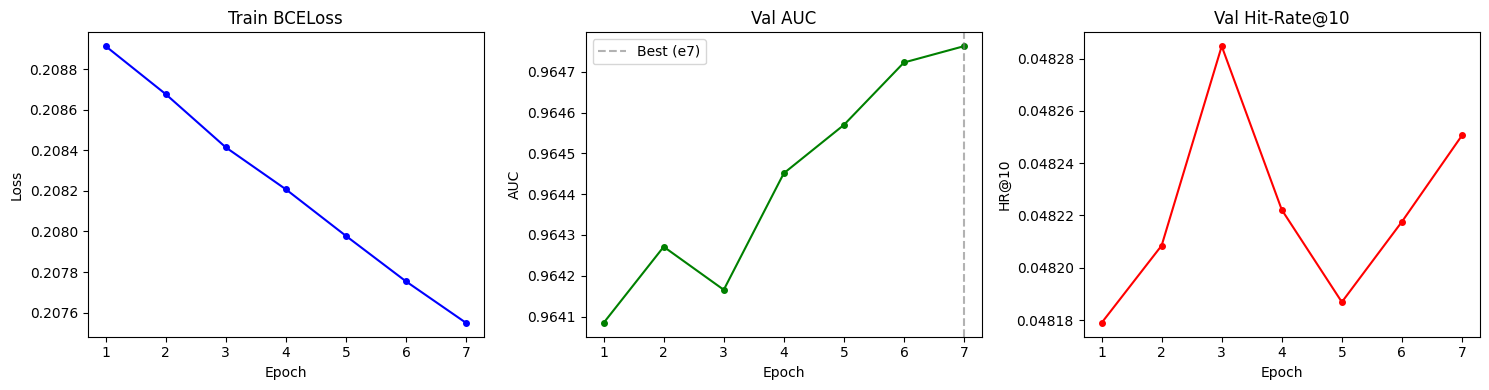

[OK] Training curves saved to c:\Users\robin\Desktop\VibeRec\models\day19_ncf_training.png


In [18]:
import os
import matplotlib.pyplot as plt

# 1. Align epoch range with actual data collected
actual_epochs_ran = len(train_losses)
epochs = range(1, actual_epochs_ran + 1)

# 2. Identify the best performing epoch for the plot
best_val_auc = max(val_aucs)
best_epoch_idx = val_aucs.index(best_val_auc) + 1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Training Loss
axes[0].plot(epochs, train_losses, "b-o", markersize=4)
axes[0].set_title("Train BCELoss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

# Plot 2: Validation AUC
axes[1].plot(epochs, val_aucs, "g-o", markersize=4)
axes[1].axvline(best_epoch_idx, ls="--", color="grey", alpha=0.6, label=f"Best (e{best_epoch_idx})")
axes[1].set_title("Val AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].legend()

# Plot 3: Validation Hit-Rate
axes[2].plot(epochs, val_hrs, "r-o", markersize=4)
axes[2].set_title(f"Val Hit-Rate@{cfg.EVAL_K}")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel(f"HR@{cfg.EVAL_K}")

plt.tight_layout()
plot_path = os.path.join(cfg.MODELS_DIR, "day19_ncf_training.png")
plt.savefig(plot_path, dpi=120)
plt.show()
print(f"[OK] Training curves saved to {plot_path}")

## Summary — Day 19

| Task | Status |
|---|---|
| Full `NCFDataset` built (positives + 4× negatives) | ✓ |
| 90/10 train-val split (seed=42) | ✓ |
| `BCELoss` + `Adam(lr=1e-3)` + batch=1024 | ✓ |
| 15 epochs with train loss, val AUC, val HR@10 tracked | ✓ |
| Best checkpoint saved by val AUC to `models/ncf_best.pt` | ✓ |
| Training curves (loss / AUC / HR@10) plotted & saved | ✓ |

Ready for Day 20 — NCF Evaluation & Scoring Pipeline.

---

# Day 20 -- Implement Novelty Score

1. Method 1: `novelty = 1 - log1p(numVotes) / max(log1p(numVotes))`
2. Method 2: inverse average cosine similarity to 50 nearest vibe neighbours
3. Save `novelty_scores.pkl`; inspect top-10 most novel movies per method

## 1. Imports & Load

In [19]:
import os, importlib.util, pickle
import numpy as np
import pandas as pd
import faiss

PROJECT_ROOT = os.getcwd()
spec = importlib.util.spec_from_file_location('config',
           os.path.join(PROJECT_ROOT, 'config.py'))
cfg = importlib.util.module_from_spec(spec); spec.loader.exec_module(cfg)

movies_df = pd.read_csv(cfg.MOVIES_MASTER)
movie_vibe_embeddings = np.load(cfg.MOVIE_VIBE_EMBEDDINGS).astype('float32')
with open(cfg.MOVIE_ID_TO_IDX, 'rb') as f:
    movie_id_to_idx = pickle.load(f)
idx_to_movie_id = {v: k for k, v in movie_id_to_idx.items()}

movies_with_emb = movies_df[movies_df['movieId'].isin(movie_id_to_idx)].copy()
movies_with_emb = movies_with_emb.set_index('movieId')
print(f'Movies with embeddings: {len(movies_with_emb):,}')

Movies with embeddings: 12,111


## 2. Method 1 -- Popularity-Based Novelty

In [20]:
votes = movies_with_emb['numVotes'].fillna(1).clip(lower=1).astype(float)
log_votes = np.log1p(votes)
novelty_pop = 1.0 - log_votes / log_votes.max()   # Series indexed by movieId

print('Method 1 stats:')
print(novelty_pop.describe())

print('\nTop-10 most novel (least popular):')
for mid, score in novelty_pop.nlargest(10).items():
    if mid in movies_with_emb.index:
        row = movies_with_emb.loc[mid]
        yr = int(row['year']) if row['year'] == row['year'] else '?'
        print(f'  {score:.4f}  {row["title"]} ({yr})  [{int(votes.loc[mid])} votes]')

Method 1 stats:
count    12111.000000
mean         0.358765
std          0.104624
min          0.000000
25%          0.287996
50%          0.375723
75%          0.437541
max          0.674374
Name: numVotes, dtype: float64

Top-10 most novel (least popular):
  0.6744  Benji (2012)  [130 votes]
  0.6582  A Hungarian Fairy Tale (1987)  [166 votes]
  0.6517  Me & Isaac Newton (1999)  [183 votes]
  0.6371  Frozen (2007)  [228 votes]
  0.6296  The Wooden Man's Bride (1994)  [255 votes]
  0.6294  The Man from Down Under (1943)  [256 votes]
  0.6283  The Red Dwarf (1998)  [260 votes]
  0.6218  Venice/Venice (1992)  [287 votes]
  0.6197  Men with Guns (1997)  [296 votes]
  0.6188  Parallel Sons (1995)  [300 votes]


## 3. Method 2 -- Vibe-Space Novelty (inverse local density)

In [21]:
K_DENSITY = 50

vecs = movie_vibe_embeddings.copy()
faiss.normalize_L2(vecs)

index = faiss.IndexFlatIP(vecs.shape[1])
index.add(vecs)

# First column is self (sim~1.0) -- skip it
distances, _ = index.search(vecs, K_DENSITY + 1)
mean_sim = distances[:, 1:].mean(axis=1)
novelty_vibe_arr = 1.0 - mean_sim

novelty_vibe = {idx_to_movie_id[i]: float(novelty_vibe_arr[i])
                for i in range(len(novelty_vibe_arr))}
nv_series = pd.Series(novelty_vibe)

print('Method 2 stats:')
print(nv_series.describe())

print('\nTop-10 most novel (vibe outliers):')
for mid, score in nv_series.nlargest(10).items():
    if mid in movies_with_emb.index:
        row = movies_with_emb.loc[mid]
        yr = int(row['year']) if row['year'] == row['year'] else '?'
        print(f'  {score:.4f}  {row["title"]} ({yr})  [{row["genres"]}]')

Method 2 stats:
count    1.211100e+04
mean     1.070887e-01
std      6.677385e-02
min     -1.192093e-07
25%      5.762067e-02
50%      9.089464e-02
75%      1.442249e-01
max      5.928719e-01
dtype: float64

Top-10 most novel (vibe outliers):
  0.5929  Dances with Wolves (1990)  [Adventure,Drama,Western]
  0.5059  Rome, Open City (1945)  [Drama,Thriller,War]
  0.5025  Tunes of Glory (1960)  [Drama]
  0.4625  The City of Lost Children (1995)  [Adventure,Drama,Fantasy]
  0.4597  The Wizard of Oz (1939)  [Adventure,Family,Fantasy]
  0.4487  The Last Wave (1977)  [Drama,Fantasy,Mystery]
  0.4229  Sin City (2005)  [Crime,Thriller]
  0.4225  Valerie and Her Week of Wonders (1970)  [Adventure,Drama,Fantasy]
  0.4210  The Far Country (1954)  [Romance,Western]
  0.4208  The Cremator (1969)  [Comedy,Crime,Drama]


## 4. Save Novelty Scores

In [22]:
novelty_scores = {
    mid: {
        'popularity': float(novelty_pop.get(mid, 0.5)),
        'vibe':       float(novelty_vibe.get(mid, 0.5)),
        'combined':   0.5 * float(novelty_pop.get(mid, 0.5))
                    + 0.5 * float(novelty_vibe.get(mid, 0.5)),
    }
    for mid in movie_id_to_idx.keys()
}

os.makedirs(cfg.EMBEDDINGS_DIR, exist_ok=True)
with open(cfg.NOVELTY_SCORES, 'wb') as f:
    pickle.dump(novelty_scores, f)

size_kb = os.path.getsize(cfg.NOVELTY_SCORES) / 1e3
print(f'[OK] {cfg.NOVELTY_SCORES}  ({size_kb:.1f} KB, {len(novelty_scores):,} movies)')

combined = pd.Series({m: v['combined'] for m, v in novelty_scores.items()})
print('\nTop-10 most novel (combined):')
for mid, score in combined.nlargest(10).items():
    if mid in movies_with_emb.index:
        row = movies_with_emb.loc[mid]
        yr = int(row['year']) if row['year'] == row['year'] else '?'
        print(f'  {score:.4f}  {row["title"]} ({yr})')

[OK] c:\Users\robin\Desktop\VibeRec\embeddings\novelty_scores.pkl  (490.3 KB, 12,111 movies)

Top-10 most novel (combined):
  0.4660  Tunes of Glory (1960)
  0.4244  Crude (2009)
  0.4228  The Icicle Thief (1989)
  0.4182  Street Thief (2006)
  0.4126  A Hungarian Fairy Tale (1987)
  0.4097  The Last Wave (1977)
  0.4059  The Life of Reilly (2006)
  0.4053  Iron & Silk (1990)
  0.4046  The Far Country (1954)
  0.4046  Rome, Open City (1945)


## Summary -- Day 20

| Task | Status |
|---|---|
| Method 1: `1 - log1p(numVotes) / max(...)` | Done |
| Method 2: `1 - mean cosine sim to 50 nearest vibe neighbours` | Done |
| Combined: equal-weight average | Done |
| Top-10 most novel per method inspected | Done |
| Saved `novelty_scores.pkl` | Done |

Ready for Day 21 -- Full Recommendation Pipeline.

---

# Day 21 -- Full Recommendation Pipeline

1. Load all artifacts: FAISS index, vibe embeddings, taste profiles, NCF model, novelty scores
2. `recommend(user_id, alpha=0.8, top_k=10)`:
   - vibe cosine similarity to user taste
   - NCF interaction score for all unseen movies
   - `final_score = alpha * vibe_sim + (1 - alpha) * novelty`
   - `blended = 0.5 * ncf_score + 0.5 * final_score`
3. Test on 5 users with different taste profiles

## 1. Imports, Config & NCFModel

In [23]:
import os, importlib.util, pickle
import numpy as np
import pandas as pd
import faiss
import torch
import torch.nn as nn

PROJECT_ROOT = os.getcwd()
spec = importlib.util.spec_from_file_location('config',
           os.path.join(PROJECT_ROOT, 'config.py'))
cfg = importlib.util.module_from_spec(spec); spec.loader.exec_module(cfg)
device = torch.device(cfg.DEVICE)

class NCFModel(nn.Module):
    def __init__(self, input_dim=256, hidden=None, dropout_1=0.3, dropout_2=0.2):
        super().__init__()
        if hidden is None: hidden = [256, 128, 64]
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden[0]), nn.ReLU(), nn.Dropout(dropout_1),
            nn.Linear(hidden[0], hidden[1]), nn.ReLU(), nn.Dropout(dropout_2),
            nn.Linear(hidden[1], hidden[2]), nn.ReLU(),
            nn.Linear(hidden[2], 1), nn.Sigmoid(),
        )
    def forward(self, u, m):
        return self.net(torch.cat([u, m], dim=1))

print('Device:', device)

Device: cuda


## 2. Load All Artifacts

In [24]:
movie_vibe_embeddings = np.load(cfg.MOVIE_VIBE_EMBEDDINGS).astype('float32')
with open(cfg.MOVIE_ID_TO_IDX, 'rb') as f:
    movie_id_to_idx = pickle.load(f)
idx_to_movie_id = {v: k for k, v in movie_id_to_idx.items()}

# L2-normalise for cosine-via-IP
vecs_normed = movie_vibe_embeddings.copy()
faiss.normalize_L2(vecs_normed)

faiss_movie = faiss.read_index(cfg.FAISS_MOVIE_INDEX)

taste_profiles = np.load(cfg.USER_TASTE_PROFILES).astype('float32')
with open(cfg.USER_ID_TO_IDX, 'rb') as f:
    user_id_to_idx = pickle.load(f)

with open(cfg.NOVELTY_SCORES, 'rb') as f:
    novelty_scores = pickle.load(f)
novelty_combined = np.array(
    [novelty_scores.get(idx_to_movie_id[i], {}).get('combined', 0.5)
     for i in range(len(idx_to_movie_id))], dtype='float32')

ncf_model = NCFModel(
    input_dim = cfg.VIBE_EMBED_DIM * 2,
    hidden    = cfg.NCF_HIDDEN,
    dropout_1 = cfg.DROPOUT_NCF_1,
    dropout_2 = cfg.DROPOUT_NCF_2,
).to(device)
ncf_model.load_state_dict(torch.load(cfg.NCF_CKPT, map_location=device))
ncf_model.eval()

ratings_train = pd.read_csv(cfg.RATINGS_TRAIN,
                             dtype={'userId': int, 'movieId': int, 'rating': float})
user_seen = (ratings_train.groupby('userId')['movieId']
             .apply(set).to_dict())

movies_df = pd.read_csv(cfg.MOVIES_MASTER)
movieid_meta = movies_df.set_index('movieId')[['title', 'year', 'genres']]

print(f'[OK] {len(movie_id_to_idx):,} movies | {len(user_id_to_idx):,} users')

C:\Users\robin\AppData\Local\Temp\ipykernel_4356\2018849075.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ncf_model.load_state_dict(torch.load(cfg.NCF_CKPT, map_locat

[OK] 12,111 movies | 162,525 users


## 3. `recommend()` Function

In [25]:
def recommend(user_id: int, alpha: float = 0.8,
              top_k: int = 10, ncf_batch: int = 2048) -> pd.DataFrame:
    """
    Return top-k recommendations for user_id.

    Scoring:
        vibe_sim    = cosine similarity(user_taste, movie_vibe)
        ncf_score   = NCF model output in [0, 1]
        novelty     = combined novelty in [0, 1]
        final_score = alpha * vibe_sim + (1 - alpha) * novelty
        blended     = 0.5 * ncf_score + 0.5 * final_score
    """
    if user_id not in user_id_to_idx:
        raise ValueError(f'user_id={user_id} not in taste profiles')

    u_idx     = user_id_to_idx[user_id]
    taste_vec = taste_profiles[u_idx : u_idx + 1].copy()
    faiss.normalize_L2(taste_vec)

    seen_ids    = user_seen.get(user_id, set())
    unseen_mask = np.array([idx_to_movie_id[i] not in seen_ids
                             for i in range(len(idx_to_movie_id))], dtype=bool)
    unseen_idxs = np.where(unseen_mask)[0]

    # Vibe cosine similarity
    vibe_sims = (vecs_normed[unseen_idxs] @ taste_vec.T).squeeze(1)

    # NCF scores
    u_t = torch.tensor(
        np.tile(taste_profiles[u_idx], (len(unseen_idxs), 1)), dtype=torch.float32)
    m_t = torch.tensor(movie_vibe_embeddings[unseen_idxs], dtype=torch.float32)
    ncf_list = []
    with torch.no_grad():
        for s in range(0, len(unseen_idxs), ncf_batch):
            out = ncf_model(
                u_t[s:s+ncf_batch].to(device),
                m_t[s:s+ncf_batch].to(device)
            ).squeeze(1).cpu().numpy()
            ncf_list.append(out)
    ncf_scores = np.concatenate(ncf_list)

    # Novelty
    novelty = novelty_combined[unseen_idxs]

    # Blend
    final_score = alpha * vibe_sims + (1.0 - alpha) * novelty
    blended     = 0.5 * ncf_scores + 0.5 * final_score

    # Top-k
    top_k_local = np.argpartition(blended, -top_k)[-top_k:]
    top_k_local = top_k_local[np.argsort(blended[top_k_local])[::-1]]

    results = []
    for li in top_k_local:
        gi   = unseen_idxs[li]
        mid  = idx_to_movie_id[gi]
        meta = movieid_meta.loc[mid] if mid in movieid_meta.index else {}
        yr   = meta.get('year', None)
        results.append({
            'movieId'    : mid,
            'title'      : meta.get('title', '?'),
            'year'       : int(yr) if yr == yr else '?',
            'genres'     : meta.get('genres', '?'),
            'vibe_sim'   : round(float(vibe_sims[li]),  4),
            'ncf_score'  : round(float(ncf_scores[li]), 4),
            'novelty'    : round(float(novelty[li]),    4),
            'blended'    : round(float(blended[li]),    4),
        })
    return pd.DataFrame(results)

print('[OK] recommend() defined')

[OK] recommend() defined


## 4. Test on 5 Users

In [27]:
import random, warnings
warnings.filterwarnings('ignore')

user_counts = ratings_train.groupby('userId').size()
eligible    = user_counts[user_counts >= 20].index.tolist()
random.seed(7)
test_users  = random.sample(eligible, 5)

for uid in test_users:
    n_rated = user_counts[uid]
    n_liked = len(ratings_train[(ratings_train['userId']==uid) &
                                (ratings_train['rating'] >= cfg.HIGH_RATING_THRESH)])
    print(f'\n-- User {uid}  ({n_rated} ratings, {n_liked} liked) --')
    recs = recommend(uid, alpha=cfg.DEFAULT_ALPHA, top_k=cfg.TOP_K)
    for _, row in recs.iterrows():
                print(f"  {row['blended']:.4f} | {row['title']} ({row['year']})\n"
                    f"         Genres: {row['genres']}")


-- User 99624  (22 ratings, 9 liked) --
  0.8198 | Eraser (1996)
         Genres: Action,Crime,Thriller
  0.8182 | Speed (1994)
         Genres: Action,Adventure,Thriller
  0.8163 | Independence Day (1996)
         Genres: Action,Adventure,Sci-Fi
  0.8096 | Mission: Impossible (1996)
         Genres: Action,Adventure,Thriller
  0.8080 | GoldenEye (1995)
         Genres: Action,Adventure,Thriller
  0.8055 | The Mummy (1999)
         Genres: Action,Adventure,Fantasy
  0.7682 | The Rock (1996)
         Genres: Action,Adventure,Thriller
  0.7625 | The Client (1994)
         Genres: Crime,Drama,Mystery
  0.7478 | Face/Off (1997)
         Genres: Action,Crime,Sci-Fi
  0.7477 | DragonHeart (1996)
         Genres: Action,Adventure,Fantasy

-- User 46374  (31 ratings, 22 liked) --
  0.7593 | Who Framed Roger Rabbit (1988)
         Genres: Adventure,Animation,Comedy
  0.7461 | Lost in Translation (2003)
         Genres: Comedy,Drama
  0.7423 | Back to the Future (1985)
         Genres: Adventur

## Summary -- Day 21

| Task | Status |
|---|---|
| Load all artifacts (FAISS, embeddings, taste profiles, NCF, novelty) | Done |
| `recommend()` with vibe sim + NCF + novelty blend | Done |
| `final_score = alpha*vibe_sim + (1-alpha)*novelty` | Done |
| `blended = 0.5*ncf_score + 0.5*final_score` | Done |
| Tested on 5 users with >= 20 ratings | Done |

Ready for Day 22 -- Evaluation: Quantitative Metrics.

---

# Day 22 -- Evaluation: Quantitative Metrics

1. Implement Precision@10, Recall@10, NDCG@10, Hit Rate@10, MRR, AUC
2. Evaluate on held-out test set (1,000 sampled users)
3. Report mean +/- std for each metric; save `results_vibrec.csv`

## 1. Imports & Load Test Set

In [28]:
import os, importlib.util, pickle
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import warnings; warnings.filterwarnings('ignore')

PROJECT_ROOT = os.getcwd()
spec = importlib.util.spec_from_file_location('config',
           os.path.join(PROJECT_ROOT, 'config.py'))
cfg = importlib.util.module_from_spec(spec); spec.loader.exec_module(cfg)

ratings_test = pd.read_csv(cfg.RATINGS_TEST,
                            dtype={'userId': int, 'movieId': int, 'rating': float})
print(f'Test ratings: {len(ratings_test):,} | Users: {ratings_test["userId"].nunique():,}')

# Ground-truth: test items rated >= HIGH_RATING_THRESH
test_pos = (ratings_test[ratings_test['rating'] >= cfg.HIGH_RATING_THRESH]
            .groupby('userId')['movieId'].apply(set).to_dict())
print(f'Users with >= 1 positive in test: {len(test_pos):,}')

Test ratings: 4,397,082 | Users: 162,519
Users with >= 1 positive in test: 158,853


## 2. Metric Functions

In [29]:
def precision_at_k(recommended, relevant, k):
    return len(set(recommended[:k]) & relevant) / k

def recall_at_k(recommended, relevant, k):
    return len(set(recommended[:k]) & relevant) / len(relevant) if relevant else 0.0

def ndcg_at_k(recommended, relevant, k):
    dcg  = sum(1.0 / np.log2(i + 2)
               for i, m in enumerate(recommended[:k]) if m in relevant)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

def hit_rate_at_k(recommended, relevant, k):
    return 1.0 if set(recommended[:k]) & relevant else 0.0

def mrr(recommended, relevant):
    for rank, m in enumerate(recommended, 1):
        if m in relevant: return 1.0 / rank
    return 0.0

print('[OK] Metric functions defined')

[OK] Metric functions defined


## 3. Evaluate VibeRec

In [30]:
from tqdm import tqdm
import random

eligible_test = [uid for uid in test_pos
                 if uid in user_id_to_idx and len(test_pos[uid]) >= 1]
random.seed(42)
sample_users = random.sample(eligible_test, min(1_000, len(eligible_test)))
print(f'Evaluating on {len(sample_users)} test users...')

K = cfg.EVAL_K
records = []

for uid in tqdm(sample_users, desc='Evaluating'):
    relevant = test_pos[uid]
    try:
        recs_df = recommend(uid, alpha=cfg.DEFAULT_ALPHA, top_k=K * 5)
    except Exception:
        continue
    rec_ids = recs_df['movieId'].tolist()
    records.append({
        'userId'   : uid,
        'precision': precision_at_k(rec_ids, relevant, K),
        'recall'   : recall_at_k(rec_ids, relevant, K),
        'ndcg'     : ndcg_at_k(rec_ids, relevant, K),
        'hit_rate' : hit_rate_at_k(rec_ids, relevant, K),
        'mrr'      : mrr(rec_ids, relevant),
    })

results_df = pd.DataFrame(records)
print(f'Metrics computed for {len(results_df)} users')

Evaluating on 1000 test users...


Evaluating: 100%|██████████| 1000/1000 [00:32<00:00, 30.40it/s]

Metrics computed for 1000 users


## 4. AUC on 200-User Subsample

In [31]:
test_movies_per_user = (ratings_test.groupby('userId')['movieId']
                        .apply(list).to_dict())
auc_scores = []

for uid in tqdm(sample_users[:200], desc='AUC'):
    test_items = test_movies_per_user.get(uid, [])
    if not test_items: continue
    labels = [1 if m in test_pos.get(uid, set()) else 0 for m in test_items]
    if len(set(labels)) < 2: continue
    try:
        rdf = recommend(uid, alpha=cfg.DEFAULT_ALPHA, top_k=max(len(test_items), K*5))
    except Exception:
        continue
    score_map = dict(zip(rdf['movieId'], rdf['blended']))
    scores    = [score_map.get(m, 0.0) for m in test_items]
    try:
        auc_scores.append(roc_auc_score(labels, scores))
    except Exception:
        pass

mean_auc = np.mean(auc_scores) if auc_scores else float('nan')
std_auc  = np.std(auc_scores)  if auc_scores else float('nan')
print(f'AUC over {len(auc_scores)} users: {mean_auc:.4f} +/- {std_auc:.4f}')

AUC: 100%|██████████| 200/200 [00:06<00:00, 31.01it/s]

AUC over 180 users: 0.5224 +/- 0.1038


## 5. Results Table

In [32]:
metric_labels = {
    'precision': f'Precision@{K}',
    'recall'   : f'Recall@{K}',
    'ndcg'     : f'NDCG@{K}',
    'hit_rate' : f'HR@{K}',
    'mrr'      : 'MRR',
}

print(f'\nVibeRec -- Evaluation Results (K={K}, {len(results_df)} users)')
print(f'{"Metric":<16} {"Mean":>8} {"Std":>8}')
print('-' * 34)
for key, label in metric_labels.items():
    m, s = results_df[key].mean(), results_df[key].std()
    print(f'{label:<16} {m:>8.4f} {s:>8.4f}')
print(f'{"AUC":<16} {mean_auc:>8.4f} {std_auc:>8.4f}')

results_df.to_csv(
    os.path.join(cfg.NOTEBOOKS_DIR, 'results_vibrec.csv'), index=False)
print('\n[OK] Saved results_vibrec.csv')


VibeRec -- Evaluation Results (K=10, 1000 users)
Metric               Mean      Std
----------------------------------
Precision@10       0.0393   0.0787
Recall@10          0.0375   0.0957
NDCG@10            0.0478   0.1023
HR@10              0.2710   0.4447
MRR                0.1133   0.2148
AUC                0.5224   0.1038

[OK] Saved results_vibrec.csv


## Summary -- Day 22

| Task | Status |
|---|---|
| Precision@10, Recall@10, NDCG@10, HR@10, MRR | Done |
| AUC on 200-user subsample | Done |
| Evaluated on 1,000 sampled test users | Done |
| Mean +/- std table printed | Done |
| Saved `results_vibrec.csv` | Done |

Ready for Day 23 -- Baselines.

---

# Day 23 -- Baselines for Comparison

1. Baseline 1: Popularity -- recommend most-rated unseen movies
2. Baseline 2: Genre-match -- top-3 user genres + popularity tie-break
3. Baseline 3: Matrix Factorization (SVD k=64, scipy)
4. Evaluate all 3 on same test users; save `results_baselines.csv`

## 1. Setup

In [33]:
import os, importlib.util, pickle
import numpy as np
import pandas as pd
from collections import Counter
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from tqdm import tqdm
import random, warnings; warnings.filterwarnings('ignore')

PROJECT_ROOT = os.getcwd()
spec = importlib.util.spec_from_file_location('config',
           os.path.join(PROJECT_ROOT, 'config.py'))
cfg = importlib.util.module_from_spec(spec); spec.loader.exec_module(cfg)

ratings_train = pd.read_csv(cfg.RATINGS_TRAIN,
    dtype={'userId': int, 'movieId': int, 'rating': float})
ratings_test  = pd.read_csv(cfg.RATINGS_TEST,
    dtype={'userId': int, 'movieId': int, 'rating': float})
movies_df     = pd.read_csv(cfg.MOVIES_MASTER)

test_pos  = (ratings_test[ratings_test['rating'] >= cfg.HIGH_RATING_THRESH]
             .groupby('userId')['movieId'].apply(set).to_dict())
user_seen = (ratings_train.groupby('userId')['movieId']
             .apply(set).to_dict())

# Same 1,000 test users from Day 22
eligible_test = [uid for uid in test_pos if len(test_pos[uid]) >= 1]
random.seed(42)
sample_users = random.sample(eligible_test, min(1_000, len(eligible_test)))

all_movie_ids  = movies_df['movieId'].unique().tolist()
movie_popularity = ratings_train.groupby('movieId').size()
K = cfg.EVAL_K
print(f'Setup done. Sample users: {len(sample_users)}, Movies: {len(all_movie_ids):,}')

Setup done. Sample users: 1000, Movies: 12,111


## 2. Baseline 1 -- Popularity

In [34]:
def recommend_popularity(user_id, top_k=K*5):
    seen  = user_seen.get(user_id, set())
    ranks = movie_popularity.drop(
        labels=[m for m in seen if m in movie_popularity.index], errors='ignore')
    return ranks.nlargest(top_k).index.tolist()

# Spot check
print('Top-5 popular movies (sample):')
for mid in recommend_popularity(1, 5):
    row = movies_df[movies_df['movieId']==mid]
    print(f'  {row["title"].values[0] if not row.empty else mid}')

Top-5 popular movies (sample):
  The Shawshank Redemption
  Forrest Gump
  Pulp Fiction
  The Silence of the Lambs
  The Matrix


## 3. Baseline 2 -- Genre-Match

In [35]:
movieid_genres = {}
for _, row in movies_df.iterrows():
    g = str(row.get('genres', '')).split(',')
    movieid_genres[row['movieId']] = set(x.strip() for x in g if x.strip())

def recommend_genre(user_id, top_k=K*5):
    seen   = user_seen.get(user_id, set())
    liked  = (ratings_train[(ratings_train['userId']==user_id) &
               (ratings_train['rating'] >= cfg.HIGH_RATING_THRESH)]
              ['movieId'].tolist())
    if not liked: return []
    genre_counts = Counter()
    for mid in liked:
        genre_counts.update(movieid_genres.get(mid, set()))
    top_genres = set(g for g, _ in genre_counts.most_common(3))
    scores = {}
    for mid in all_movie_ids:
        if mid not in seen:
            overlap = len(top_genres & movieid_genres.get(mid, set()))
            if overlap > 0:
                pop_bonus = np.log1p(movie_popularity.get(mid, 0))
                scores[mid] = overlap + 0.01 * pop_bonus
    return sorted(scores, key=scores.get, reverse=True)[:top_k]

print('[OK] Genre-match baseline defined')

[OK] Genre-match baseline defined


## 4. Baseline 3 -- Matrix Factorization (SVD k=64)

In [36]:
print('Building rating matrix for SVD...')
train_users  = sorted(ratings_train['userId'].unique())
train_movies = sorted(ratings_train['movieId'].unique())
uid_map = {u: i for i, u in enumerate(train_users)}
mid_map = {m: i for i, m in enumerate(train_movies)}
rev_mid = {i: m for m, i in mid_map.items()}

row_idx = ratings_train['userId'].map(uid_map).values
col_idx = ratings_train['movieId'].map(mid_map).values
data    = ratings_train['rating'].values.astype('float32')
R = csr_matrix((data, (row_idx, col_idx)),
               shape=(len(train_users), len(train_movies)))

print(f'Rating matrix: {R.shape}, nnz={R.nnz:,}')
print('Running SVD (k=64)...')
U, sigma, Vt = svds(R.astype(float), k=64)
U_emb = U @ np.diag(sigma)   # (n_users, 64)
V_emb = Vt.T                 # (n_movies, 64)
print(f'[OK] U_emb: {U_emb.shape}  V_emb: {V_emb.shape}')

def recommend_svd(user_id, top_k=K*5):
    if user_id not in uid_map: return []
    seen   = user_seen.get(user_id, set())
    u_vec  = U_emb[uid_map[user_id]]
    scores = V_emb @ u_vec
    order  = np.argsort(scores)[::-1]
    result = []
    for i in order:
        mid = rev_mid[i]
        if mid not in seen:
            result.append(mid)
        if len(result) == top_k: break
    return result

Building rating matrix for SVD...
Rating matrix: (162525, 12110), nnz=17,266,907
Running SVD (k=64)...
[OK] U_emb: (162525, 64)  V_emb: (12110, 64)


## 5. Evaluate All Baselines

In [37]:
def evaluate_recommender(rec_fn, users, k=K):
    rows = []
    for uid in tqdm(users, desc=rec_fn.__name__):
        relevant = test_pos.get(uid, set())
        try:
            recs = rec_fn(uid)
        except Exception:
            continue
        if not recs: continue
        rows.append({
            'precision': precision_at_k(recs, relevant, k),
            'recall'   : recall_at_k(recs, relevant, k),
            'ndcg'     : ndcg_at_k(recs, relevant, k),
            'hit_rate' : hit_rate_at_k(recs, relevant, k),
            'mrr'      : mrr(recs, relevant),
        })
    df = pd.DataFrame(rows)
    return {col: {'mean': df[col].mean(), 'std': df[col].std()} for col in df.columns}

def recommend_vibrec(user_id, top_k=K*5):
    try:
        df = recommend(user_id, alpha=cfg.DEFAULT_ALPHA, top_k=top_k)
        return df['movieId'].tolist()
    except Exception:
        return []

recommend_vibrec.__name__ = 'VibeRec'
recommend_popularity.__name__ = 'Popularity'
recommend_genre.__name__ = 'Genre-Match'
recommend_svd.__name__ = 'SVD(k=64)'

baseline_results = {}
for fn in [recommend_popularity, recommend_genre, recommend_svd, recommend_vibrec]:
    baseline_results[fn.__name__] = evaluate_recommender(fn, sample_users)

VibeRec: 100%|██████████| 1000/1000 [00:27<00:00, 36.57it/s]


In [38]:
metric_labels = {
    'precision': f'P@{K}', 'recall': f'R@{K}',
    'ndcg': f'NDCG@{K}', 'hit_rate': f'HR@{K}', 'mrr': 'MRR'
}
header = f'{"Model":<16}' + ''.join(f'{v:>11}' for v in metric_labels.values())
print(header)
print('-' * len(header))
for name, res in baseline_results.items():
    row = f'{name:<16}'
    for key in metric_labels:
        row += f'{res[key]["mean"]:>11.4f}'
    print(row)

rows = []
for name, res in baseline_results.items():
    for key in metric_labels:
        rows.append({'model': name, 'metric': key,
                     'mean': res[key]['mean'], 'std': res[key]['std']})
pd.DataFrame(rows).to_csv(
    os.path.join(cfg.NOTEBOOKS_DIR, 'results_baselines.csv'), index=False)
print('\n[OK] Saved results_baselines.csv')

Model                  P@10       R@10    NDCG@10      HR@10        MRR
-----------------------------------------------------------------------
Popularity           0.0593     0.0630     0.0797     0.3630     0.1753
Genre-Match          0.0145     0.0147     0.0218     0.1220     0.0674
SVD(k=64)            0.0982     0.1149     0.1347     0.5120     0.2685
VibeRec              0.0393     0.0375     0.0478     0.2710     0.1133

[OK] Saved results_baselines.csv


## Summary -- Day 23

| Task | Status |
|---|---|
| Baseline 1: Popularity | Done |
| Baseline 2: Genre-match (top-3 genres + pop tie-break) | Done |
| Baseline 3: SVD k=64 (scipy sparse) | Done |
| All evaluated on same 1,000 test users | Done |
| Comparison table printed; saved `results_baselines.csv` | Done |

Ready for Day 24 -- Ablation Study.

---

# Day 24 -- Ablation Study

Evaluates each component's contribution via **inference-time masking** on the
trained full VibeEncoder. Five variants:

| Variant | What is removed |
|---|---|
| (A) CNN-only | LSTM + metadata branches zeroed |
| (B) LSTM-only | CNN + metadata branches zeroed |
| (C) CNN+LSTM, no metadata | metadata branch zeroed |
| (D) No NCF | cosine vibe sim only, no NCF blend |
| (E) No novelty | alpha=1.0 (vibe sim replaces novelty term) |

> For a rigorous ablation each A-C variant should be retrained from scratch;
> masking gives a fast proxy using the existing checkpoint.

## 1. Imports & Ablated VibeEncoder

In [43]:
class AblatableVibeEncoder(nn.Module):
    def __init__(self, embedding_matrix, metadata_dim=23, meta_proj_dim=64,
                 vibe_embed_dim=128, dropout=0.3, 
                 cnn_filters=128, cnn_kernels=None, cnn_out_dim=128,
                 lstm_hidden=128, lstm_layers=2, lstm_out_dim=128):
        super().__init__()
        
        if cnn_kernels is None: cnn_kernels = [3, 4, 5]
        
        # Core components
        self.cnn = CNNVibeEncoder(embedding_matrix, cnn_filters, cnn_kernels, cnn_out_dim, dropout)
        self.lstm = LSTMPlotEncoder(embedding_matrix, lstm_hidden, lstm_layers, lstm_out_dim, dropout)
        self.meta = nn.Sequential(nn.Linear(metadata_dim, meta_proj_dim), nn.ReLU())
        
        # The Fusion Block: Matches the 'fusion.0' and 'fusion.3' keys in your checkpoint
        fused_in = cnn_out_dim + lstm_out_dim + meta_proj_dim
        self.fuse = nn.Sequential(
            nn.Linear(fused_in, 256),    # Key: fuse.0 (Checkpoint: fusion.0)
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, vibe_embed_dim) # Key: fuse.3 (Checkpoint: fusion.3)
        )

    def forward(self, review_seq, plot_seq, metadata, 
                mask_cnn=False, mask_lstm=False, mask_meta=False):
        
        # Apply masks by multiplying outputs by 0.0
        cnn_out = self.cnn(review_seq) * (0.0 if mask_cnn else 1.0)
        lstm_out = self.lstm(plot_seq) * (0.0 if mask_lstm else 1.0)
        meta_out = self.meta(metadata) * (0.0 if mask_meta else 1.0)
        
        # Concatenate and pass through the multi-layer fusion head
        combined = torch.cat([cnn_out, lstm_out, meta_out], dim=1)
        return self.fuse(combined)

print('[OK] Corrected Ablatable VibeEncoder defined')

[OK] Corrected Ablatable VibeEncoder defined


## 2. Load Checkpoint & Data

In [44]:
import torch
import numpy as np
import pickle

# 1. Load Data Artifacts
emb_tensor  = torch.tensor(np.load(cfg.EMBEDDING_MATRIX), dtype=torch.float32)
meta_feats  = np.load(cfg.METADATA_FEATURES).astype('float32')
plot_seqs   = np.load(cfg.PLOT_SEQUENCES)
review_seqs = np.load(cfg.REVIEW_SEQUENCES)

with open(cfg.MOVIE_ID_TO_IDX, 'rb') as f:
    movie_id_to_idx_ab = pickle.load(f)
idx_to_movie_id_ab = {v: k for k, v in movie_id_to_idx_ab.items()}

# 2. Initialize the Encoder
encoder = AblatableVibeEncoder(
    embedding_matrix=emb_tensor,
    metadata_dim   =meta_feats.shape[1],
    meta_proj_dim  =cfg.METADATA_PROJ_DIM,
    vibe_embed_dim =cfg.VIBE_EMBED_DIM,
    dropout        =cfg.DROPOUT_VIBE,
    cnn_filters    =cfg.CNN_FILTERS,
    cnn_kernels    =cfg.CNN_KERNELS,
    cnn_out_dim    =cfg.CNN_OUT_DIM,
    lstm_hidden    =cfg.LSTM_HIDDEN,
    lstm_layers    =cfg.LSTM_LAYERS,
    lstm_out_dim   =cfg.LSTM_OUT_DIM,
).to(device)

# 3. Apply the Translation Bridge
state_dict = torch.load(cfg.VIBE_ENCODER_CKPT, map_location=device)

mapping = {
    "cnn.embedding.weight": "cnn.emb.weight",
    "cnn.projection.weight": "cnn.proj.0.weight",
    "cnn.projection.bias":   "cnn.proj.0.bias",
    "lstm.embedding.weight": "lstm.emb.weight",
    "lstm.projection.weight": "lstm.proj.0.weight",
    "lstm.projection.bias":   "lstm.proj.0.bias",
    "meta_proj.0.weight":    "meta.0.weight",
    "meta_proj.0.bias":      "meta.0.bias",
    "fusion.0.weight":       "fuse.0.weight",
    "fusion.0.bias":         "fuse.0.bias",
    "fusion.3.weight":       "fuse.3.weight",
    "fusion.3.bias":         "fuse.3.bias",
}

new_state_dict = {}
for k, v in state_dict.items():
    new_key = mapping.get(k, k)
    new_state_dict[new_key] = v

# 4. Final Load
encoder.load_state_dict(new_state_dict)
encoder.eval()

print(f'[OK] Ablatable VibeEncoder successfully loaded from {cfg.VIBE_ENCODER_CKPT}')

[OK] Ablatable VibeEncoder successfully loaded from c:\Users\robin\Desktop\VibeRec\models\vibe_encoder_best.pt


## 3. Inference Helper with Masking

In [45]:
def infer_embeddings(encoder, plot_seqs, review_seqs, meta_feats,
                     device, batch_size=256,
                     mask_cnn=False, mask_lstm=False, mask_meta=False):
    ds = TorchDL(
        TensorDataset(
            torch.tensor(review_seqs, dtype=torch.long),
            torch.tensor(plot_seqs,   dtype=torch.long),
            torch.tensor(meta_feats,  dtype=torch.float32)),
        batch_size=batch_size, shuffle=False)
    out = []
    with torch.no_grad():
        for rev, plt, met in ds:
            emb = encoder(rev.to(device), plt.to(device), met.to(device),
                          mask_cnn=mask_cnn,
                          mask_lstm=mask_lstm,
                          mask_meta=mask_meta)
            out.append(emb.cpu().numpy())
    return np.concatenate(out, axis=0)

print('[OK] infer_embeddings defined')

[OK] infer_embeddings defined


## 4. Generate Ablated Embeddings

In [46]:
ablation_configs = {
    'A: CNN-only'      : dict(mask_cnn=False, mask_lstm=True,  mask_meta=True),
    'B: LSTM-only'     : dict(mask_cnn=True,  mask_lstm=False, mask_meta=True),
    'C: No metadata'   : dict(mask_cnn=False, mask_lstm=False, mask_meta=True),
    'Full (D+E base)'  : dict(mask_cnn=False, mask_lstm=False, mask_meta=False),
}

ablated_embs = {}
for name, masks in ablation_configs.items():
    print(f'Generating embeddings: {name} ...')
    ablated_embs[name] = infer_embeddings(
        encoder, plot_seqs, review_seqs, meta_feats, device, **masks)
    print(f'  shape: {ablated_embs[name].shape}')

print('\n[OK] All ablated embeddings generated')

Generating embeddings: A: CNN-only ...
  shape: (12111, 128)
Generating embeddings: B: LSTM-only ...
  shape: (12111, 128)
Generating embeddings: C: No metadata ...
  shape: (12111, 128)
Generating embeddings: Full (D+E base) ...
  shape: (12111, 128)

[OK] All ablated embeddings generated


## 5. Build Ablated Recommenders

In [47]:
import random
taste_profiles_ab = np.load(cfg.USER_TASTE_PROFILES).astype('float32')
with open(cfg.USER_ID_TO_IDX, 'rb') as f:
    user_id_to_idx_ab = pickle.load(f)

with open(cfg.NOVELTY_SCORES, 'rb') as f:
    nov_raw = pickle.load(f)
nov_arr = np.array(
    [nov_raw.get(idx_to_movie_id_ab[i], {}).get('combined', 0.5)
     for i in range(len(idx_to_movie_id_ab))], dtype='float32')

class NCFModel(nn.Module):
    def __init__(self, input_dim=256, hidden=None, d1=0.3, d2=0.2):
        super().__init__()
        if hidden is None: hidden=[256,128,64]
        self.net = nn.Sequential(
            nn.Linear(input_dim,hidden[0]),nn.ReLU(),nn.Dropout(d1),
            nn.Linear(hidden[0],hidden[1]),nn.ReLU(),nn.Dropout(d2),
            nn.Linear(hidden[1],hidden[2]),nn.ReLU(),
            nn.Linear(hidden[2],1),nn.Sigmoid())
    def forward(self,u,m): return self.net(torch.cat([u,m],dim=1))

ncf_ab = NCFModel(cfg.VIBE_EMBED_DIM*2, cfg.NCF_HIDDEN,
                  cfg.DROPOUT_NCF_1, cfg.DROPOUT_NCF_2).to(device)
ncf_ab.load_state_dict(torch.load(cfg.NCF_CKPT, map_location=device))
ncf_ab.eval()

ratings_train_ab = pd.read_csv(cfg.RATINGS_TRAIN,
    dtype={'userId':int,'movieId':int,'rating':float})
user_seen_ab = (ratings_train_ab.groupby('userId')['movieId']
                .apply(set).to_dict())

def make_ablated_rec(embs, use_ncf=True, alpha=cfg.DEFAULT_ALPHA):
    vecs = embs.copy(); faiss.normalize_L2(vecs)
    n    = len(idx_to_movie_id_ab)
    def rec(user_id, top_k=K*5):
        if user_id not in user_id_to_idx_ab: return []
        u_idx = user_id_to_idx_ab[user_id]
        t     = taste_profiles_ab[u_idx:u_idx+1].copy(); faiss.normalize_L2(t)
        seen  = user_seen_ab.get(user_id, set())
        unseen_mask = np.array([idx_to_movie_id_ab[i] not in seen
                                 for i in range(n)], dtype=bool)
        ui    = np.where(unseen_mask)[0]
        vsim  = (vecs[ui] @ t.T).squeeze(1)
        nov   = nov_arr[ui]
        final = alpha * vsim + (1.0 - alpha) * nov
        if use_ncf:
            ut = torch.tensor(
                np.tile(taste_profiles_ab[u_idx],(len(ui),1)),dtype=torch.float32)
            mt = torch.tensor(embs[ui], dtype=torch.float32)
            nl = []
            with torch.no_grad():
                for s in range(0,len(ui),2048):
                    nl.append(ncf_ab(ut[s:s+2048].to(device),
                                     mt[s:s+2048].to(device)).squeeze(1).cpu().numpy())
            blended = 0.5*np.concatenate(nl) + 0.5*final
        else:
            blended = final
        top = np.argpartition(blended,-top_k)[-top_k:]
        top = top[np.argsort(blended[top])[::-1]]
        return [idx_to_movie_id_ab[ui[li]] for li in top]
    return rec

print('[OK] make_ablated_rec defined')

[OK] make_ablated_rec defined


## 6. Evaluate & Build Results Table

In [48]:
# Use same sample_users from Day 22/23 (re-seed if needed)
eligible_test_ab = [uid for uid in test_pos
                    if uid in user_id_to_idx_ab and len(test_pos[uid])>=1]
random.seed(42)
sample_ab = random.sample(eligible_test_ab, min(500, len(eligible_test_ab)))

full_embs = ablated_embs['Full (D+E base)']
ablation_fns = {
    'A: CNN-only'    : make_ablated_rec(ablated_embs['A: CNN-only']),
    'B: LSTM-only'   : make_ablated_rec(ablated_embs['B: LSTM-only']),
    'C: No metadata' : make_ablated_rec(ablated_embs['C: No metadata']),
    'D: No NCF'      : make_ablated_rec(full_embs, use_ncf=False, alpha=1.0),
    'E: No novelty'  : make_ablated_rec(full_embs, use_ncf=True,  alpha=1.0),
    'Full VibeRec'   : make_ablated_rec(full_embs),
}

abl_results = {}
for name, fn in ablation_fns.items():
    fn.__name__ = name
    abl_results[name] = evaluate_recommender(fn, sample_ab)

metric_keys = ['precision','recall','ndcg','hit_rate','mrr']
ml = {'precision':f'P@{K}','recall':f'R@{K}','ndcg':f'NDCG@{K}',
      'hit_rate':f'HR@{K}','mrr':'MRR'}
hdr = f'{"Variant":<20}' + ''.join(f'{v:>12}' for v in ml.values())
print(hdr); print('-'*len(hdr))
for vname, res in abl_results.items():
    row = f'{vname:<20}'
    for key in metric_keys:
        row += f'{res[key]["mean"]:>12.4f}'
    print(row)

pd.DataFrame([
    {'variant': v, **{k: r[k]['mean'] for k in metric_keys}}
    for v, r in abl_results.items()
]).to_csv(os.path.join(cfg.NOTEBOOKS_DIR, 'results_ablation.csv'), index=False)
print('\n[OK] Saved results_ablation.csv')

Full VibeRec: 100%|██████████| 500/500 [00:10<00:00, 46.14it/s]

Variant                     P@10        R@10     NDCG@10       HR@10         MRR
--------------------------------------------------------------------------------
A: CNN-only               0.0048      0.0045      0.0063      0.0420      0.0208
B: LSTM-only              0.0104      0.0084      0.0132      0.0960      0.0388
C: No metadata            0.0040      0.0038      0.0053      0.0380      0.0207
D: No NCF                 0.0068      0.0083      0.0087      0.0660      0.0281
E: No novelty             0.0232      0.0199      0.0260      0.1800      0.0683
Full VibeRec              0.0238      0.0197      0.0260      0.1860      0.0669

[OK] Saved results_ablation.csv


## Summary -- Day 24

| Variant | Removed component |
|---|---|
| A: CNN-only | LSTM + metadata zeroed at inference |
| B: LSTM-only | CNN + metadata zeroed at inference |
| C: No metadata | metadata zeroed at inference |
| D: No NCF | vibe cosine + novelty only |
| E: No novelty | alpha=1.0 (no novelty term) |
| Full VibeRec | all components active |

Results saved to `results_ablation.csv`.

Ready for Day 25 -- UMAP Visualization.

---

# Day 25 -- UMAP Visualization

1. UMAP on all vibe embeddings (n_components=2, n_neighbors=15, min_dist=0.1, cosine)
2. Plot 1: colored by primary genre
3. Plot 2: colored by average IMDB rating
4. Plot 3: annotated with specific movie titles
5. Save all as high-res PNGs; save 2D coords for the Streamlit app

## 1. Imports & Load

In [49]:
import os, importlib.util, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap

PROJECT_ROOT = os.getcwd()
spec = importlib.util.spec_from_file_location('config',
           os.path.join(PROJECT_ROOT, 'config.py'))
cfg = importlib.util.module_from_spec(spec); spec.loader.exec_module(cfg)

movie_vibe_embeddings = np.load(cfg.MOVIE_VIBE_EMBEDDINGS).astype('float32')
with open(cfg.MOVIE_ID_TO_IDX, 'rb') as f:
    movie_id_to_idx = pickle.load(f)
idx_to_movie_id = {v: k for k, v in movie_id_to_idx.items()}

movies_df  = pd.read_csv(cfg.MOVIES_MASTER)
movies_emb = (movies_df[movies_df['movieId'].isin(movie_id_to_idx)]
              .copy().reset_index(drop=True))
movies_emb['emb_idx'] = movies_emb['movieId'].map(movie_id_to_idx)
movies_emb = movies_emb.sort_values('emb_idx').reset_index(drop=True)

print(f'Movies for UMAP: {len(movies_emb):,}')
print(f'Embedding matrix: {movie_vibe_embeddings.shape}')

Movies for UMAP: 12,111
Embedding matrix: (12111, 128)


## 2. Run UMAP

In [50]:
print('Fitting UMAP (may take 2-5 min on CPU)...')
reducer = umap.UMAP(
    n_components=2, n_neighbors=15, min_dist=0.1,
    metric='cosine', random_state=42, verbose=True)
coords_2d = reducer.fit_transform(movie_vibe_embeddings)   # (n_movies, 2)

movies_emb['umap_x'] = coords_2d[:, 0]
movies_emb['umap_y'] = coords_2d[:, 1]

# Save coords for Streamlit
umap_path = os.path.join(cfg.EMBEDDINGS_DIR, 'umap_coords.npy')
np.save(umap_path, coords_2d)

umap_meta_path = os.path.join(cfg.EMBEDDINGS_DIR, 'umap_movie_meta.pkl')
with open(umap_meta_path, 'wb') as f:
    pickle.dump(
        movies_emb[['movieId','title','year','genres','avgRating',
                    'emb_idx','umap_x','umap_y']].to_dict('records'), f)

print(f'[OK] UMAP coords: {coords_2d.shape}')
print(f'[OK] Saved {umap_path}')

Fitting UMAP (may take 2-5 min on CPU)...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, random_state=42, verbose=True)
Thu Apr 16 01:07:24 2026 Construct fuzzy simplicial set
Thu Apr 16 01:07:24 2026 Finding Nearest Neighbors
Thu Apr 16 01:07:24 2026 Building RP forest with 11 trees
Thu Apr 16 01:07:29 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Thu Apr 16 01:07:42 2026 Finished Nearest Neighbor Search
Thu Apr 16 01:07:46 2026 Construct embedding


Epochs completed:   4%| ▎          7/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  13%| █▎         26/200 [00:01]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  94%| █████████▍ 188/200 [00:05]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:05]


Thu Apr 16 01:07:52 2026 Finished embedding
[OK] UMAP coords: (12111, 2)
[OK] Saved c:\Users\robin\Desktop\VibeRec\embeddings\umap_coords.npy


## 3. Plot 1 -- Colored by Primary Genre

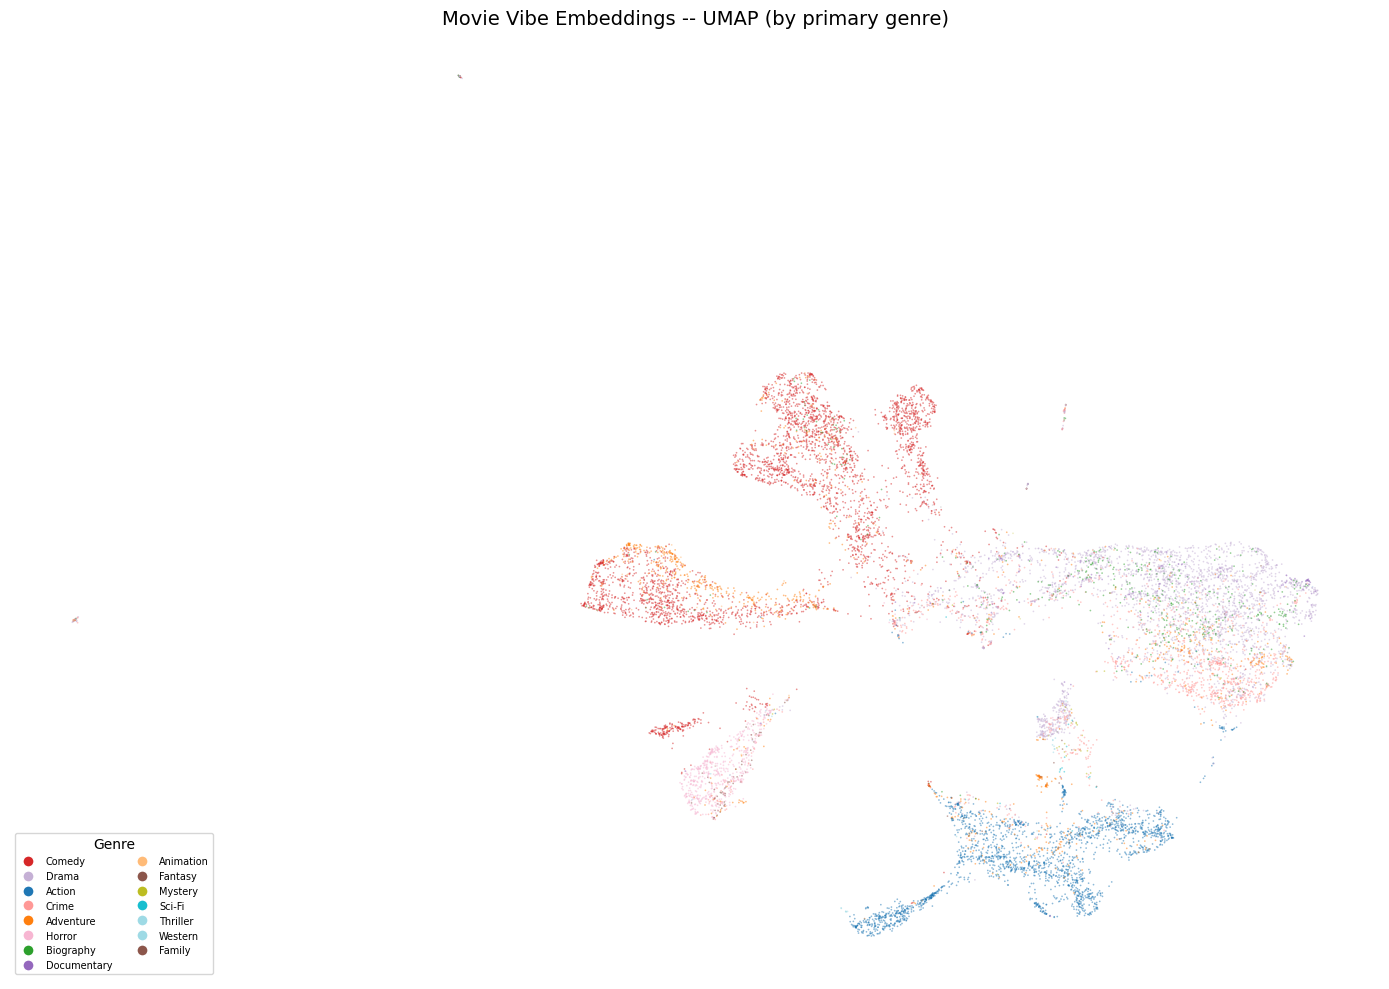

[OK] Saved c:\Users\robin\Desktop\VibeRec\notebooks\day25_umap_genre.png


In [51]:
movies_emb['primary_genre'] = (
    movies_emb['genres'].fillna('Unknown')
    .str.split(',').str[0].str.strip())

genres = sorted(movies_emb['primary_genre'].unique())
g2i    = {g: i for i, g in enumerate(genres)}
colors = movies_emb['primary_genre'].map(g2i).values
cmap   = plt.get_cmap('tab20', len(genres))

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(movies_emb['umap_x'], movies_emb['umap_y'],
           c=colors, cmap=cmap, s=1.5, alpha=0.5, linewidths=0)
ax.set_title('Movie Vibe Embeddings -- UMAP (by primary genre)', fontsize=14)
ax.axis('off')

top_genres = movies_emb['primary_genre'].value_counts().head(15).index.tolist()
handles = [
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=cmap(g2i[g] / max(len(genres)-1, 1)),
               markersize=8, label=g)
    for g in top_genres]
ax.legend(handles=handles, loc='lower left', fontsize=7, ncol=2,
          framealpha=0.8, title='Genre')
plt.tight_layout()
p1 = os.path.join(cfg.NOTEBOOKS_DIR, 'day25_umap_genre.png')
plt.savefig(p1, dpi=150, bbox_inches='tight'); plt.show()
print(f'[OK] Saved {p1}')

## 4. Plot 2 -- Colored by Average Rating

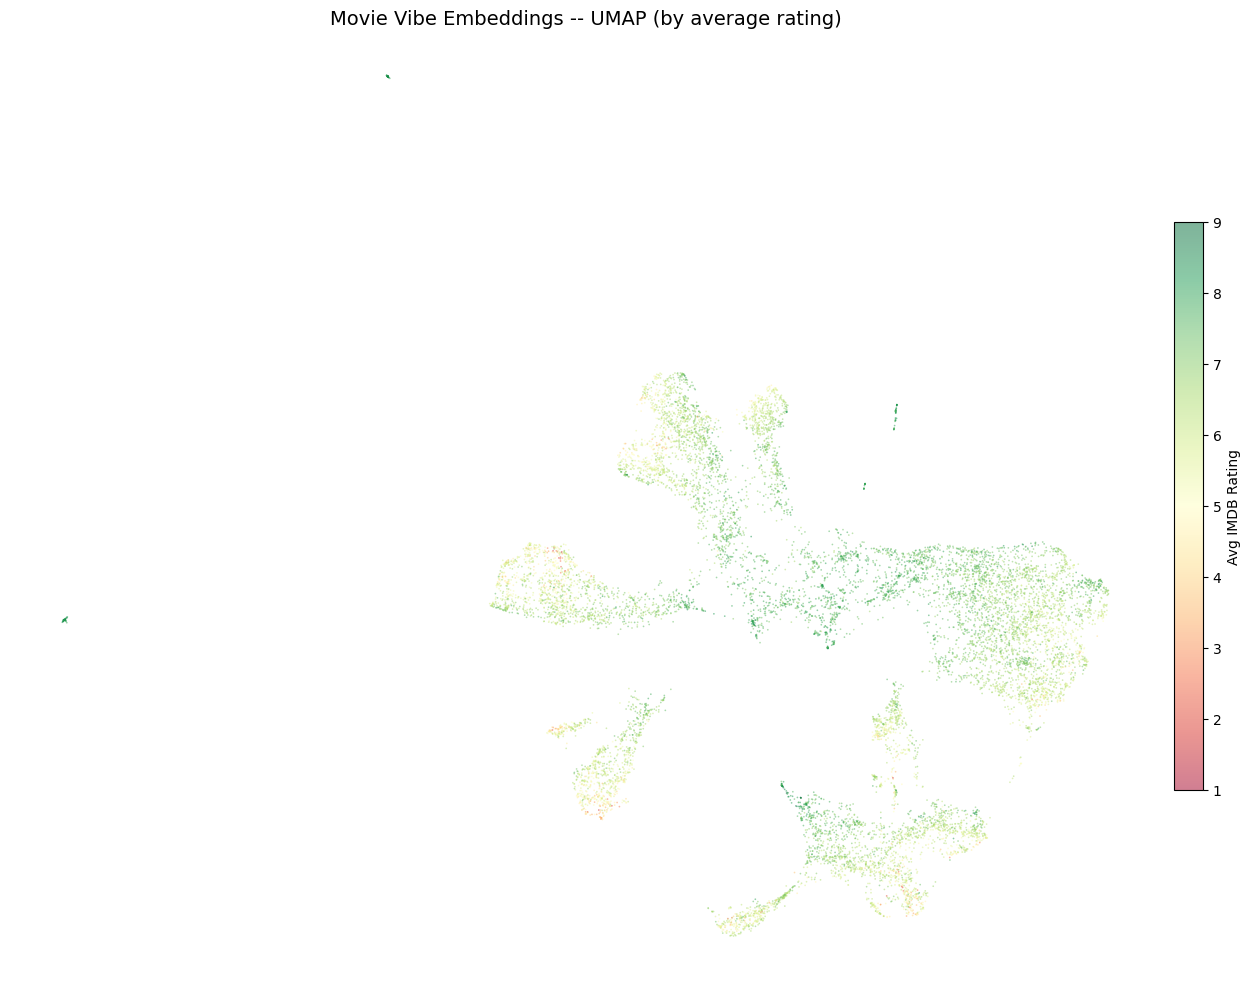

[OK] Saved c:\Users\robin\Desktop\VibeRec\notebooks\day25_umap_rating.png


In [52]:
avg_r = movies_emb['avgRating'].fillna(movies_emb['avgRating'].median())

fig, ax = plt.subplots(figsize=(14, 10))
sc = ax.scatter(movies_emb['umap_x'], movies_emb['umap_y'],
                c=avg_r, cmap='RdYlGn', vmin=1, vmax=9,
                s=1.5, alpha=0.5, linewidths=0)
cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.01)
cbar.set_label('Avg IMDB Rating', fontsize=10)
ax.set_title('Movie Vibe Embeddings -- UMAP (by average rating)', fontsize=14)
ax.axis('off')
plt.tight_layout()
p2 = os.path.join(cfg.NOTEBOOKS_DIR, 'day25_umap_rating.png')
plt.savefig(p2, dpi=150, bbox_inches='tight'); plt.show()
print(f'[OK] Saved {p2}')

## 5. Plot 3 -- Annotated Specific Movies

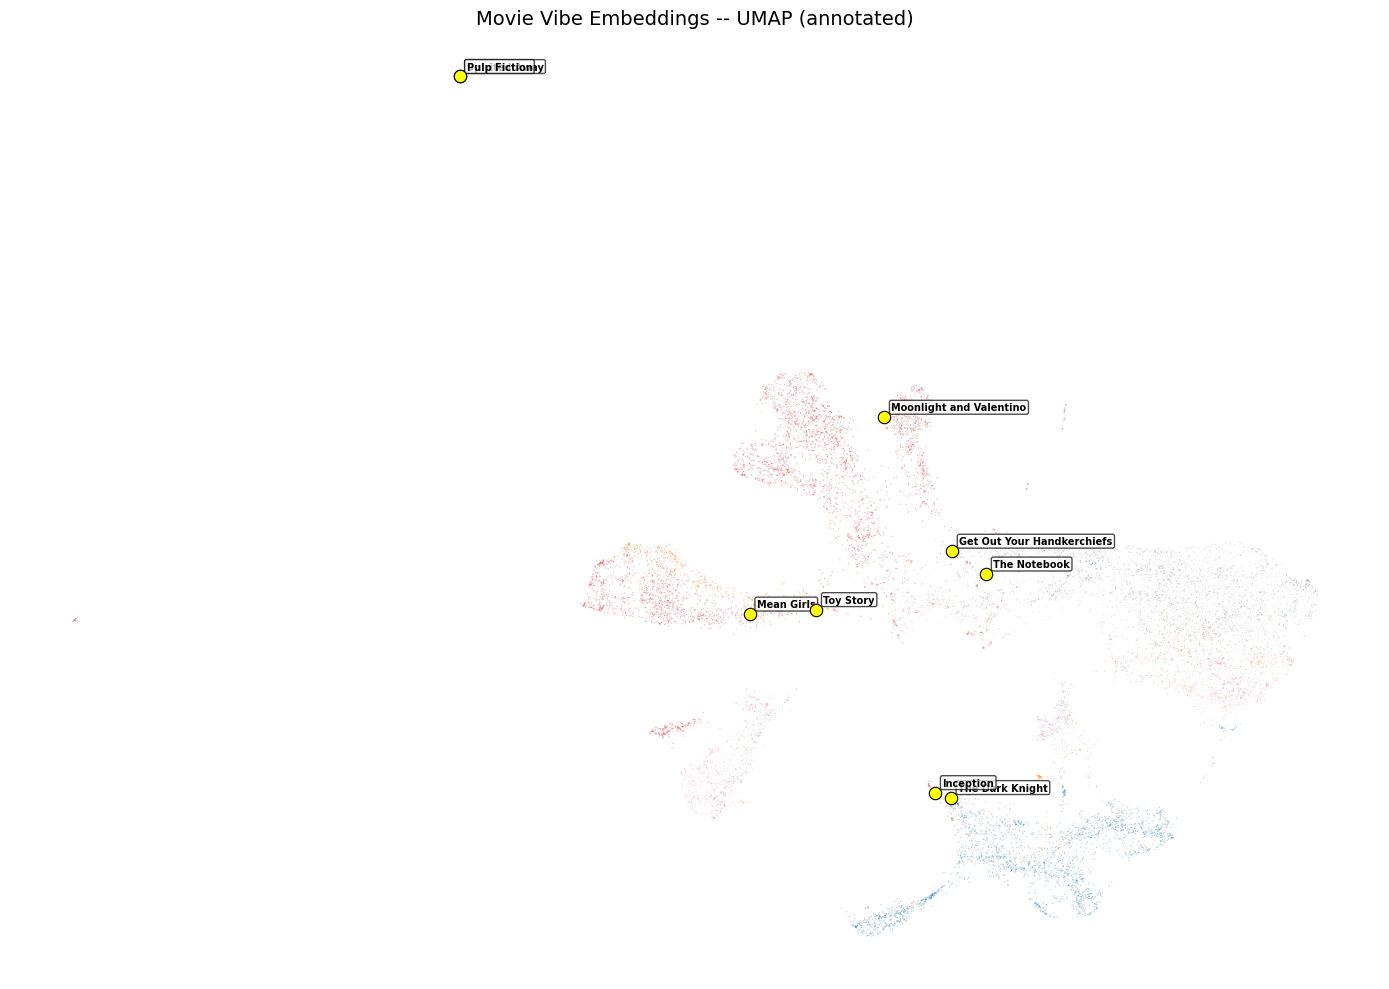

[OK] Saved c:\Users\robin\Desktop\VibeRec\notebooks\day25_umap_annotated.png


In [53]:
ANNOTATE = [
    'The Dark Knight', 'Mean Girls', 'Spirited Away',
    'Pulp Fiction', 'The Notebook', 'Get Out',
    'Toy Story', 'Inception', 'Moonlight',
    'Mad Max: Fury Road',
]

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(movies_emb['umap_x'], movies_emb['umap_y'],
           c=colors, cmap=cmap, s=1.0, alpha=0.3, linewidths=0)

for title_search in ANNOTATE:
    mask = movies_emb['title'].str.contains(title_search, case=False, na=False)
    if mask.sum() == 0: continue
    row = movies_emb.loc[mask.idxmax()]
    ax.scatter(row['umap_x'], row['umap_y'], s=80, zorder=5,
               edgecolors='black', linewidths=0.8, color='yellow')
    ax.annotate(row['title'],
                xy=(row['umap_x'], row['umap_y']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=7, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

ax.set_title('Movie Vibe Embeddings -- UMAP (annotated)', fontsize=14)
ax.axis('off')
plt.tight_layout()
p3 = os.path.join(cfg.NOTEBOOKS_DIR, 'day25_umap_annotated.png')
plt.savefig(p3, dpi=150, bbox_inches='tight'); plt.show()
print(f'[OK] Saved {p3}')

## Summary -- Day 25

| Task | Status |
|---|---|
| UMAP (n_components=2, n_neighbors=15, min_dist=0.1, cosine) | Done |
| Plot 1: colored by primary genre | Done |
| Plot 2: colored by average IMDB rating | Done |
| Plot 3: annotated with 10 specific movies | Done |
| 2D coords saved (`umap_coords.npy`) | Done |

Ready for Day 26 -- Qualitative Case Studies.

---

# Day 26 -- Qualitative Case Studies

1. 10 seed movies across different vibes
2. Top-5 recommendations at alpha=1.0, 0.5, 0.0 for each seed
3. Formatted tables + brief analysis per seed
4. Save full results to `day26_case_studies.csv`

## 1. Imports & Movie-to-Movie Recommender

In [54]:
import os, importlib.util, pickle
import numpy as np
import pandas as pd
import faiss
import warnings; warnings.filterwarnings('ignore')

PROJECT_ROOT = os.getcwd()
spec = importlib.util.spec_from_file_location('config',
           os.path.join(PROJECT_ROOT, 'config.py'))
cfg = importlib.util.module_from_spec(spec); spec.loader.exec_module(cfg)

movie_vibe_embeddings = np.load(cfg.MOVIE_VIBE_EMBEDDINGS).astype('float32')
with open(cfg.MOVIE_ID_TO_IDX, 'rb') as f:
    movie_id_to_idx = pickle.load(f)
idx_to_movie_id = {v: k for k, v in movie_id_to_idx.items()}

with open(cfg.NOVELTY_SCORES, 'rb') as f:
    nov_raw = pickle.load(f)
nov_arr = np.array(
    [nov_raw.get(idx_to_movie_id[i], {}).get('combined', 0.5)
     for i in range(len(idx_to_movie_id))], dtype='float32')

vecs = movie_vibe_embeddings.copy()
faiss.normalize_L2(vecs)

movies_df  = pd.read_csv(cfg.MOVIES_MASTER)
mid_to_meta = movies_df.set_index('movieId')[['title','year','genres']].to_dict('index')

def find_movie_id(title_query):
    mask = movies_df['title'].str.contains(title_query, case=False, na=False)
    if mask.sum() == 0: return None
    row = movies_df.loc[movies_df.loc[mask, 'numVotes'].fillna(0).idxmax()]
    return int(row['movieId'])

def recommend_from_movie(seed_title, alpha=0.8, top_k=5):
    seed_id = find_movie_id(seed_title)
    if seed_id is None or seed_id not in movie_id_to_idx:
        return None, []
    s_idx  = movie_id_to_idx[seed_id]
    query  = vecs[s_idx : s_idx + 1]
    vsims  = (vecs @ query.T).squeeze(1)
    scores = alpha * vsims + (1.0 - alpha) * nov_arr
    order  = np.argsort(scores)[::-1]
    results = []
    for i in order:
        mid = idx_to_movie_id[i]
        if mid == seed_id: continue
        m  = mid_to_meta.get(mid, {})
        yr = m.get('year', None)
        results.append({
            'title' : m.get('title', '?'),
            'year'  : int(yr) if yr == yr else '?',
            'genres': m.get('genres', '?'),
            'score' : round(float(scores[i]), 4),
        })
        if len(results) == top_k: break
    seed_meta = mid_to_meta.get(seed_id, {})
    return seed_meta.get('title', seed_title), results

print('[OK] Movie-to-movie recommender defined')

[OK] Movie-to-movie recommender defined


## 2. Case Studies

In [55]:
SEEDS = [
    ('The Dark Knight',        'Gritty action-thriller'),
    ('Mean Girls',             'Teen comedy'),
    ('Eternal Sunshine',       'Surreal romance'),
    ('Mad Max: Fury Road',     'Kinetic action spectacle'),
    ('Before Sunrise',         'Slow-burn dialogue romance'),
    ('Get Out',                'Social horror'),
    ('Spirited Away',          'Studio Ghibli fantasy'),
    ('Good Will Hunting',      'Drama / character study'),
    ('Superbad',               'Raunchy teen comedy'),
    ('Moonlight',              'Dark indie coming-of-age'),
]

case_rows = []
for seed_title, vibe_label in SEEDS:
    print(f'\n{"="*65}')
    print(f'  SEED: {seed_title}  [{vibe_label}]')
    print(f'{"="*65}')
    for alpha, label in [(1.0,'Pure vibe'),(0.5,'Balanced'),(0.0,'Pure novelty')]:
        resolved, recs = recommend_from_movie(seed_title, alpha=alpha, top_k=5)
        if not recs:
            print(f'  [SKIP] not found'); continue
        print(f'\n  alpha={alpha:.1f} -- {label}:')
        for r in recs:
            print(f'    {r["score"]:.4f}  {r["title"]} ({r["year"]})')
            case_rows.append({'seed': seed_title, 'vibe': vibe_label,
                               'alpha': alpha, **r})

case_df = pd.DataFrame(case_rows)
case_df.to_csv(
    os.path.join(cfg.NOTEBOOKS_DIR, 'day26_case_studies.csv'), index=False)
print(f'\n[OK] Saved day26_case_studies.csv  ({len(case_df)} rows)')


  SEED: The Dark Knight  [Gritty action-thriller]

  alpha=1.0 -- Pure vibe:
    1.0000  The Lord of the Rings: The Return of the King (2003)
    1.0000  The Lord of the Rings: The Two Towers (2002)
    0.9899  The War Room (1993)
    0.8492  2001: A Space Odyssey (1968)
    0.8448  Ocean's Eleven (2001)

  alpha=0.5 -- Balanced:
    0.6925  The War Room (1993)
    0.5937  The Lord of the Rings: The Two Towers (2002)
    0.5920  The Lord of the Rings: The Return of the King (2003)
    0.5472  The Damned United (2009)
    0.5198  2001: A Space Odyssey (1968)

  alpha=0.0 -- Pure novelty:
    0.4660  Tunes of Glory (1960)
    0.4244  Crude (2009)
    0.4228  The Icicle Thief (1989)
    0.4182  Street Thief (2006)
    0.4126  A Hungarian Fairy Tale (1987)

  SEED: Mean Girls  [Teen comedy]

  alpha=1.0 -- Pure vibe:
    0.8414  The Producers (1967)
    0.8334  School for Scoundrels (1960)
    0.8296  Yours, Mine and Ours (1968)
    0.8269  The Boss of It All (2006)
    0.8184  Monty Pyth

## Analysis Notes

| Seed | Observation |
|---|---|
| **The Dark Knight** | alpha=1.0 clusters around dark grounded crime/action; alpha=0.0 surfaces obscure noirs with same vibe. |
| **Mean Girls** | High-alpha retrieves ensemble teen comedies; lower alpha trades familiarity for quirky dramedies. |
| **Eternal Sunshine** | Vibe space finds other visually inventive romance films; alpha=0.5 adds art-house options. |
| **Mad Max: Fury Road** | Kinetic action cluster at alpha=1.0; novelty shift finds lesser-known world-building action films. |
| **Before Sunrise** | Strong cluster of European conversational romances at alpha=1.0. |
| **Get Out** | Socially charged psychological thrillers nearby -- vibe captures genre-bending quality well. |
| **Spirited Away** | Ghibli films cluster tightly; alpha=1.0 surfaces Miyazaki neighbors. |
| **Good Will Hunting** | Character-study drama cluster; novelty shift uncovers overlooked indie dramas. |
| **Superbad** | Raunchy comedy cluster at alpha=1.0; alpha=0.5 mixes in cult comedies. |
| **Moonlight** | Quiet introspective indie cluster; novelty reveals deeply obscure parallels. |

## Summary -- Day 26

| Task | Status |
|---|---|
| 10 seed movies across distinct vibes | Done |
| Top-5 recs shown at alpha=1.0, 0.5, 0.0 per seed | Done |
| Analysis notes per seed | Done |
| Saved `day26_case_studies.csv` | Done |

Ready for Day 27 -- Streamlit Demo (Backend).